# Data & Env Initialization

In [1]:
import os, sys, gc

import zipfile
from os import path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

zip_file = "Lamp-dataset/Lamp303.zip"
data_path = "Lamp-dataset/Lamp303/"

if not path.exists(data_path):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("Lamp-dataset/")

input_indice_path = data_path + "input_indices_{}.npy"
input_data_path = data_path + "input_data_{}.npy"
target_path = data_path + "output_indices_{}.npy"

# Constants

In [2]:
N_CONFIGURATIONS = 4262 # number of configuration of the problem
IMG_SHAPE = (1355, 3384, 3)
H, W = 128, 256 # the window size

CAMERA = np.array([[2304.5479, 0,  1686.2379], # the camera matrix
                          [0, 2305.8757, -0.0151],
                          [0, 0, 1.]], dtype=np.float32)

# Data Viz & Utils

In [3]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)
torch.__version__

'1.3.1+cu92'

In [4]:
class Sky303Dataset(Dataset):
    """Car dataset."""

    def __init__(self):
        super(Sky303Dataset,self).__init__()

    def __len__(self):
        return N_CONFIGURATIONS

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        indice_np = np.load(input_indice_path.format(idx))
        input_np = np.load(input_data_path.format(idx))
        target_np = np.load(target_path.format(idx))
        
        input_bin_mask = np.zeros([H, W, 1], dtype='float16')
        input_bin_mask[indice_np[:,0],indice_np[:,1],:] = 1.
        
        input_2Drepr = np.zeros([H, W, 3], dtype='float16')
        input_2Drepr[indice_np[:,0],indice_np[:,1],:] = input_np
        
        target_2Drepr = np.zeros([H, W, 1], dtype='float16')
        target_2Drepr[target_np[:,0],target_np[:,1],:] = 1.
        
        input_bin_mask = np.rollaxis(input_bin_mask, 2, 0)
        input_bin_mask = torch.from_numpy(input_bin_mask).float()
        
        input_2Drepr = np.rollaxis(input_2Drepr, 2, 0)
        input_2Drepr = torch.from_numpy(input_2Drepr).float()
        
        target_2Drepr = np.rollaxis(target_2Drepr, 2, 0)
        target_2Drepr = torch.from_numpy(target_2Drepr).float()
        
        return [input_bin_mask, input_2Drepr, target_2Drepr]

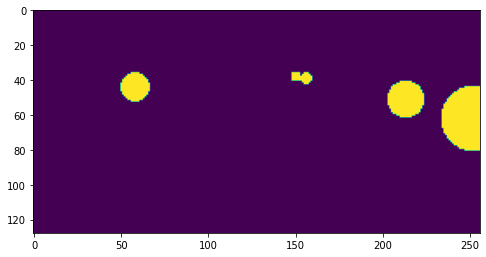

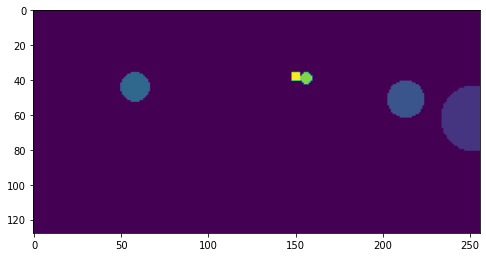

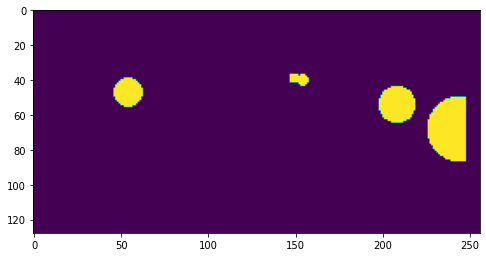

In [5]:
dataset = Sky303Dataset()
input_bin_mask, input_2Drepr, target_2Drepr = dataset[0]

plt.figure(figsize=(8,8))
plt.imshow((input_bin_mask.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(input_2Drepr.permute(1,2,0).numpy()[:,:,-1]/350.)
plt.show()

plt.figure(figsize=(8,8))
plt.imshow((target_2Drepr.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

# Model

In [6]:
import torch.nn as nn
import torch.optim as optim
from smap import *

# Gets the GPU if there is one, otherwise the cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
k_const = 0
class Model(nn.Module):
    def __init__(self, camera_matrix, n=0):
        super(Model,self).__init__()
        self.n = n
        self.camera_matrix = nn.Parameter(torch.from_numpy(camera_matrix), requires_grad=False)
        self.camera_matrix_inv = nn.Parameter(torch.from_numpy(np.linalg.inv(camera_matrix)), requires_grad=False)
        
        self.phi = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.gamma = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.rho = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1), requires_grad=True)
        self.theta = nn.Parameter(torch.from_numpy(np.array([0.,-0.,0.])).float().reshape(1,3,1,1), requires_grad=True)
        self.smap_layer = SMap(IMG_SHAPE[0], IMG_SHAPE[1], camera_matrix, device, n=n)
        
        self.I00 = nn.Parameter(torch.from_numpy(np.array([[1.,.0,.0],[.0,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I01 = nn.Parameter(torch.from_numpy(np.array([[0.,1.,.0],[.0,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I10 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[1.,0.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I11 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[.0,1.,.0],[.0,.0,0.]])).float().reshape(3,3), requires_grad=False)
        self.I22 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[.0,0.,.0],[.0,.0,1.]])).float().reshape(3,3), requires_grad=False)
        
        self.net = nn.Sequential(nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.ReLU(), 
                                 nn.Conv2d(16, 64, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.ReLU(), 
                                 nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.Sigmoid())
        self.dnet = nn.Sequential(nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.ReLU(), 
                                 nn.Conv2d(16, 64, kernel_size=3, stride=1, padding=1, bias=True), 
                                 nn.ReLU(), 
                                 nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias=True))
        
    def forward(self, r_x, r_mask, target_2Dr=None, zoom=0):
        from smap import utils
        mask = self.net(r_mask)
        
        x = (mask>.25).float()*(torch.abs(3e-5*(self.dnet(r_mask[:,-1:,:,:])))*1e3+.5)
        
        plt.figure(figsize=(8,8))
        plt.imshow((((x[0,:1,:,:])/((x[0,:1,:,:]).max()+1e-7)).permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        
        height, width = x.size(-2), x.size(-1)
        panels = list(np.where(np.ones([height, width])))
        panels[0] = panels[0] + .5
        panels[1] = panels[1] + .5
        
        x = utils.to_3d(x.reshape(-1,1,height,width), height, width, panels, (height, width), IMG_SHAPE, self.camera_matrix_inv, device)
        
        x_t = torch.where((x[:,-1:,:,:])>0.,x,x.detach())
        x_t = torch.where((mask>specials.OFF_THRESH),x_t,torch.zeros_like(x_t))
        k_t = torch.where((x_t[:,-1:,:,:])>3e1, (x_t[:,-1:,:,:])-(x_t[:,-1:,:,:]).detach()+3e1,(x_t[:,-1:,:,:])+torch.exp(-1e3*(x_t[:,-1:,:,:]).detach()))
        k_t = 5./k_t
        k_t = k_t.detach()+3e-1*(k_t-k_t.detach())
        
        weights = self.smap_layer(torch.cat([k_t*x_t, mask], dim=1), r_mask, zoom)
        
        
        
        phi = torch.tanh(1e-1*self.phi)*np.pi
        gamma = torch.tanh(1e-1*self.gamma)*np.pi
        rho = torch.tanh(1e-1*self.rho)*np.pi
        theta = 1.*(self.theta)
        
        r = torch.cos(phi)*self.I00-torch.sin(phi)*self.I01+torch.sin(phi)*self.I10+torch.cos(phi)*self.I11+self.I22
        y = torch.cos(gamma)*self.I00-torch.sin(gamma)*self.I01+torch.sin(gamma)*self.I10+torch.cos(gamma)*self.I11+self.I22
        p = torch.cos(rho)*self.I00-torch.sin(rho)*self.I01+torch.sin(rho)*self.I10+torch.cos(rho)*self.I11+self.I22
        
        x_r = torch.einsum('bdef,cd->bcef',x,r.detach())+torch.einsum('bdef,cd->bcef',torch.sign(x),(r-r.detach()))
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        x_r = torch.einsum('bdef,cd->bcef',x_r,y.detach())+torch.einsum('bdef,cd->bcef',torch.sign(x_r),(y-y.detach()))
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        x_r = torch.einsum('bdef,cd->bcef',x_r,p.detach())+torch.einsum('bdef,cd->bcef',torch.sign(x_r),(p-p.detach()))
        x_r = torch.cat([x_r[:,1:,:,:],x_r[:,:1,:,:]],dim=1)
        
        x_t = (x_r.detach()+(mask>.5).float()*self.theta)
        print("x_t")
        print((x_t[0,-1:,:,:]).min())
        print((x_t[0,-1:,:,:]).max())
        
        x_t = torch.where((x[:,-1:,:,:])>0.,x_t,x_t.detach())
        x_t = torch.where((mask>.5),x_t,torch.zeros_like(x_t))
        k_t = torch.where((x_t[:,-1:,:,:])>3e1, (x_t[:,-1:,:,:])-(x_t[:,-1:,:,:]).detach()+3e1,(x_t[:,-1:,:,:])+torch.exp(-1e3*(x_t[:,-1:,:,:]).detach()))
        k_t = 5./k_t
        k_t = k_t.detach()+3e-1*(k_t-k_t.detach())
        
        x_r = (x_r+(mask>.5).float()*self.theta.detach())

        t_weights = self.smap_layer(torch.cat([k_t*x_t+(x_r-x_r.detach()), mask], dim=1), target_2Dr, zoom)
        
        return phi, gamma, rho, theta, weights, t_weights

In [8]:
def create_model(camera_matrix, n):
    return Model(camera_matrix, n)

# Datasets

In [9]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, SequentialSampler, SubsetRandomSampler

In [10]:
train_idx, valid_idx= train_test_split(
    np.random.choice(np.arange(N_CONFIGURATIONS), size=512, replace=False), test_size=0.25, random_state=0, shuffle=True)

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SequentialSampler(valid_idx)

# Training

In [11]:
def l1_error(pred, target, ws):
    shapes = target.size()
    m_batch_size, height, width = shapes[0], shapes[-2], shapes[-1]
    ws = torch.max(ws.reshape(m_batch_size, -1, height*width),dim=1,keepdim=True).values
    
    pred = pred.reshape(m_batch_size, -1, height*width)
    pred_m = (torch.max(pred.reshape(m_batch_size, -1, height*width),dim=1,keepdim=True).values>.5).float()
    target = target.reshape(m_batch_size, 1, -1)
    target_m = target.reshape(m_batch_size, 1, -1)
    
    loss = torch.abs(pred-target)
    loss_m = torch.abs(pred_m-target_m)
    
    denom = loss.reshape(m_batch_size, -1).sum(dim=-1, keepdim=True)
    denom = torch.where(denom>3e0,denom,0.*denom+3e-1)
    
    loss = loss.reshape(m_batch_size, -1).sum(dim=1, keepdim=True)/denom.detach()
    loss_m = loss_m.reshape(m_batch_size, -1).sum(dim=1, keepdim=True)
    
    loss = torch.mean(loss_m).detach()+1e2*(loss-loss.detach()).sum()
    
    return loss

def train_loop_fn(loader, zoom, epoch, history=None):
    from smap import specials
    
    model.train()
    for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
        m_batchsize, height, width = r_mask_batch.size(0), r_mask_batch.size(-2), r_mask_batch.size(-1)
        if m_batchsize != batch_size:
            break
        else:
            r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

        optimizer.zero_grad()
        
        r, p, y, theta, weights, t_weights = model(input_2Dr_batch, r_mask_batch, target_2Dr_batch, zoom)
        
        target_2Dr = target_2Dr_batch.reshape(m_batchsize,1,H//(2**zoom),(2**zoom),W//(2**zoom),(2**zoom)).permute(0,3,5,1,2,4).reshape(m_batchsize,(2**(zoom+zoom)),1,H//(2**zoom),W//(2**zoom))
        target_2Dr, _ = torch.max(target_2Dr,dim=1,keepdim=False)
        
        r_mask = r_mask_batch.reshape(m_batchsize,1,H//(2**zoom),(2**zoom),W//(2**zoom),(2**zoom)).permute(0,3,5,1,2,4).reshape(m_batchsize,(2**(zoom+zoom)),1,H//(2**zoom),W//(2**zoom))
        r_mask, _ = torch.max(r_mask,dim=1,keepdim=False)
        
        ws = (input_2Dr_batch[:,-1:,:,:]).reshape(m_batchsize,1,H//(2**zoom),(2**zoom),W//(2**zoom),(2**zoom)).permute(0,3,5,1,2,4).reshape(m_batchsize,(2**(zoom+zoom)),1,H//(2**zoom),W//(2**zoom))
        ws = torch.max(ws,dim=1,keepdim=False).values+1.

        loss = .5*(l1_error(weights, r_mask, ws)+l1_error(t_weights, target_2Dr, ws))
        
        loss.backward()
        optimizer.step()
        
        print("input_2Dr_batch")
        print(input_2Dr_batch.size())
        print((input_2Dr_batch[0,-1:,:,:]).min())
        print((input_2Dr_batch[0,-1:,:,:]).max())
        plt.figure(figsize=(8,8))
        plt.imshow((input_2Dr_batch[0,-1:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()

        print(t_weights.min())
        print(t_weights.max())
        out_batch = utils.recover_size(t_weights, n, zoom)
        print("out_batch")
        print(out_batch.min())
        print(out_batch.max())
        plt.figure(figsize=(8,8))
        plt.imshow(((out_batch>specials.OFF_THRESH)[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
        plt.show()

        plt.figure(figsize=(8,8))
        plt.imshow((target_2Dr_batch[0,:,:,:].permute(1,2,0).cpu().numpy()[:,:,-1]).squeeze())
        plt.show()
        
        print('theta_x: %.4f' % ((theta[0,0,0,0]).detach().cpu().numpy()))
        print('theta_y: %.4f' % ((theta[0,1,0,0]).detach().cpu().numpy()))
        print('theta_z: %.4f' % ((theta[0,2,0,0]).detach().cpu().numpy()))
        print('phi: %.4f' % ((r[0,0]).detach().cpu().numpy()))
        print('gamma: %.4f' % ((p[0,0]).detach().cpu().numpy()))
        print('rho: %.4f' % ((y[0,0]).detach().cpu().numpy()))

        loss_np = loss.detach().cpu().numpy()

        history.loc[(zoom, epoch, batch_idx), 'theta_x'] = (theta[0,0,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'theta_y'] = (theta[0,1,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'theta_z'] = (theta[0,2,0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'phi'] = (r[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'gamma'] = (p[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'rho'] = (y[0,0]).detach().cpu().numpy()
        history.loc[(zoom, epoch, batch_idx), 'loss'] = loss_np
        
    print('Train Epoch: ({}, {}) \tLR: {:.6f}\tLoss: {:.6f}'.format(
            zoom, epoch,
            optimizer.state_dict()['param_groups'][0]['lr'],
            history['loss'].iloc[(-len(train_loader)+1):].mean()))
    
def evaluate_model(loader, key, history=None):
    model.eval()
    loss_np = 0.
    count = 0.

    with torch.no_grad():
        for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
            m_batchsize = r_mask_batch.size(0)
            if m_batchsize != batch_size:
                break
            r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

            optimizer.zero_grad()

            r, p, y, theta, weights, t_weights = model(input_2Dr_batch, r_mask_batch, r_mask_batch)
            
            ws = (input_2Dr_batch[:,-1:,:,:]).reshape(m_batchsize,1,H//(2**zoom),(2**zoom),W//(2**zoom),(2**zoom)).permute(0,3,5,1,2,4).reshape(m_batchsize,(2**(zoom+zoom)),1,H//(2**zoom),W//(2**zoom))
            ws = 0.*torch.max(ws,dim=1,keepdim=False).values+1.
            
            l1 = l1_error(t_weights, target_2Dr_batch, ws)
            loss_np += l1.detach().cpu().numpy()
            count = count+1.
    loss_np /= count
    history.loc[key, 'theta_x'] = (theta[0,0,0,0]).detach().cpu().numpy()
    history.loc[key, 'theta_y'] = (theta[0,1,0,0]).detach().cpu().numpy()
    history.loc[key, 'theta_z'] = (theta[0,2,0,0]).detach().cpu().numpy()
    history.loc[key, 'phi'] = (r[0,0]).detach().cpu().numpy()
    history.loc[key, 'gamma'] = (p[0,0]).detach().cpu().numpy()
    history.loc[key, 'rho'] = (y[0,0]).detach().cpu().numpy()
    history.loc[key, 'dev_loss'] = loss_np
    print("n_epochs: {} - lr: {}".format(*key))
    print('theta_x: {:.4f}'.format((theta[0,0,0,0]).detach().cpu().numpy()))
    print('theta_y: {:.4f}'.format((theta[0,1,0,0]).detach().cpu().numpy()))
    print('theta_z: {:.4f}'.format((theta[0,2,0,0]).detach().cpu().numpy()))
    print('phi: {:.4f}'.format((r[0,0]).detach().cpu().numpy()))
    print('gamma: {:.4f}'.format((p[0,0]).detach().cpu().numpy()))
    print('rho: {:.4f}'.format((y[0,0]).detach().cpu().numpy()))
    print('Dev loss: {:.4f}'.format(loss_np))

Wall time: 0 ns


  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

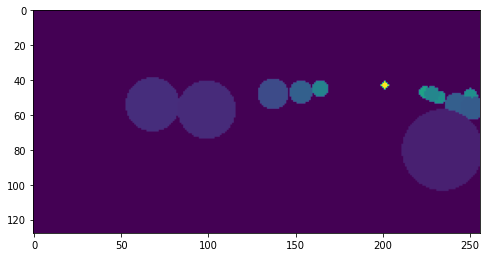

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(103.5000, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(103.5000, device='cuda:0')


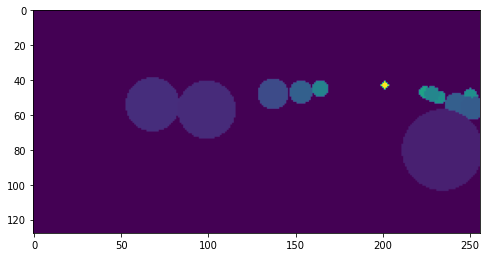

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


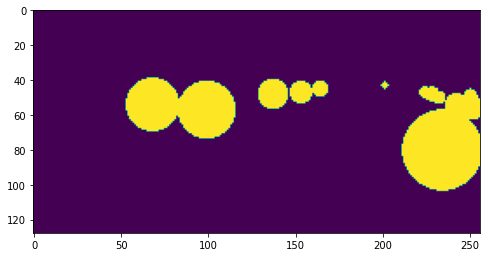

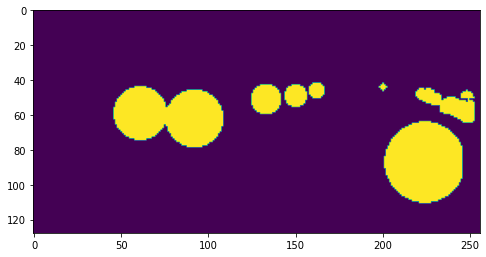

  4%|███▍                                                                               | 1/24 [00:01<00:32,  1.42s/it]

theta_x: 0.0000
theta_y: -0.0000
theta_z: 0.0000
phi: 0.0000
gamma: 0.0000
rho: 0.0000


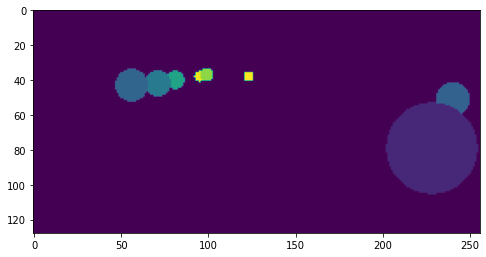

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(69.3565, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(69.3750, device='cuda:0')


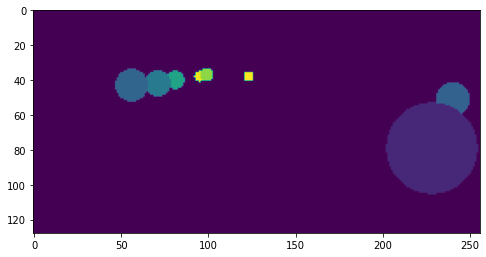

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


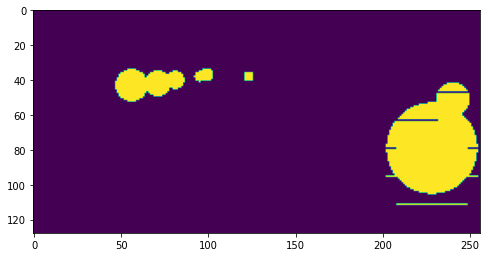

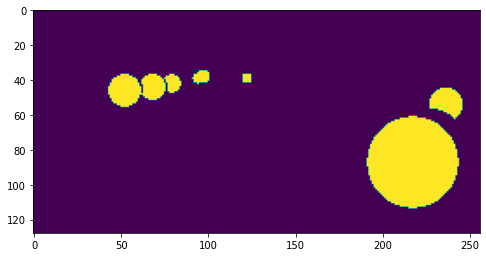

  8%|██████▉                                                                            | 2/24 [00:02<00:29,  1.36s/it]

theta_x: -0.0058
theta_y: 0.0047
theta_z: 0.0003
phi: 0.0014
gamma: -0.0015
rho: -0.0013


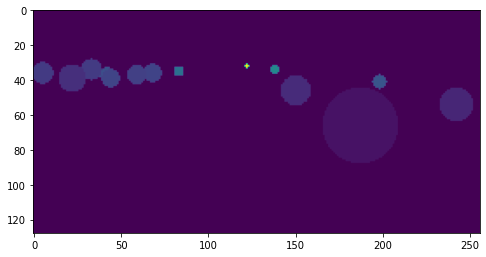

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(198.4026, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(198.5000, device='cuda:0')


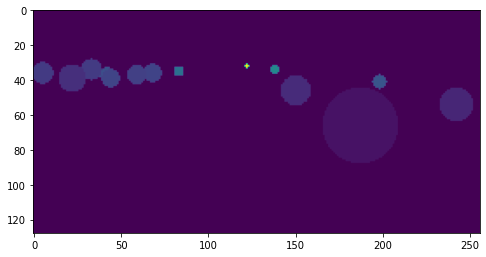

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


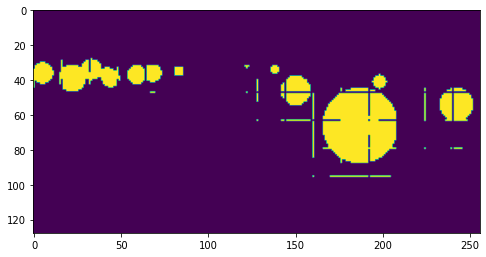

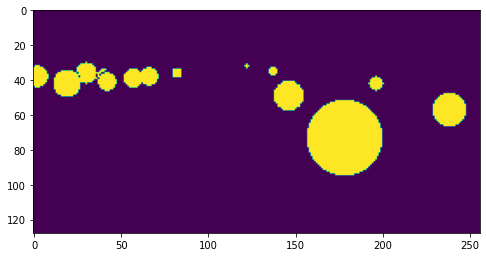

 12%|██████████▍                                                                        | 3/24 [00:03<00:27,  1.30s/it]

theta_x: -0.0116
theta_y: 0.0068
theta_z: 0.0000
phi: 0.0024
gamma: -0.0028
rho: -0.0027


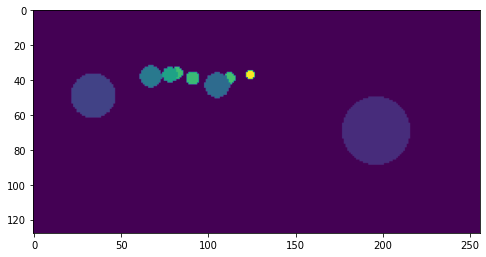

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(83.2563, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(83.3125, device='cuda:0')


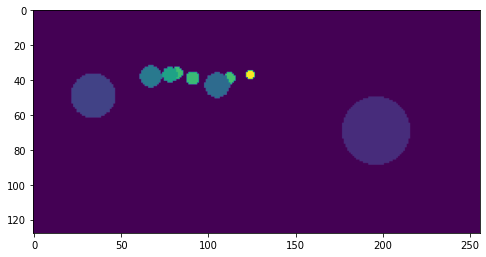

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


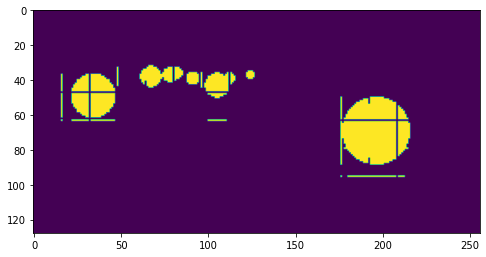

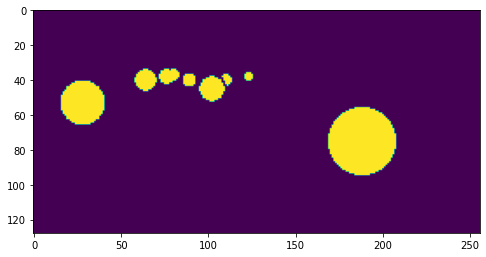

 17%|█████████████▊                                                                     | 4/24 [00:05<00:25,  1.28s/it]

theta_x: -0.0151
theta_y: 0.0088
theta_z: 0.0002
phi: 0.0023
gamma: -0.0038
rho: -0.0034


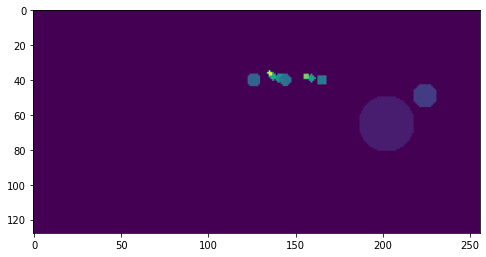

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(165.7666, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(165.8750, device='cuda:0')


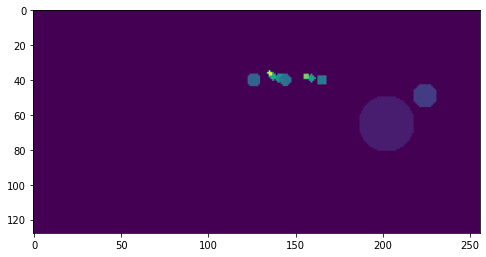

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


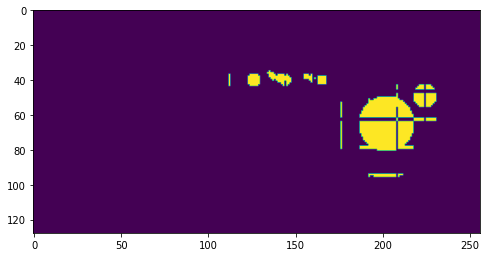

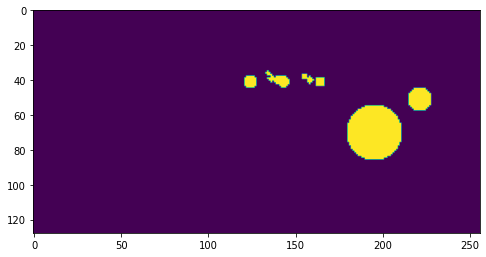

 21%|█████████████████▎                                                                 | 5/24 [00:06<00:23,  1.25s/it]

theta_x: -0.0211
theta_y: 0.0119
theta_z: 0.0007
phi: 0.0033
gamma: -0.0052
rho: -0.0046


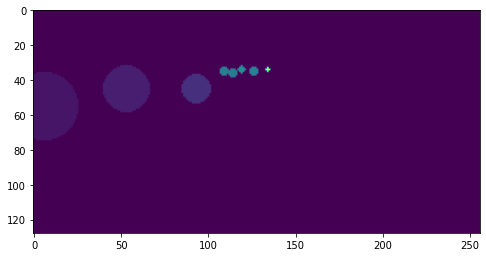

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(188.1264, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(188.2500, device='cuda:0')


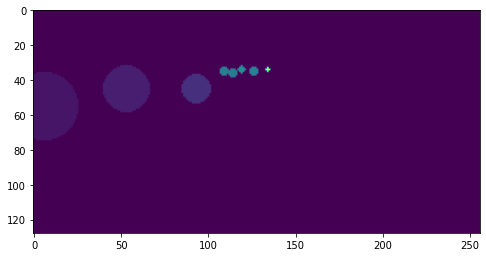

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


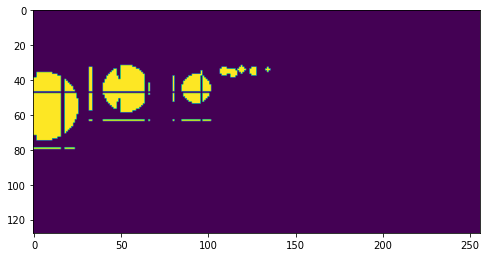

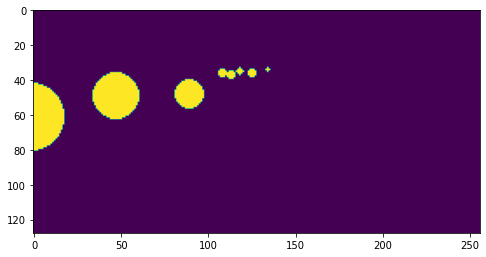

 25%|████████████████████▊                                                              | 6/24 [00:07<00:21,  1.21s/it]

theta_x: -0.0279
theta_y: 0.0126
theta_z: 0.0000
phi: 0.0038
gamma: -0.0055
rho: -0.0055


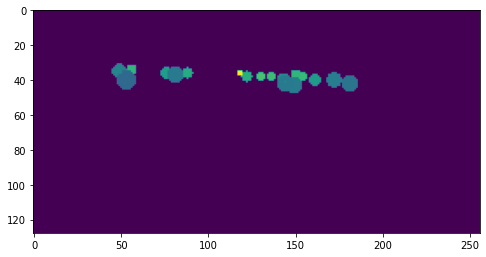

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(109.4873, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(109.6250, device='cuda:0')


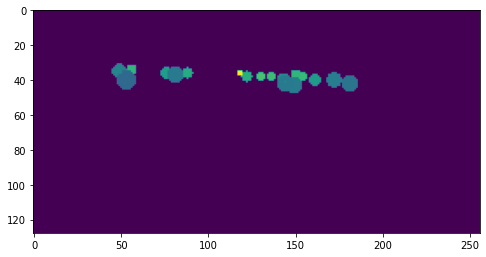

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


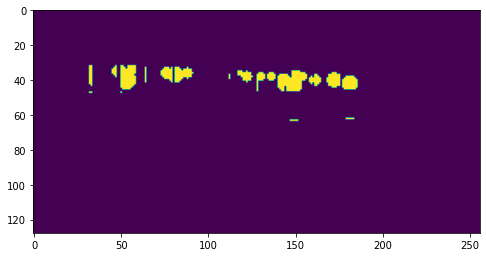

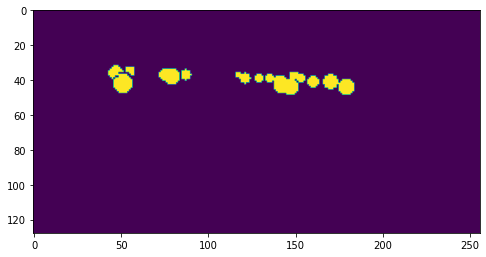

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:20,  1.19s/it]

theta_x: -0.0321
theta_y: 0.0109
theta_z: 0.0001
phi: 0.0039
gamma: -0.0058
rho: -0.0059


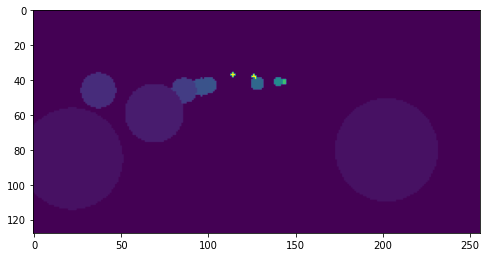

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(162.0623, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(162.2500, device='cuda:0')


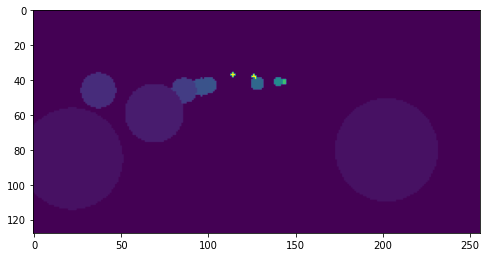

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


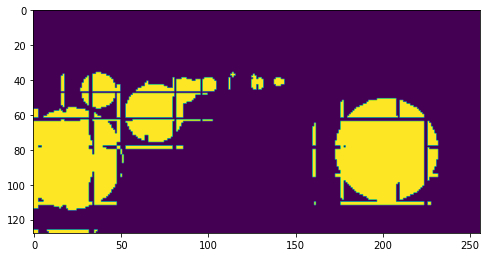

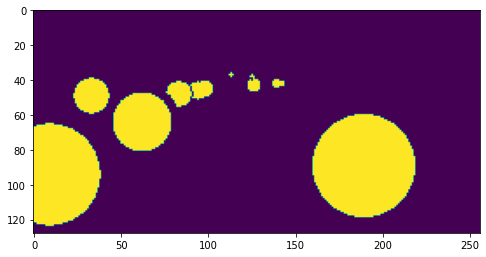

 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:18,  1.18s/it]

theta_x: -0.0331
theta_y: 0.0104
theta_z: 0.0002
phi: 0.0035
gamma: -0.0063
rho: -0.0061


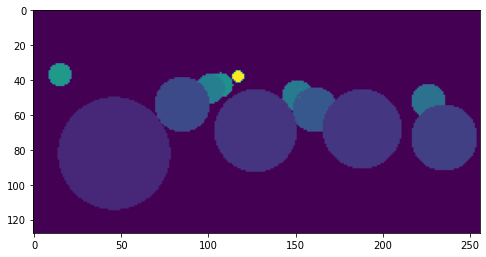

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(58.2627, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(58.3438, device='cuda:0')


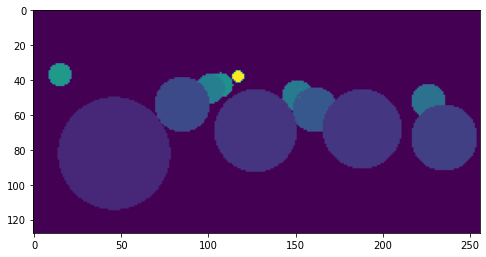

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


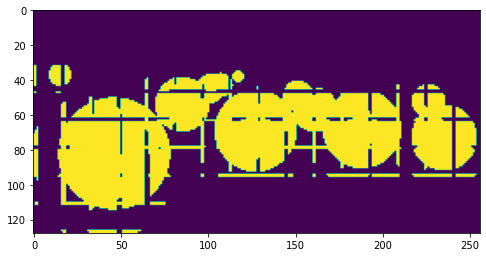

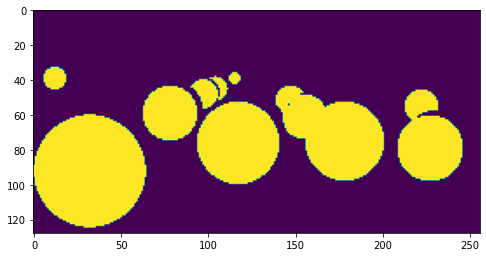

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:17,  1.18s/it]

theta_x: -0.0343
theta_y: 0.0086
theta_z: 0.0013
phi: 0.0033
gamma: -0.0065
rho: -0.0062


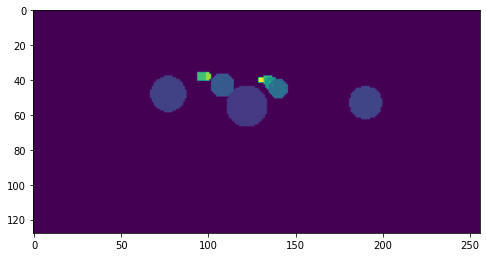

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(105.2554, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(105.3750, device='cuda:0')


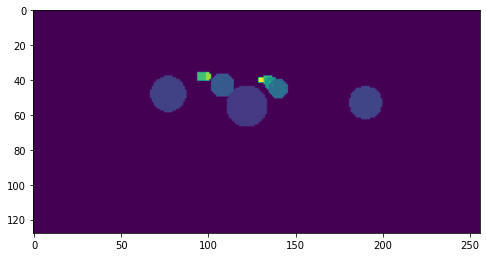

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


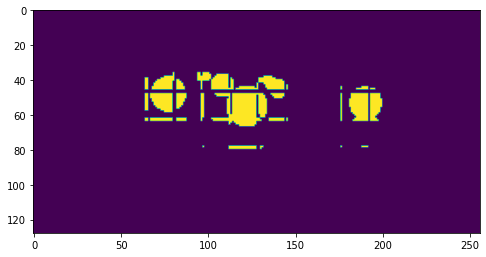

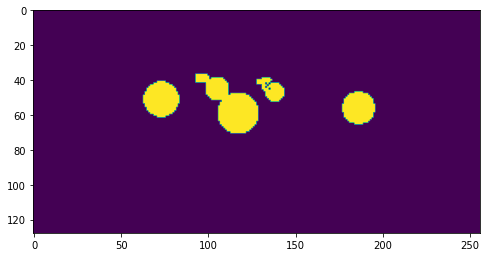

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:16,  1.17s/it]

theta_x: -0.0341
theta_y: 0.0083
theta_z: 0.0019
phi: 0.0026
gamma: -0.0069
rho: -0.0060


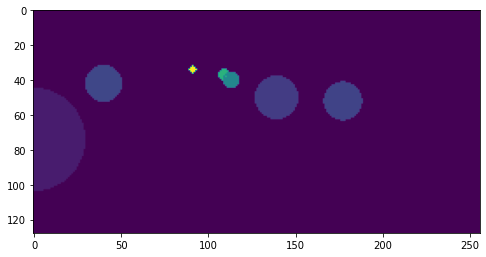

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(93.9080, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(94.1250, device='cuda:0')


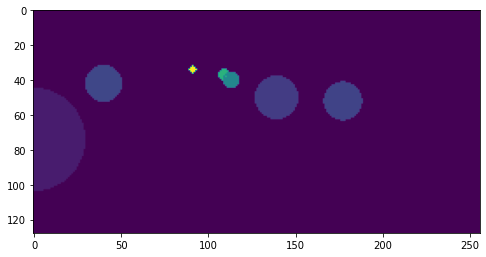

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


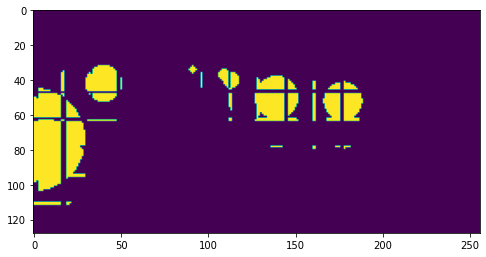

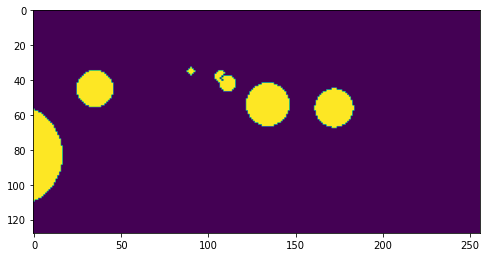

 46%|█████████████████████████████████████▌                                            | 11/24 [00:13<00:15,  1.18s/it]

theta_x: -0.0361
theta_y: 0.0061
theta_z: 0.0022
phi: 0.0031
gamma: -0.0067
rho: -0.0063


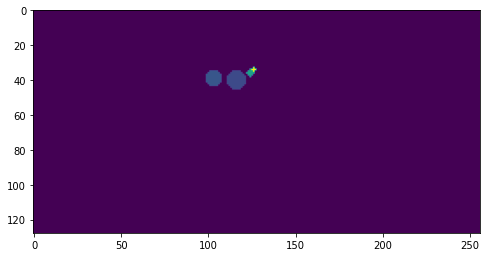

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(171.3129, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(171.5000, device='cuda:0')


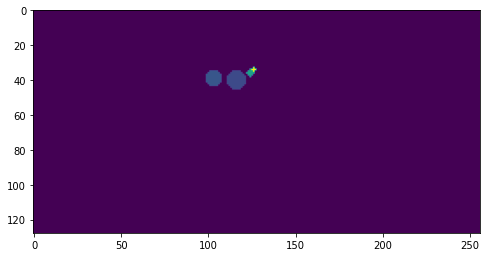

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


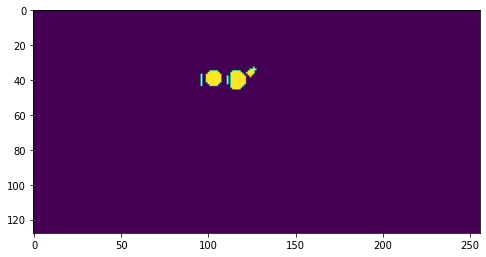

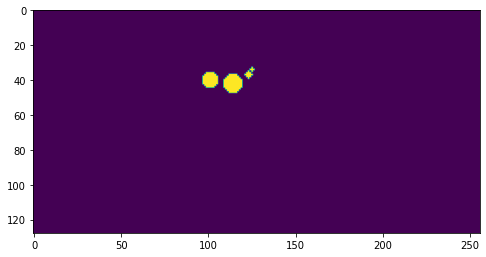

 50%|█████████████████████████████████████████                                         | 12/24 [00:14<00:14,  1.19s/it]

theta_x: -0.0370
theta_y: 0.0048
theta_z: 0.0025
phi: 0.0027
gamma: -0.0067
rho: -0.0064


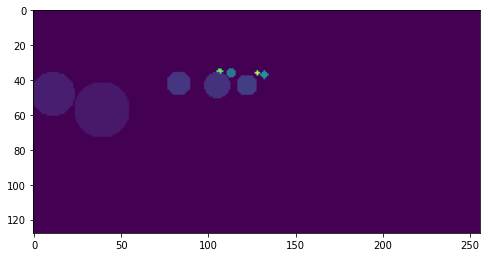

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(193.2888, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(193.5000, device='cuda:0')


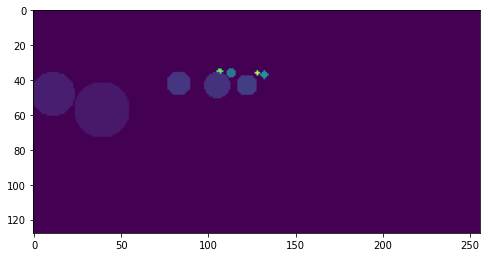

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


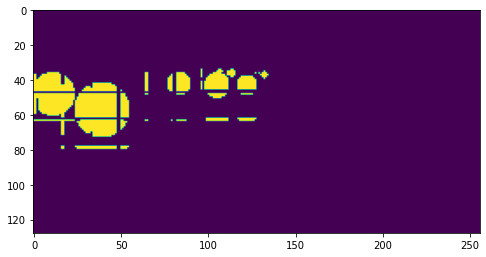

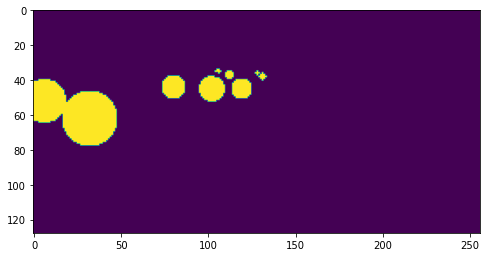

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:15<00:12,  1.18s/it]

theta_x: -0.0394
theta_y: 0.0027
theta_z: 0.0032
phi: 0.0030
gamma: -0.0068
rho: -0.0067


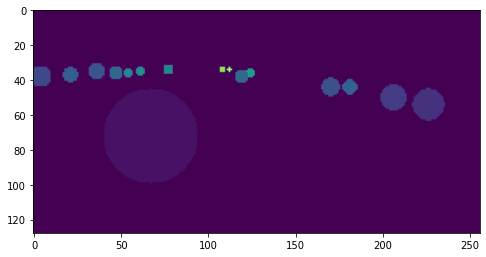

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(159.2313, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(159.5000, device='cuda:0')


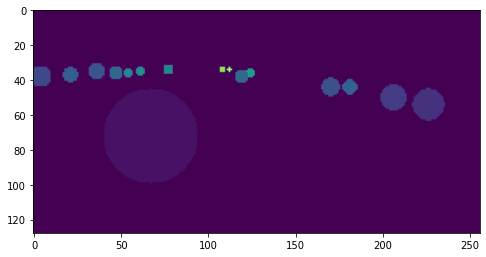

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


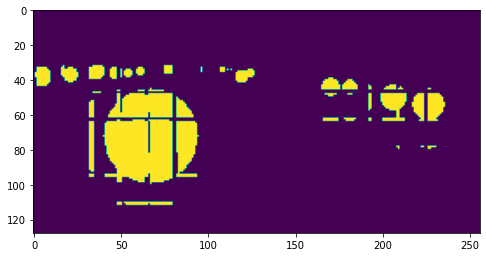

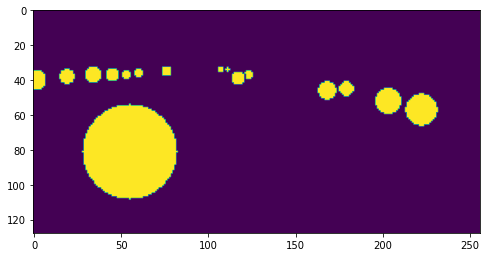

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:16<00:11,  1.20s/it]

theta_x: -0.0402
theta_y: 0.0014
theta_z: 0.0038
phi: 0.0032
gamma: -0.0070
rho: -0.0069


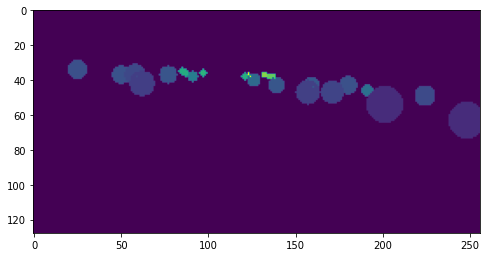

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(156.4152, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(156.6250, device='cuda:0')


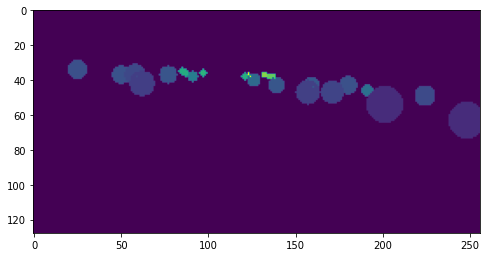

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


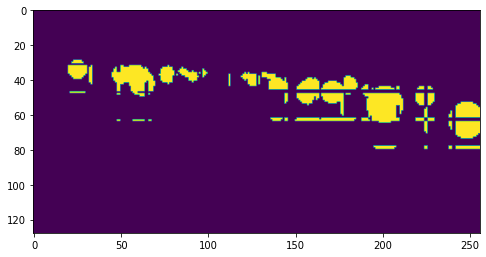

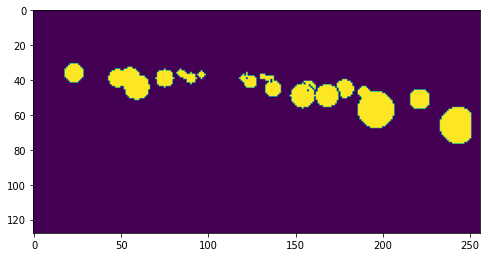

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:17<00:10,  1.21s/it]

theta_x: -0.0407
theta_y: -0.0011
theta_z: 0.0045
phi: 0.0034
gamma: -0.0069
rho: -0.0069


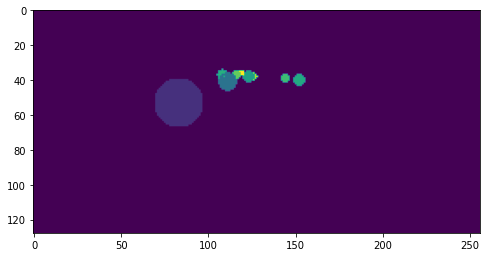

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(107.0311, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(107.1875, device='cuda:0')


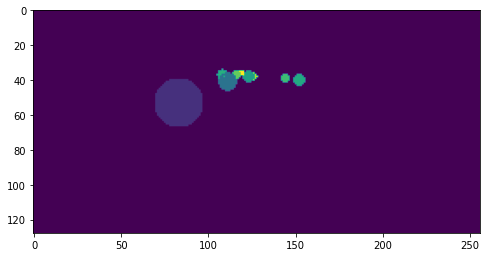

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


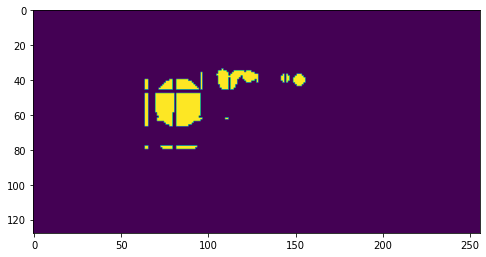

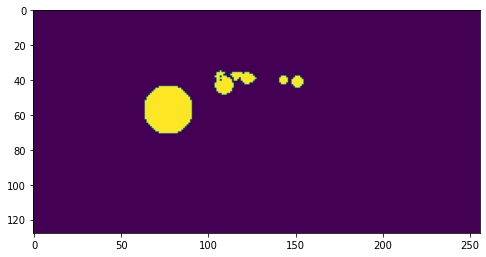

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:19<00:09,  1.21s/it]

theta_x: -0.0401
theta_y: -0.0006
theta_z: 0.0049
phi: 0.0022
gamma: -0.0073
rho: -0.0066


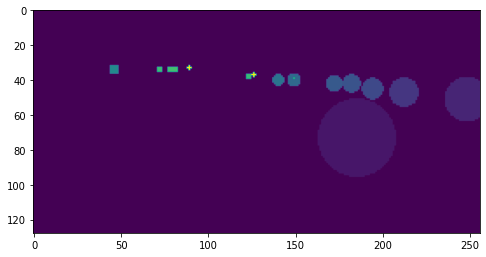

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(154.3628, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(154.7500, device='cuda:0')


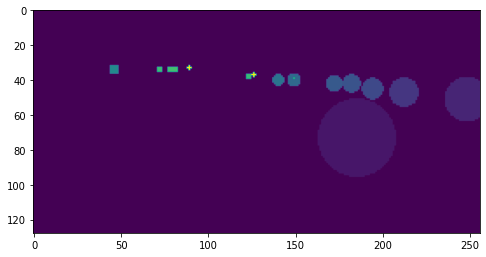

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


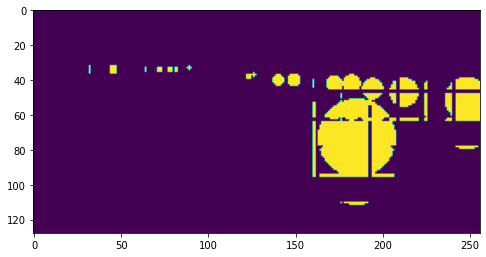

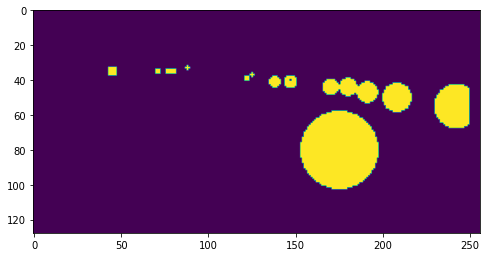

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:20<00:08,  1.22s/it]

theta_x: -0.0399
theta_y: -0.0026
theta_z: 0.0055
phi: 0.0019
gamma: -0.0072
rho: -0.0065


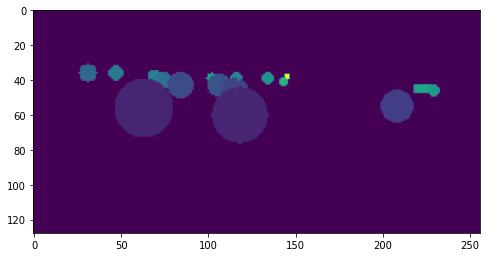

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(121.2471, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(121.3125, device='cuda:0')


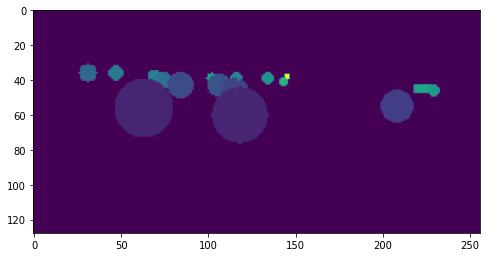

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


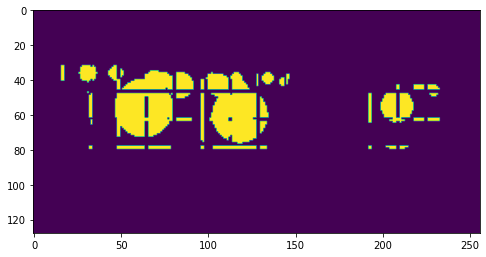

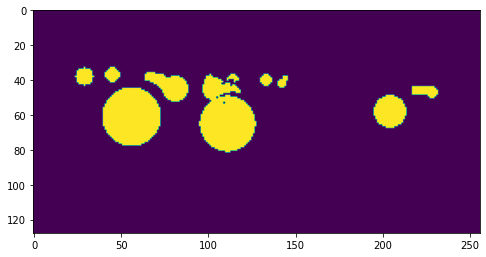

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:21<00:07,  1.22s/it]

theta_x: -0.0408
theta_y: -0.0040
theta_z: 0.0060
phi: 0.0017
gamma: -0.0073
rho: -0.0067


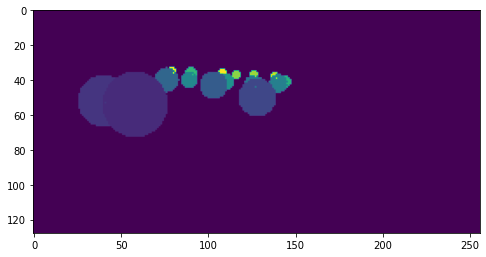

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(89.7410, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(90., device='cuda:0')


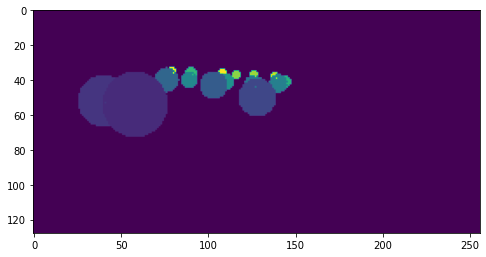

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


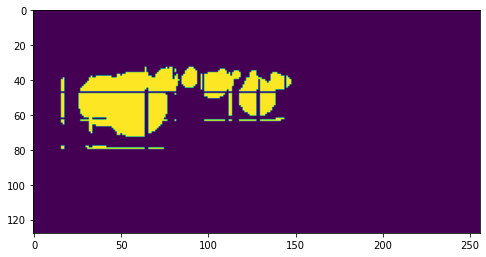

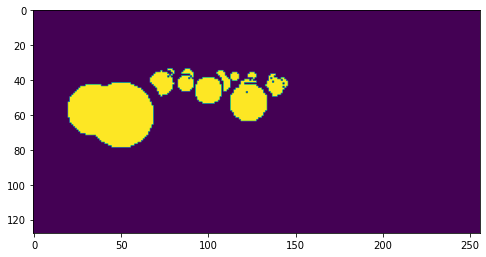

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:22<00:06,  1.20s/it]

theta_x: -0.0409
theta_y: -0.0077
theta_z: 0.0071
phi: 0.0017
gamma: -0.0069
rho: -0.0069


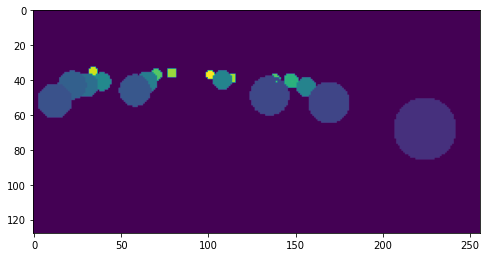

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(83.6976, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(83.8750, device='cuda:0')


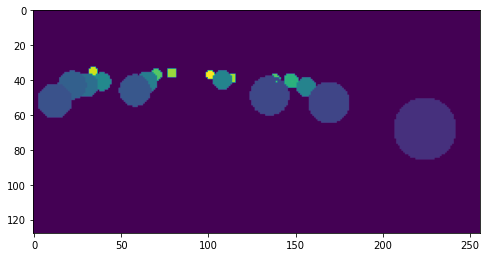

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


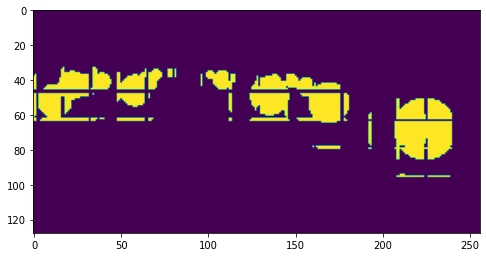

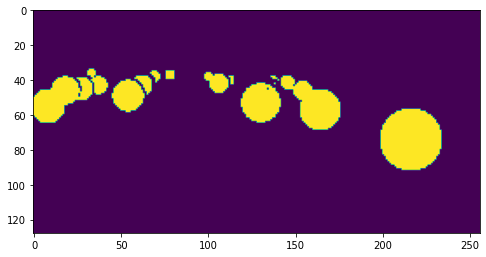

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:24<00:04,  1.20s/it]

theta_x: -0.0406
theta_y: -0.0070
theta_z: 0.0075
phi: 0.0011
gamma: -0.0074
rho: -0.0066


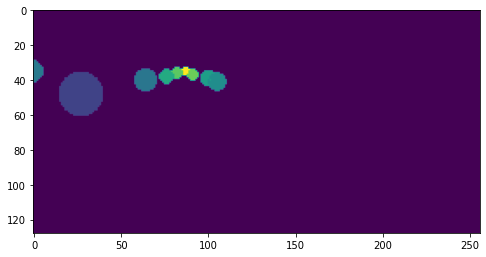

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(80.4811, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(80.6875, device='cuda:0')


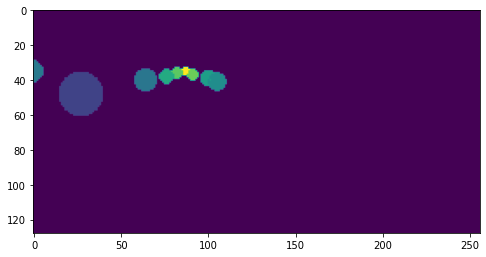

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


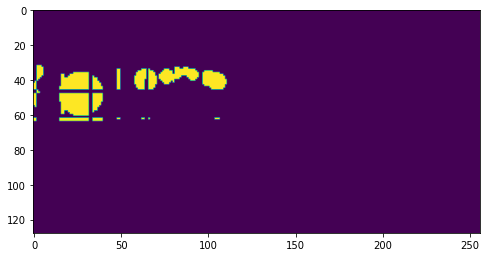

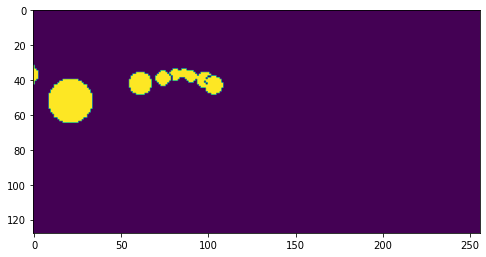

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:25<00:03,  1.19s/it]

theta_x: -0.0403
theta_y: -0.0086
theta_z: 0.0082
phi: 0.0009
gamma: -0.0074
rho: -0.0066


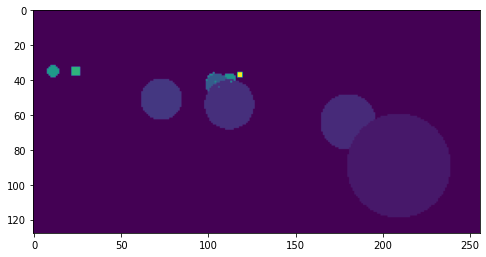

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(109.0138, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(109.1875, device='cuda:0')


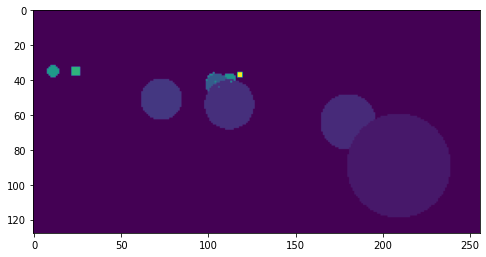

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


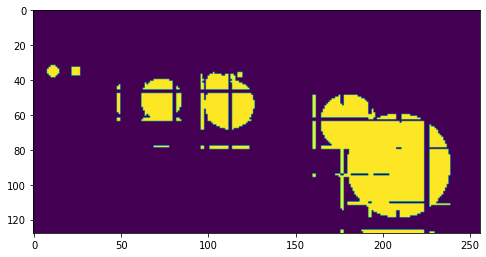

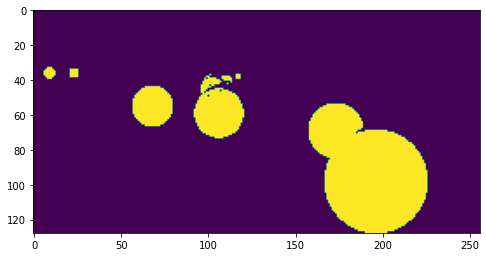

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:26<00:02,  1.18s/it]

theta_x: -0.0435
theta_y: -0.0086
theta_z: 0.0084
phi: 0.0018
gamma: -0.0077
rho: -0.0070


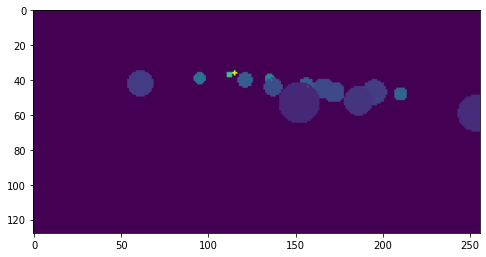

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(159.2221, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(159.5000, device='cuda:0')


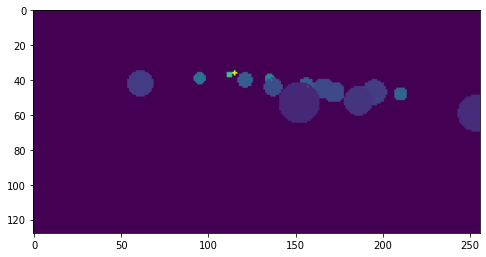

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


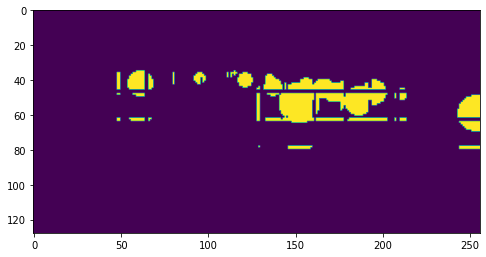

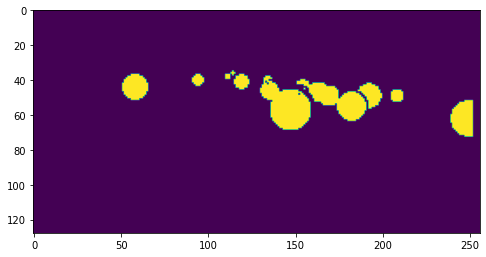

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:27<00:01,  1.19s/it]

theta_x: -0.0440
theta_y: -0.0097
theta_z: 0.0091
phi: 0.0014
gamma: -0.0078
rho: -0.0069


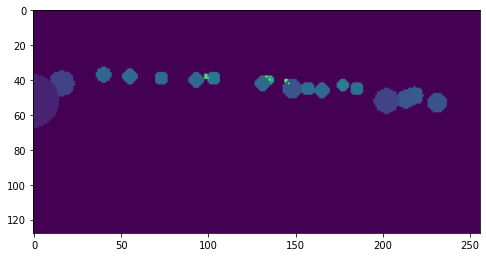

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(144.2121, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(144.3750, device='cuda:0')


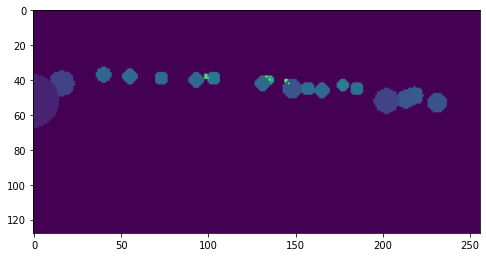

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


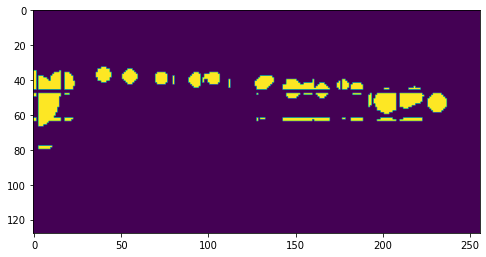

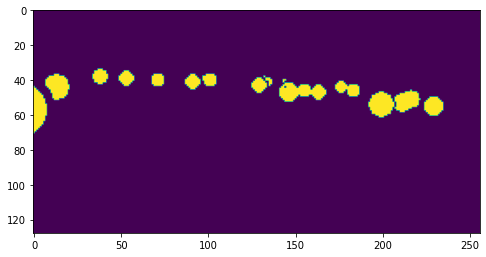

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

theta_x: -0.0443
theta_y: -0.0102
theta_z: 0.0093
phi: 0.0009
gamma: -0.0078
rho: -0.0069
Train Epoch: (4, 0) 	LR: 0.001000	Loss: 1.736413


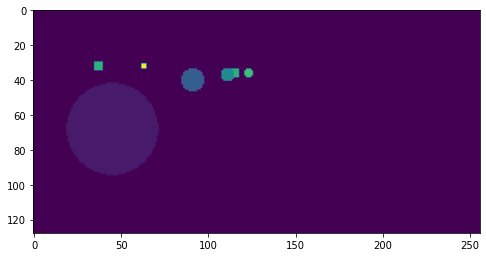

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(108.1749, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(108.5625, device='cuda:0')


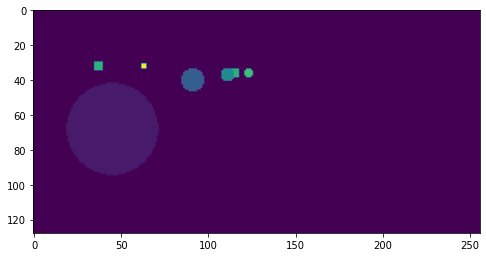

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


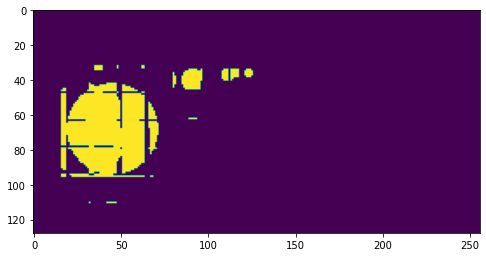

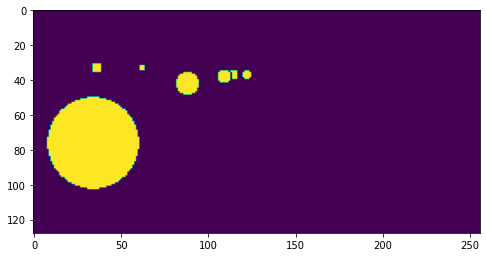

  4%|███▍                                                                               | 1/24 [00:01<00:27,  1.19s/it]

theta_x: -0.0443
theta_y: -0.0127
theta_z: 0.0101
phi: 0.0015
gamma: -0.0075
rho: -0.0070


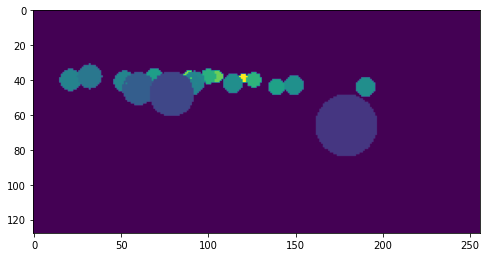

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(74.8230, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(74.9375, device='cuda:0')


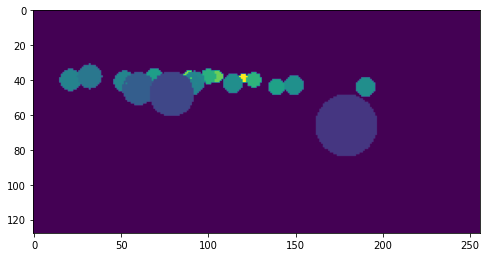

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


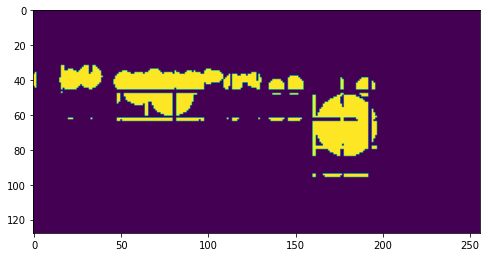

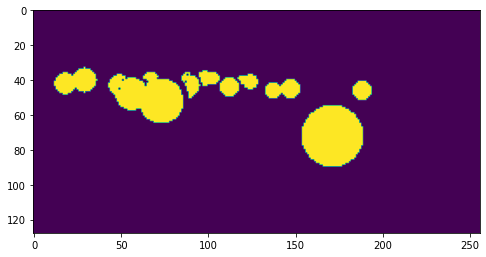

  8%|██████▉                                                                            | 2/24 [00:02<00:25,  1.17s/it]

theta_x: -0.0454
theta_y: -0.0118
theta_z: 0.0103
phi: 0.0015
gamma: -0.0079
rho: -0.0072


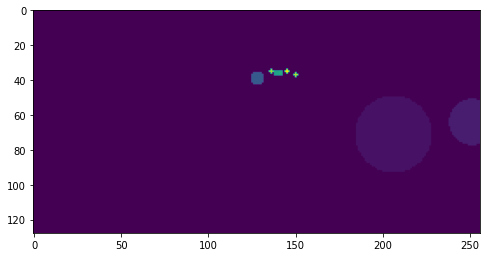

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(192.0329, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(192.1250, device='cuda:0')


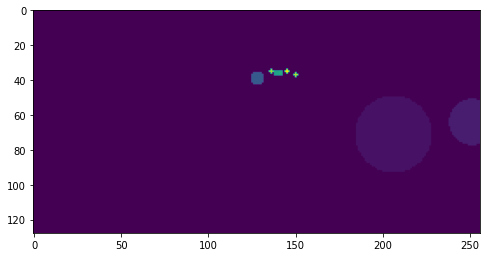

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


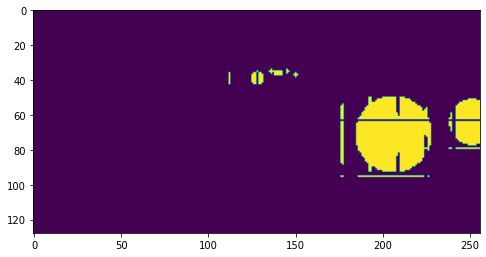

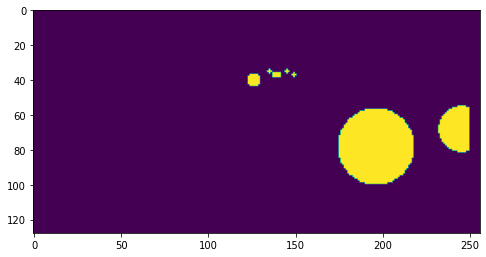

 12%|██████████▍                                                                        | 3/24 [00:03<00:24,  1.17s/it]

theta_x: -0.0456
theta_y: -0.0132
theta_z: 0.0108
phi: 0.0013
gamma: -0.0077
rho: -0.0071


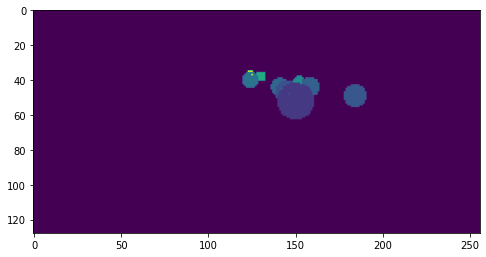

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(118.4094, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(118.5625, device='cuda:0')


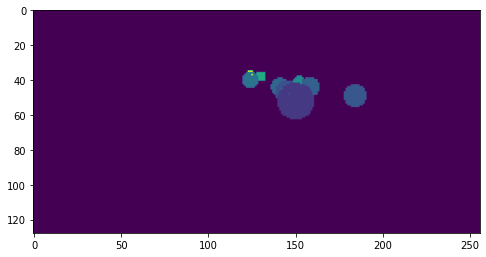

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


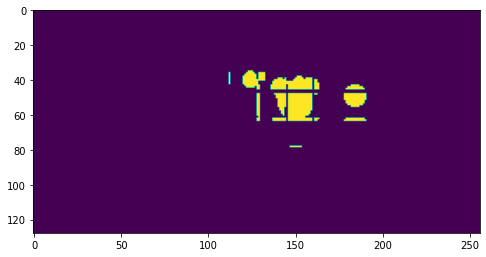

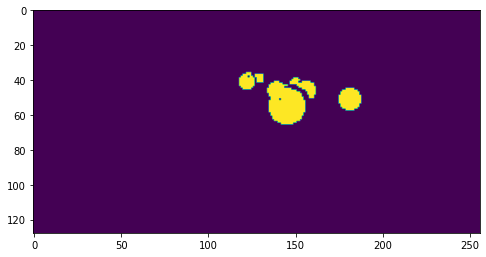

 17%|█████████████▊                                                                     | 4/24 [00:04<00:23,  1.18s/it]

theta_x: -0.0453
theta_y: -0.0136
theta_z: 0.0112
phi: 0.0010
gamma: -0.0077
rho: -0.0069


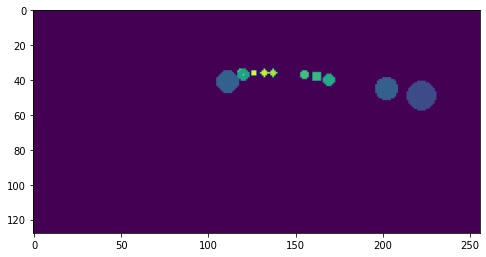

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(105.8155, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(105.9375, device='cuda:0')


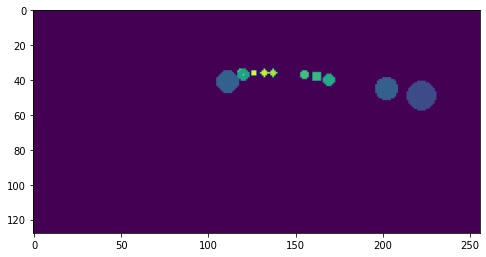

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


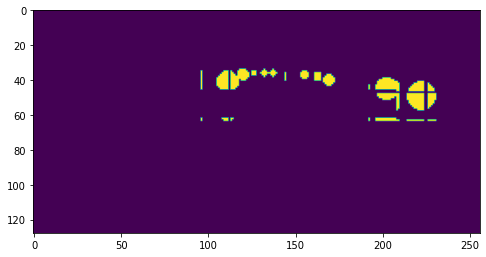

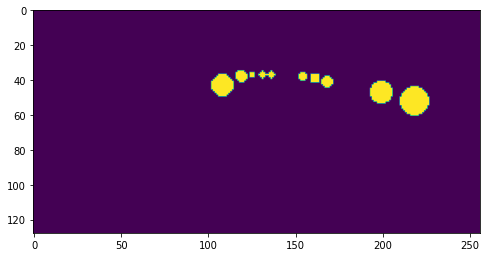

 21%|█████████████████▎                                                                 | 5/24 [00:05<00:22,  1.16s/it]

theta_x: -0.0437
theta_y: -0.0156
theta_z: 0.0121
phi: 0.0010
gamma: -0.0074
rho: -0.0065


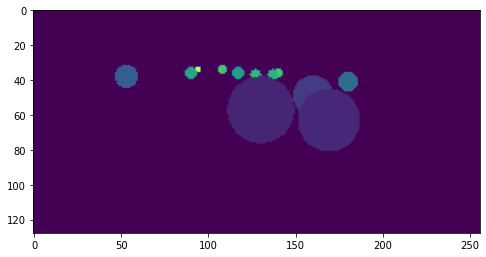

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(104.1320, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(104.3750, device='cuda:0')


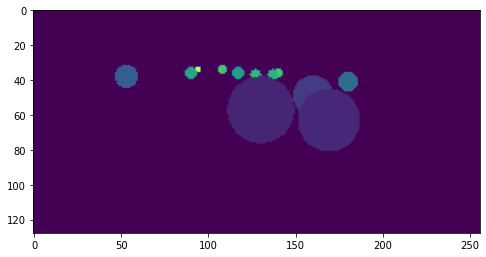

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


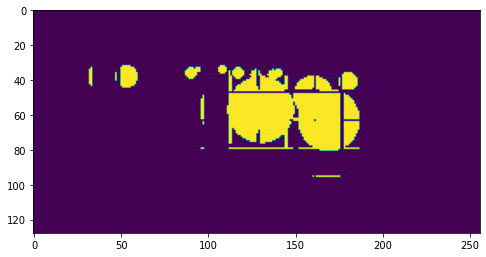

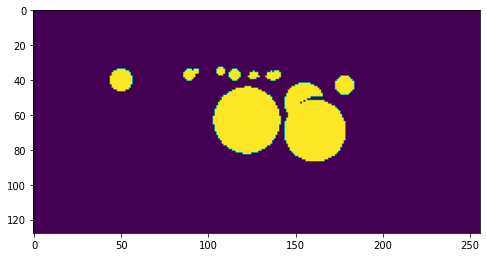

 25%|████████████████████▊                                                              | 6/24 [00:06<00:20,  1.15s/it]

theta_x: -0.0444
theta_y: -0.0160
theta_z: 0.0129
phi: 0.0010
gamma: -0.0077
rho: -0.0066


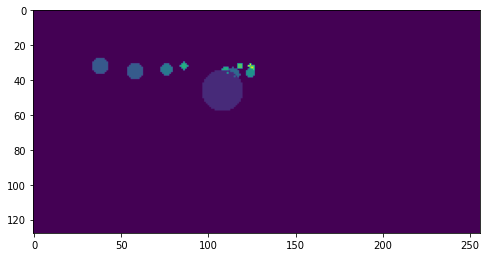

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(149.4354, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(149.6250, device='cuda:0')


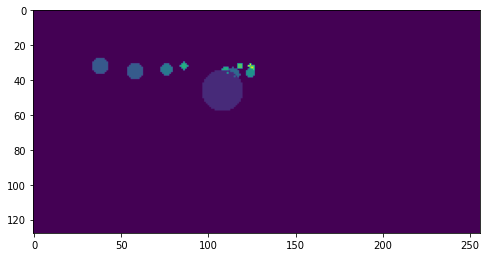

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


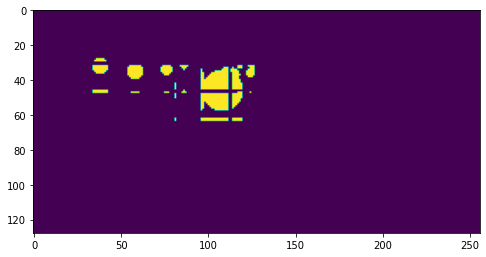

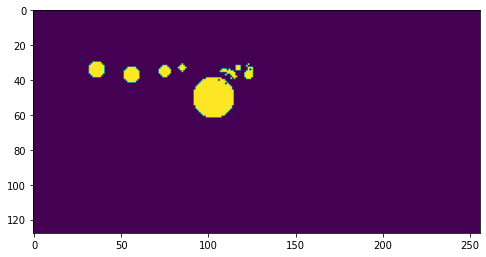

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:19,  1.14s/it]

theta_x: -0.0468
theta_y: -0.0159
theta_z: 0.0133
phi: 0.0014
gamma: -0.0081
rho: -0.0070


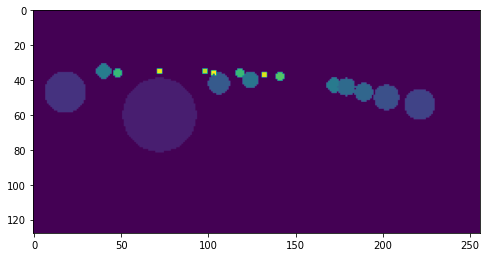

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(118.5602, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(118.8125, device='cuda:0')


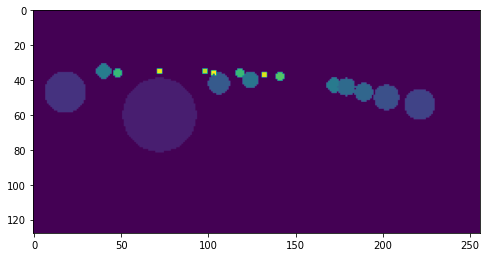

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


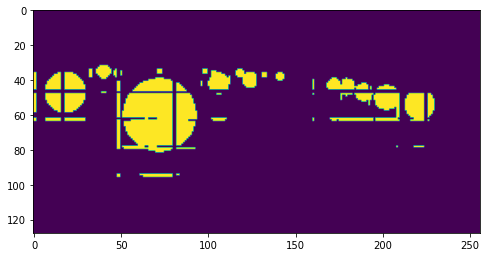

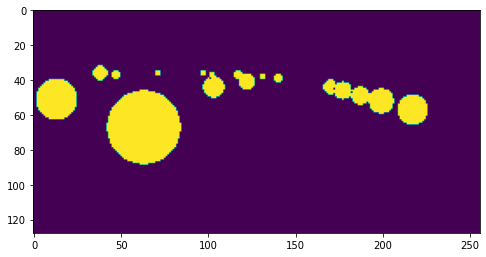

 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:18,  1.18s/it]

theta_x: -0.0448
theta_y: -0.0178
theta_z: 0.0136
phi: 0.0010
gamma: -0.0081
rho: -0.0065


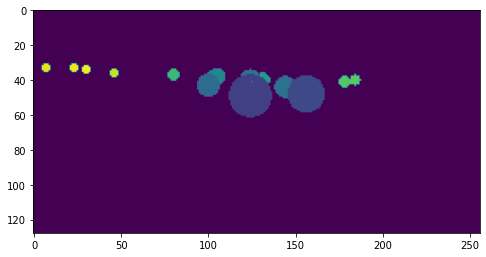

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(88.6305, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(89.0625, device='cuda:0')


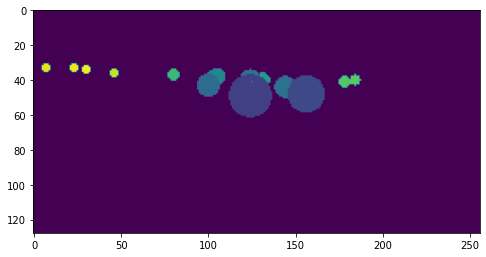

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


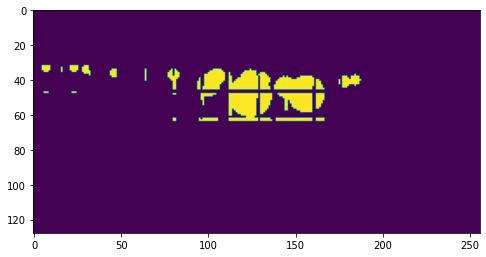

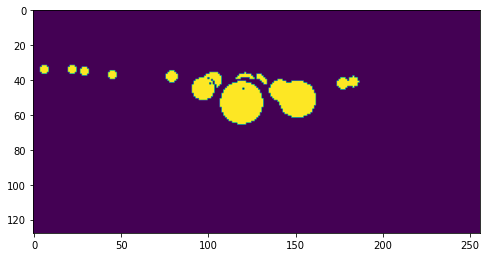

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:17,  1.19s/it]

theta_x: -0.0461
theta_y: -0.0175
theta_z: 0.0139
phi: 0.0010
gamma: -0.0083
rho: -0.0068


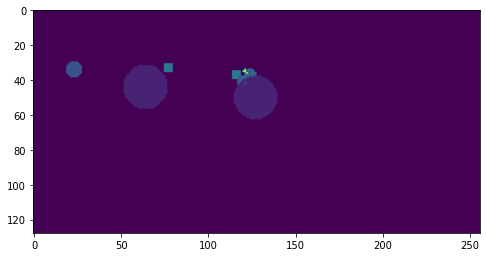

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(171.9740, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(172.2500, device='cuda:0')


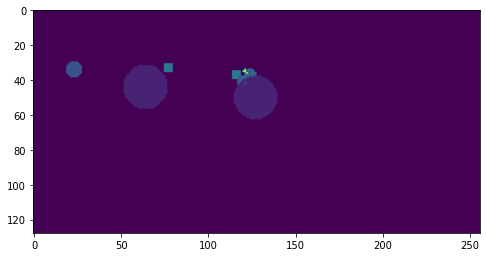

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


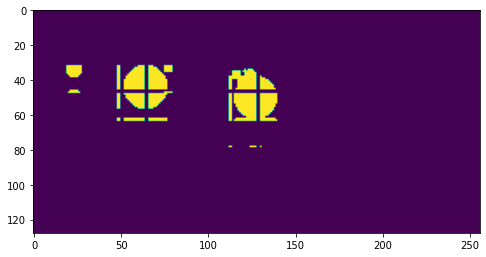

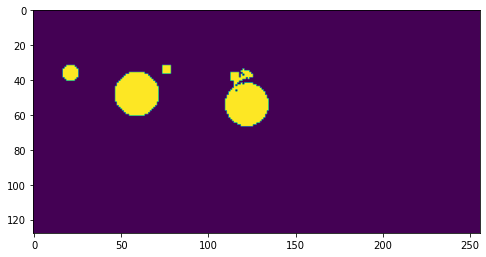

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:16,  1.17s/it]

theta_x: -0.0518
theta_y: -0.0164
theta_z: 0.0134
phi: 0.0014
gamma: -0.0086
rho: -0.0073


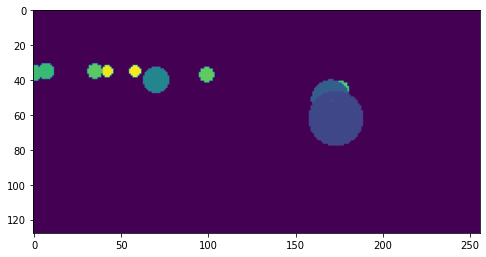

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(61.8185, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(62.0625, device='cuda:0')


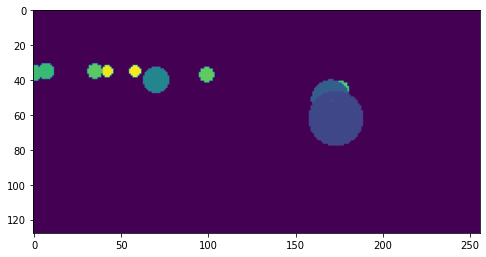

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


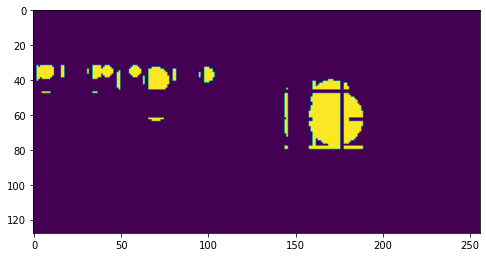

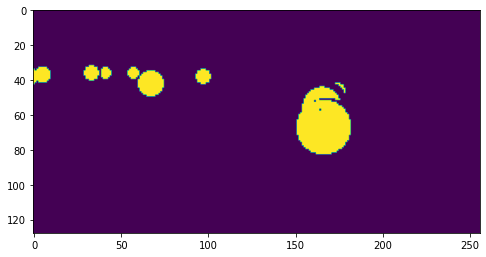

 46%|█████████████████████████████████████▌                                            | 11/24 [00:12<00:15,  1.17s/it]

theta_x: -0.0515
theta_y: -0.0175
theta_z: 0.0140
phi: 0.0016
gamma: -0.0085
rho: -0.0073


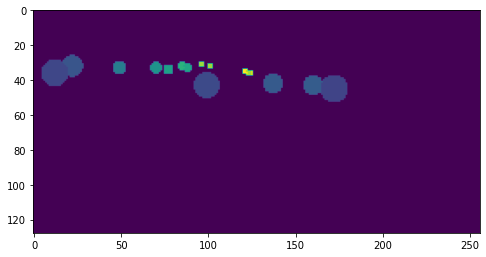

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(125.6302, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(125.8125, device='cuda:0')


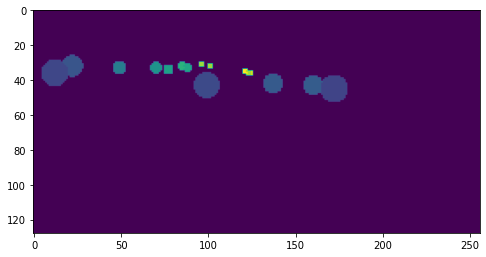

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


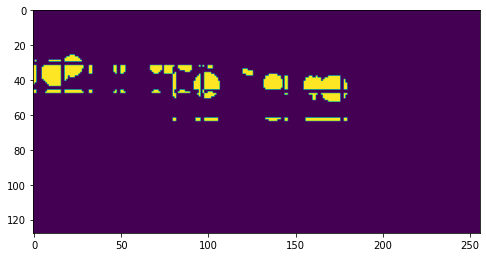

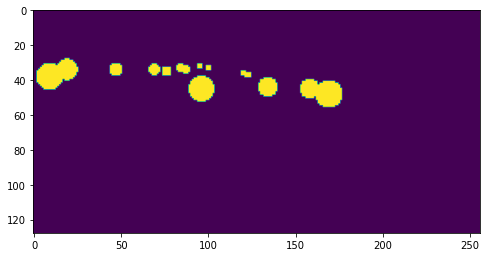

 50%|█████████████████████████████████████████                                         | 12/24 [00:14<00:14,  1.19s/it]

theta_x: -0.0503
theta_y: -0.0211
theta_z: 0.0150
phi: 0.0016
gamma: -0.0082
rho: -0.0070


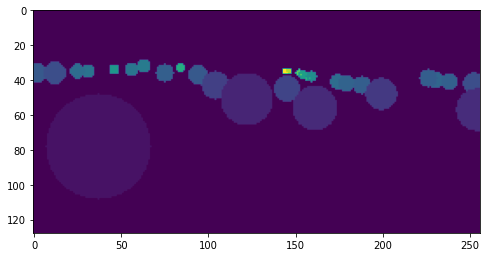

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(136.6681, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(136.7500, device='cuda:0')


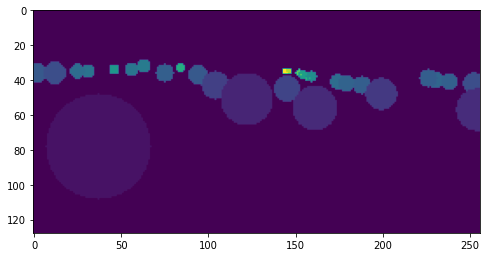

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


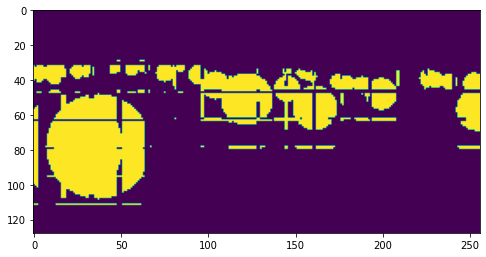

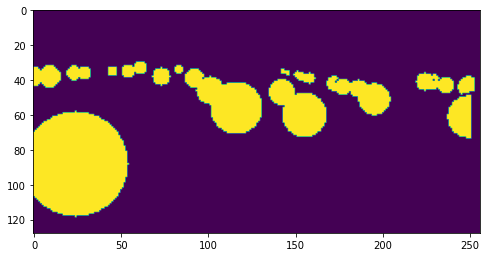

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:15<00:13,  1.19s/it]

theta_x: -0.0502
theta_y: -0.0227
theta_z: 0.0157
phi: 0.0016
gamma: -0.0083
rho: -0.0069


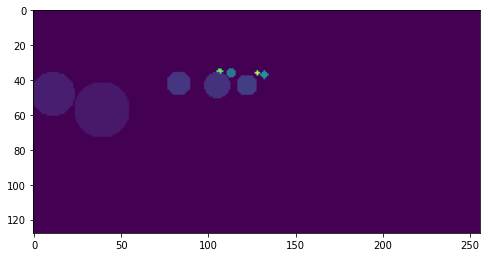

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(193.2389, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(193.5000, device='cuda:0')


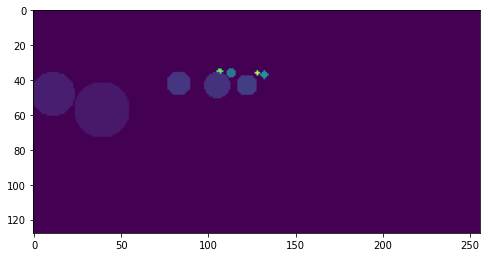

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


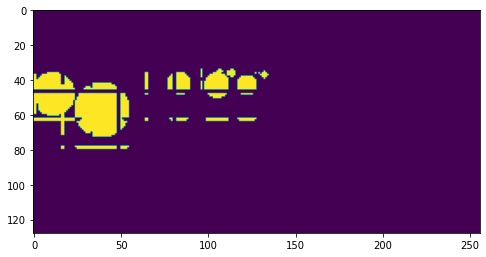

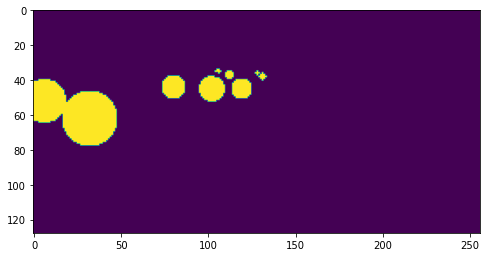

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:16<00:11,  1.20s/it]

theta_x: -0.0500
theta_y: -0.0228
theta_z: 0.0157
phi: 0.0009
gamma: -0.0086
rho: -0.0067


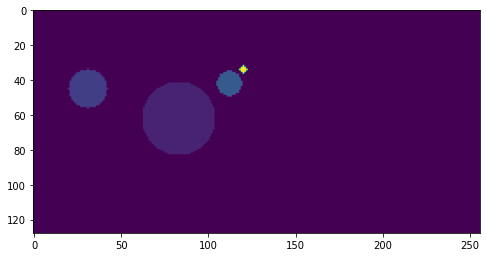

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(102.0391, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(102.1875, device='cuda:0')


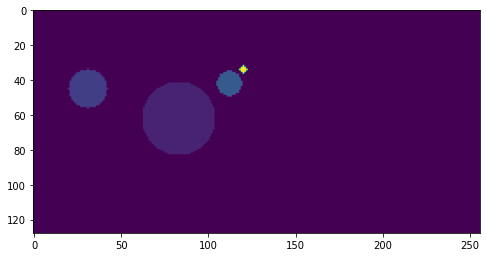

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


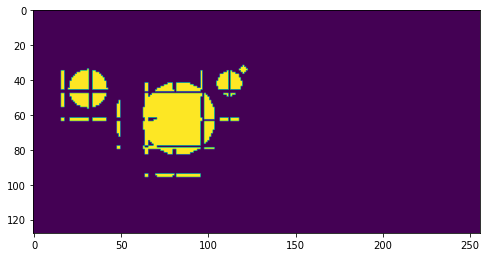

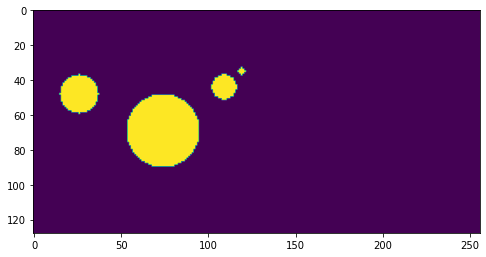

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:17<00:10,  1.22s/it]

theta_x: -0.0497
theta_y: -0.0242
theta_z: 0.0162
phi: 0.0006
gamma: -0.0086
rho: -0.0065


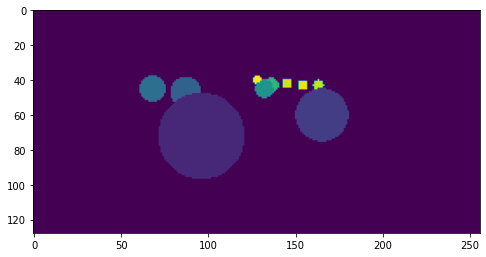

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(75.3346, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(75.4375, device='cuda:0')


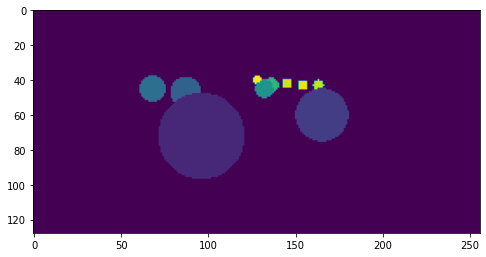

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


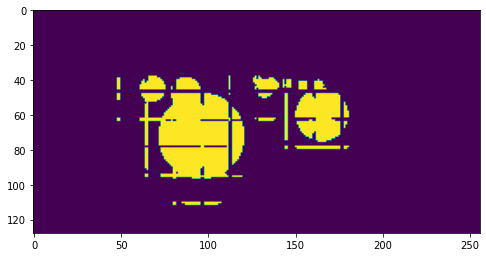

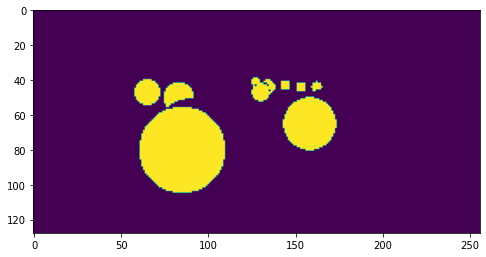

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:18<00:09,  1.20s/it]

theta_x: -0.0506
theta_y: -0.0234
theta_z: 0.0165
phi: 0.0006
gamma: -0.0090
rho: -0.0066


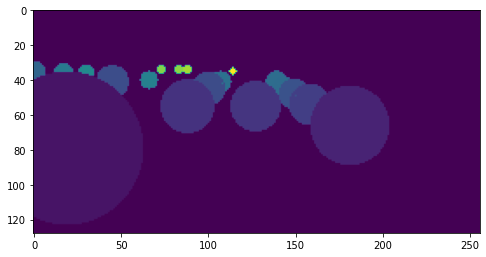

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(92.8979, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(93.0625, device='cuda:0')


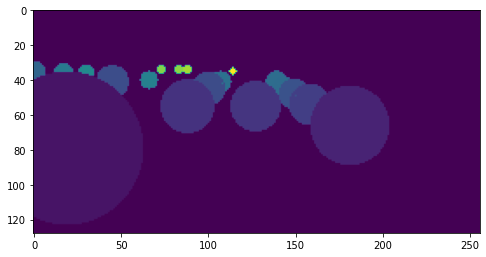

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


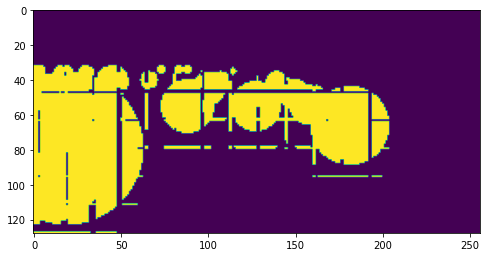

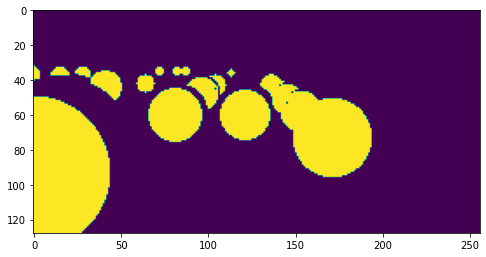

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:20<00:08,  1.18s/it]

theta_x: -0.0510
theta_y: -0.0251
theta_z: 0.0170
phi: 0.0007
gamma: -0.0091
rho: -0.0066


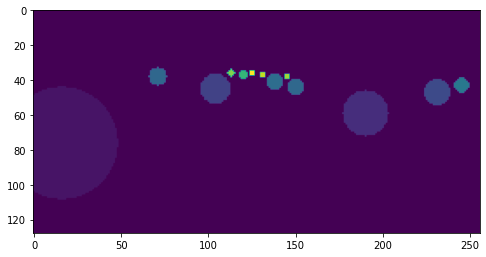

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(122.6879, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(122.8750, device='cuda:0')


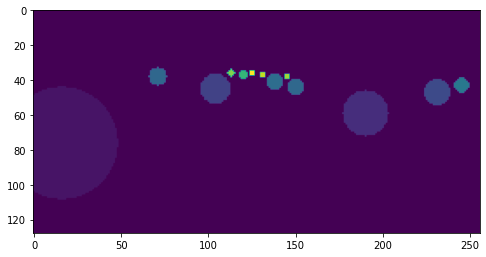

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


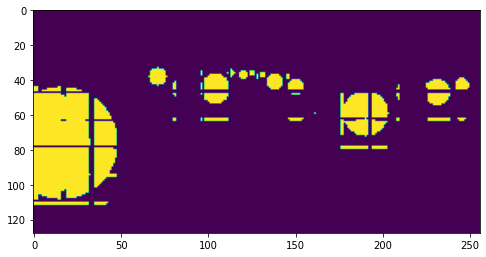

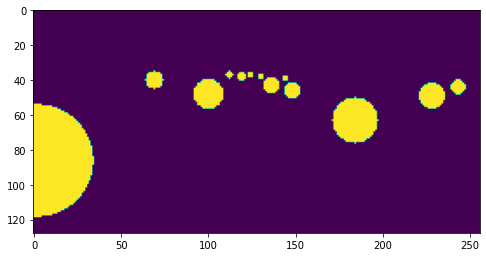

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:21<00:07,  1.19s/it]

theta_x: -0.0517
theta_y: -0.0247
theta_z: 0.0175
phi: 0.0005
gamma: -0.0096
rho: -0.0065


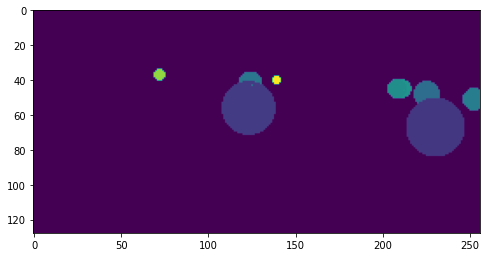

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(77.1053, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(77.1875, device='cuda:0')


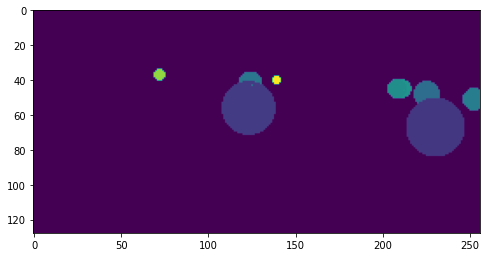

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


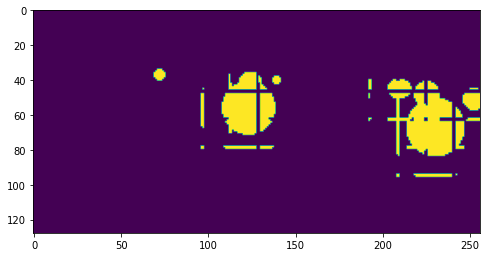

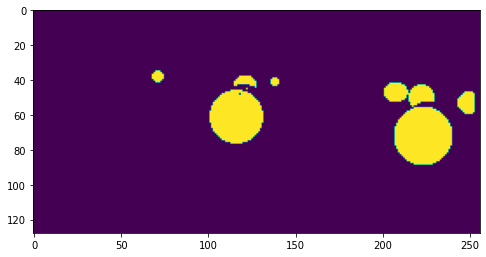

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:22<00:05,  1.19s/it]

theta_x: -0.0522
theta_y: -0.0240
theta_z: 0.0177
phi: 0.0005
gamma: -0.0097
rho: -0.0065


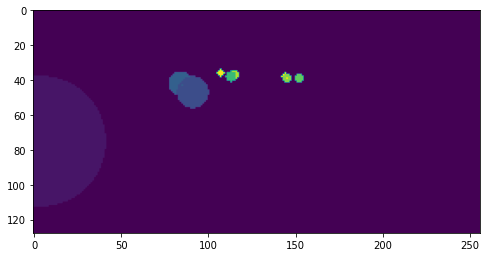

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(96.9761, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(97.0625, device='cuda:0')


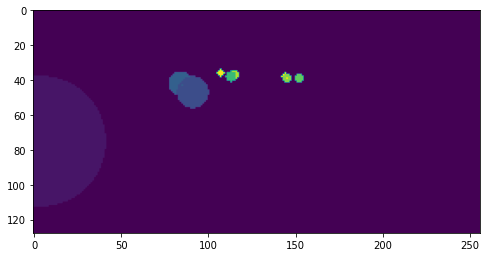

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


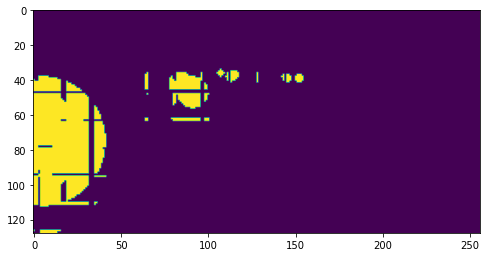

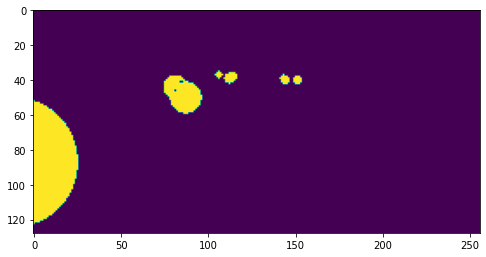

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:23<00:04,  1.18s/it]

theta_x: -0.0524
theta_y: -0.0233
theta_z: 0.0181
phi: 0.0005
gamma: -0.0097
rho: -0.0064


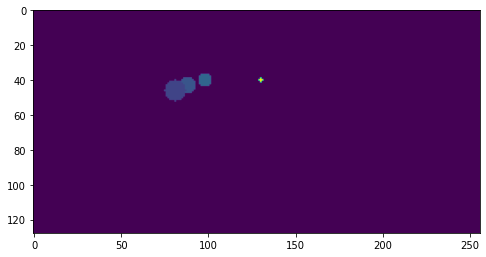

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(168.3447, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(168.6250, device='cuda:0')


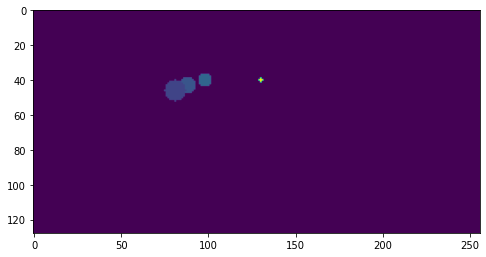

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


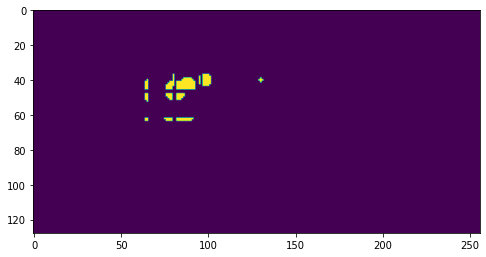

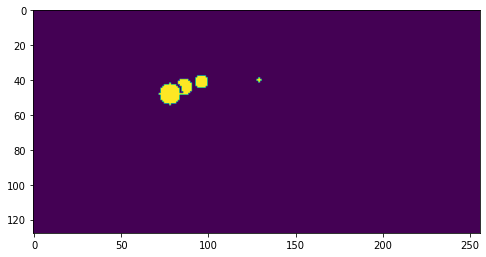

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:24<00:03,  1.16s/it]

theta_x: -0.0551
theta_y: -0.0242
theta_z: 0.0183
phi: 0.0010
gamma: -0.0100
rho: -0.0067


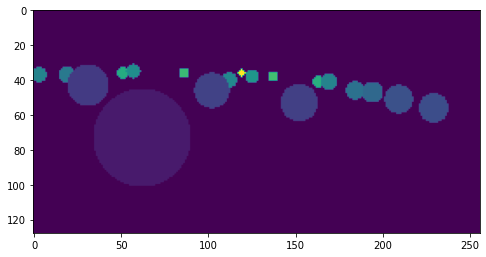

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(103.5704, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(103.7500, device='cuda:0')


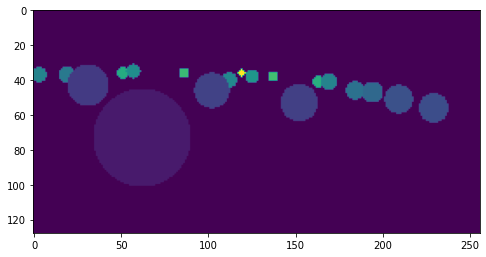

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


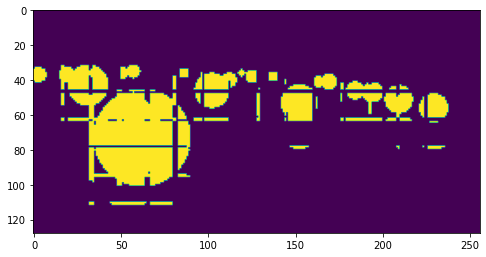

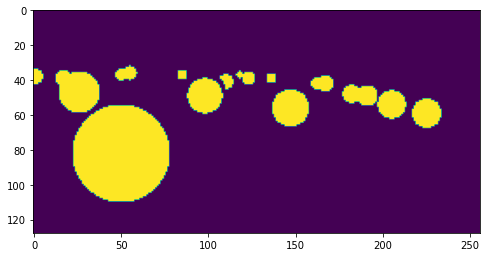

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:25<00:02,  1.17s/it]

theta_x: -0.0547
theta_y: -0.0265
theta_z: 0.0189
phi: 0.0008
gamma: -0.0097
rho: -0.0066


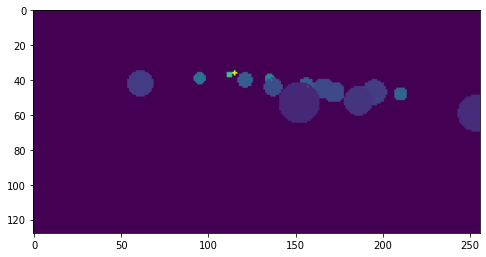

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(159.1818, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(159.5000, device='cuda:0')


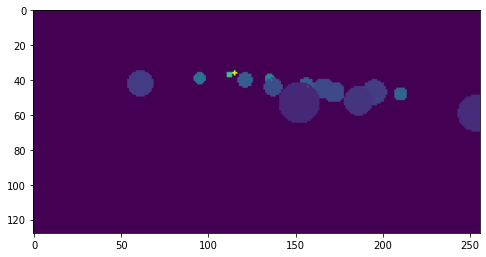

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


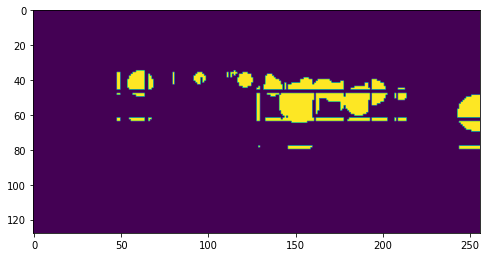

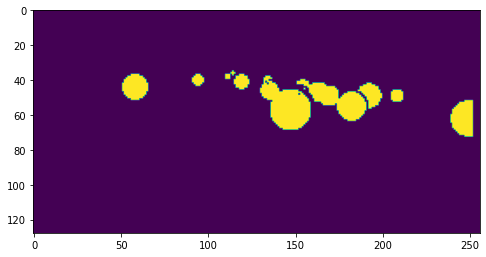

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:27<00:01,  1.17s/it]

theta_x: -0.0552
theta_y: -0.0265
theta_z: 0.0192
phi: 0.0009
gamma: -0.0097
rho: -0.0067


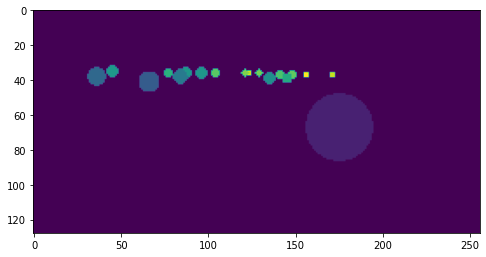

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(119.6427, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(119.6875, device='cuda:0')


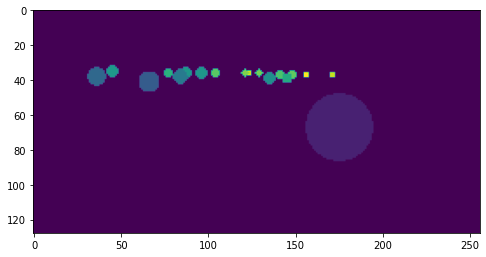

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


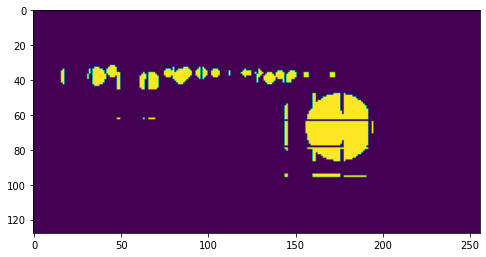

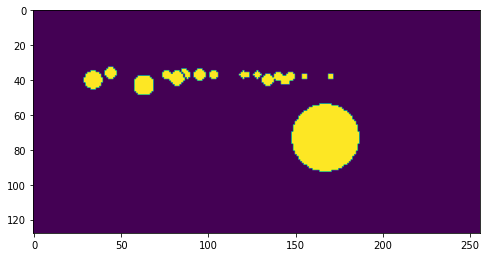

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

theta_x: -0.0561
theta_y: -0.0286
theta_z: 0.0194
phi: 0.0006
gamma: -0.0095
rho: -0.0065
Train Epoch: (4, 1) 	LR: 0.001000	Loss: 1.612772


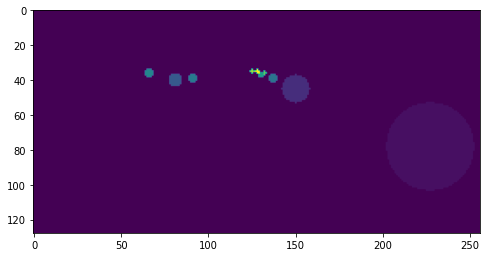

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(196.2220, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(196.5000, device='cuda:0')


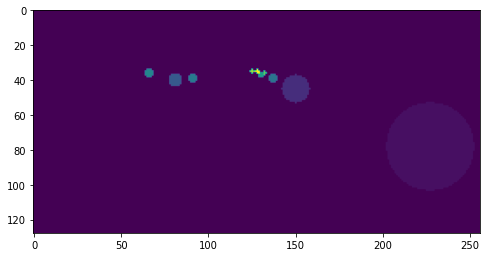

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


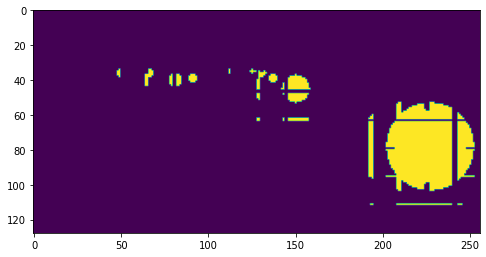

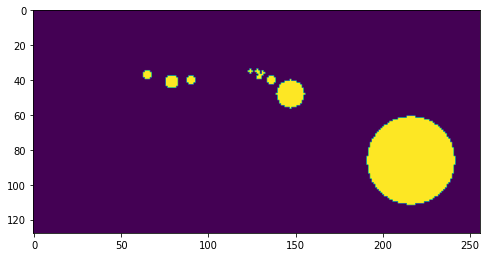

  4%|███▍                                                                               | 1/24 [00:01<00:26,  1.16s/it]

theta_x: -0.0587
theta_y: -0.0296
theta_z: 0.0200
phi: 0.0013
gamma: -0.0094
rho: -0.0070


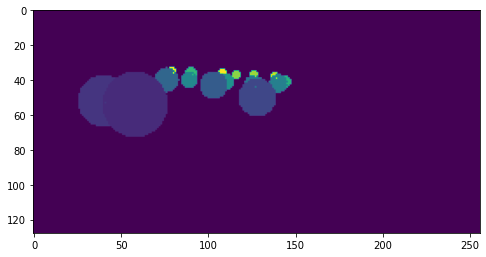

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(89.7186, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(90., device='cuda:0')


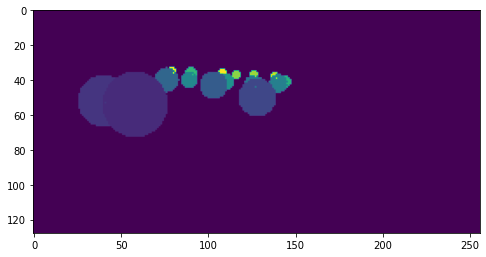

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


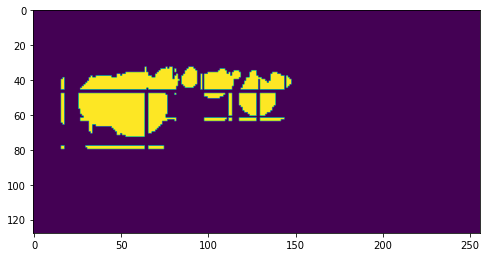

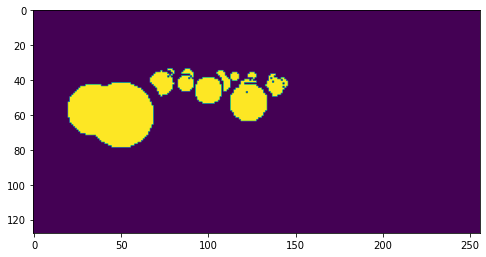

  8%|██████▉                                                                            | 2/24 [00:02<00:25,  1.15s/it]

theta_x: -0.0577
theta_y: -0.0297
theta_z: 0.0206
phi: 0.0013
gamma: -0.0095
rho: -0.0067


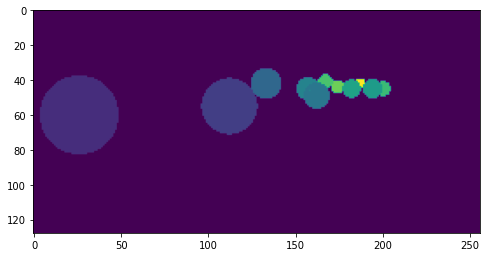

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(69.9882, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(69.9375, device='cuda:0')


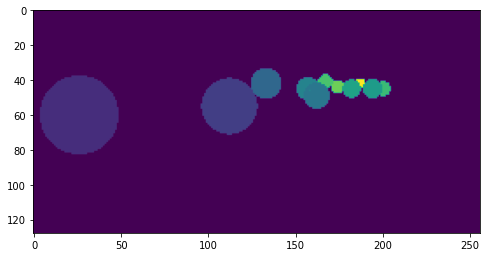

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


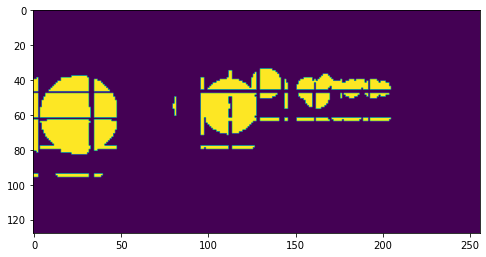

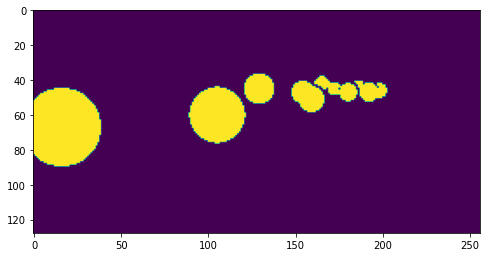

 12%|██████████▍                                                                        | 3/24 [00:03<00:24,  1.14s/it]

theta_x: -0.0573
theta_y: -0.0302
theta_z: 0.0211
phi: 0.0011
gamma: -0.0097
rho: -0.0065


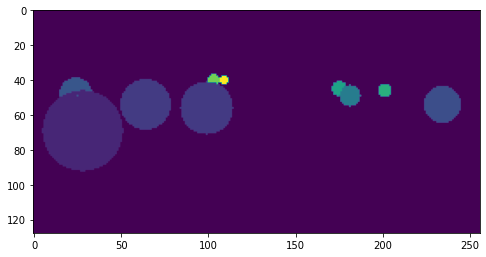

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(82.3261, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(82.5000, device='cuda:0')


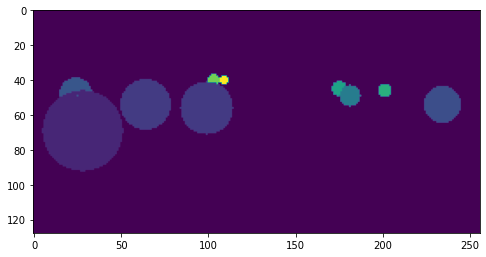

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


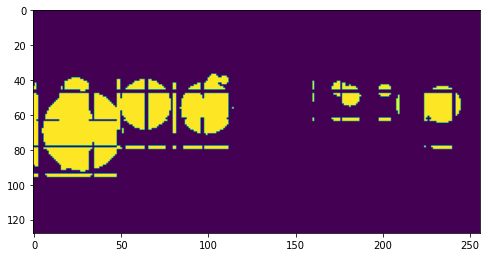

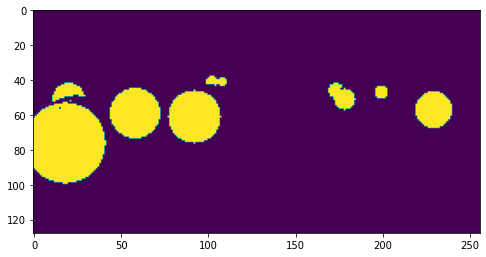

 17%|█████████████▊                                                                     | 4/24 [00:04<00:23,  1.16s/it]

theta_x: -0.0570
theta_y: -0.0314
theta_z: 0.0219
phi: 0.0009
gamma: -0.0096
rho: -0.0063


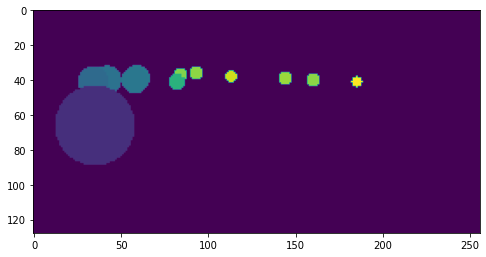

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(67.4827, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(67.4375, device='cuda:0')


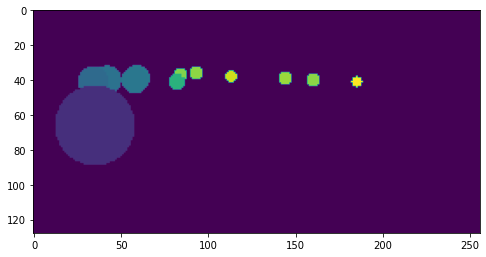

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


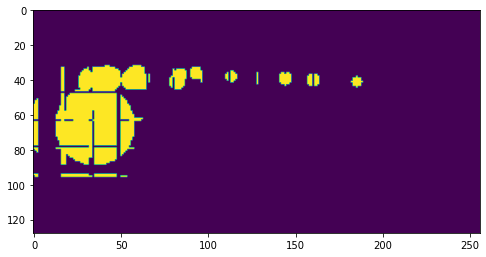

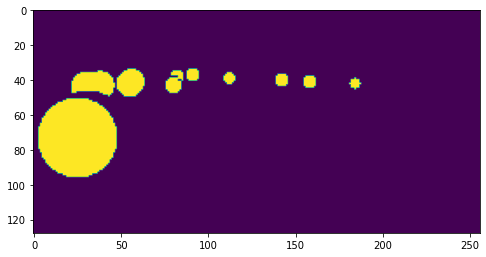

 21%|█████████████████▎                                                                 | 5/24 [00:05<00:21,  1.15s/it]

theta_x: -0.0563
theta_y: -0.0330
theta_z: 0.0225
phi: 0.0006
gamma: -0.0094
rho: -0.0061


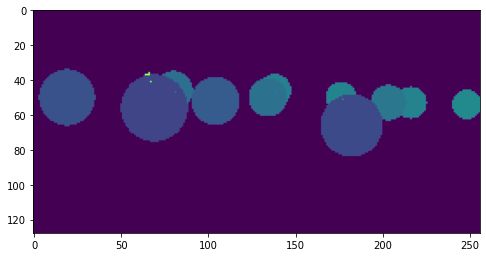

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(51.4109, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(51.5938, device='cuda:0')


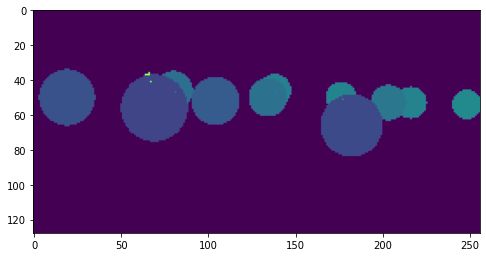

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


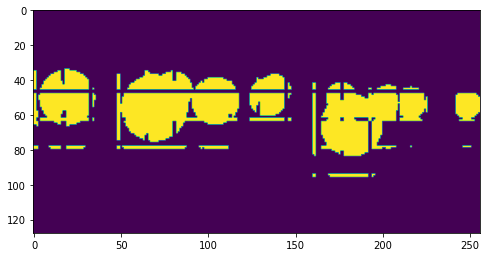

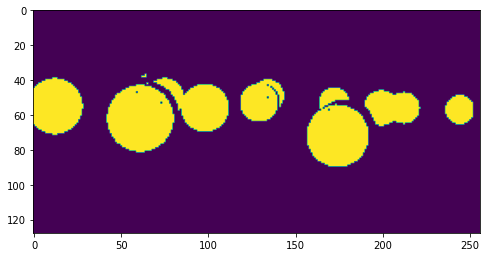

 25%|████████████████████▊                                                              | 6/24 [00:06<00:20,  1.15s/it]

theta_x: -0.0582
theta_y: -0.0324
theta_z: 0.0227
phi: 0.0008
gamma: -0.0099
rho: -0.0065


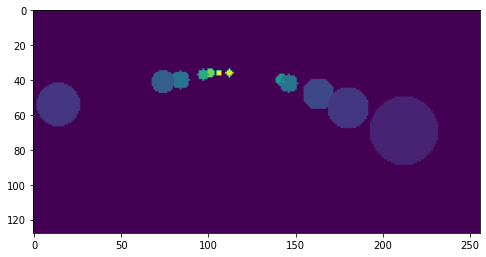

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(106.0155, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(106.2500, device='cuda:0')


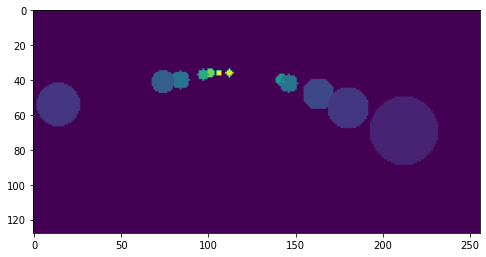

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


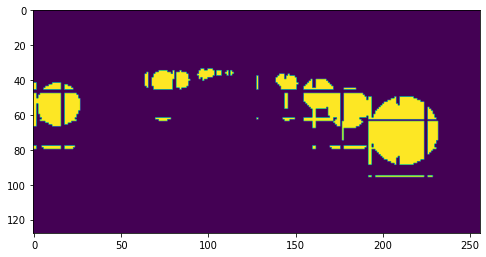

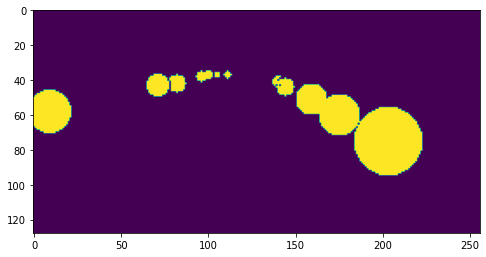

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:19,  1.14s/it]

theta_x: -0.0589
theta_y: -0.0330
theta_z: 0.0232
phi: 0.0008
gamma: -0.0099
rho: -0.0065


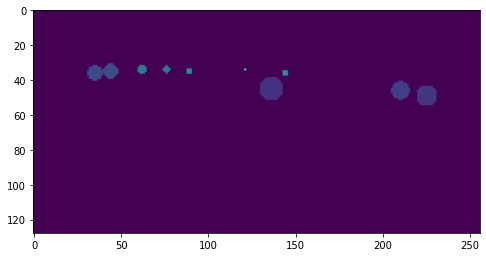

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(215.9860, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(216.3750, device='cuda:0')


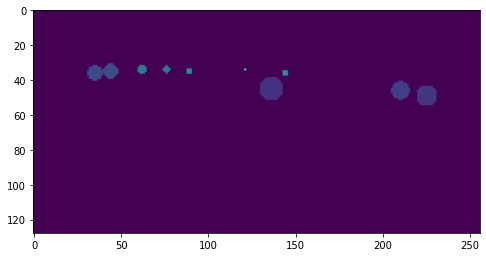

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


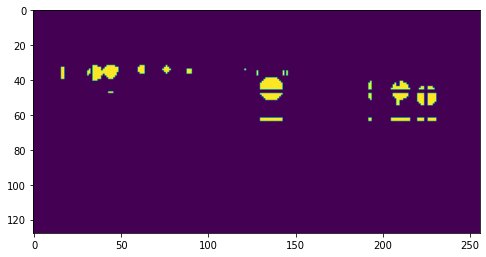

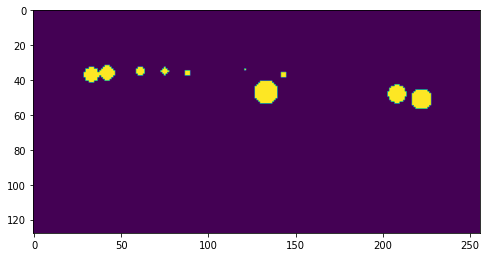

 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:18,  1.15s/it]

theta_x: -0.0593
theta_y: -0.0320
theta_z: 0.0233
phi: 0.0009
gamma: -0.0102
rho: -0.0065


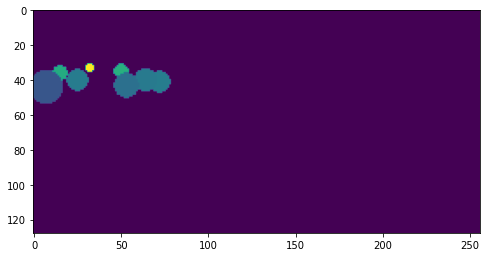

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(79.0003, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(79.3750, device='cuda:0')


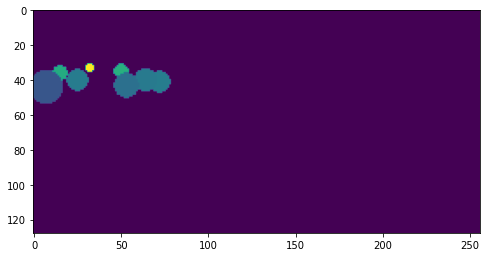

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


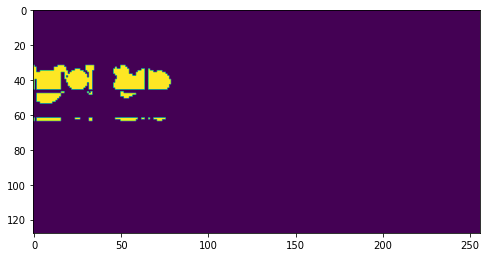

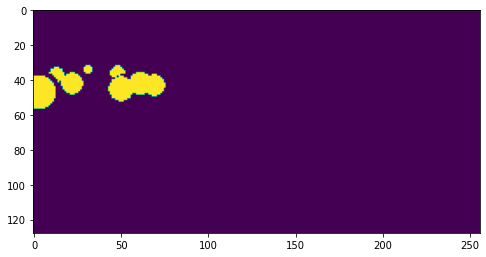

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:17,  1.14s/it]

theta_x: -0.0595
theta_y: -0.0323
theta_z: 0.0237
phi: 0.0013
gamma: -0.0100
rho: -0.0065


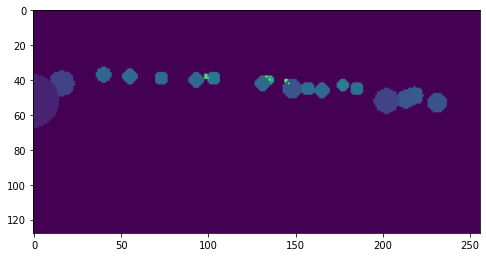

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(144.1427, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(144.3750, device='cuda:0')


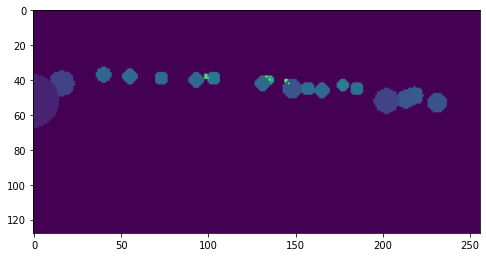

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


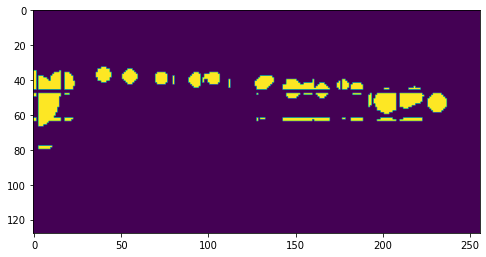

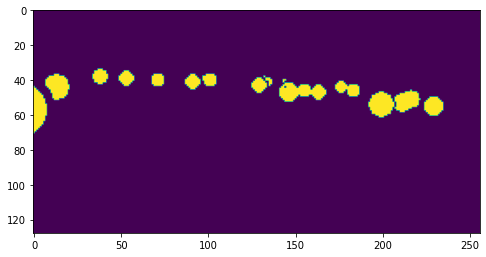

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:15,  1.14s/it]

theta_x: -0.0607
theta_y: -0.0305
theta_z: 0.0240
phi: 0.0014
gamma: -0.0109
rho: -0.0066


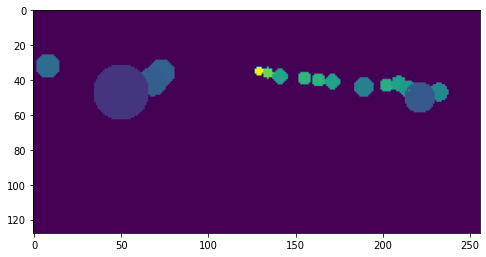

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(84.5732, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(84.6875, device='cuda:0')


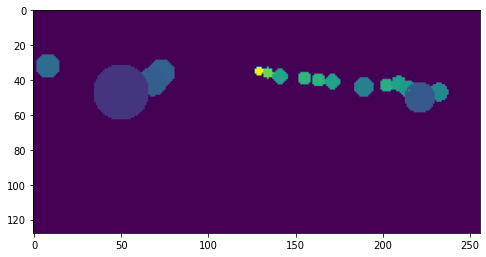

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


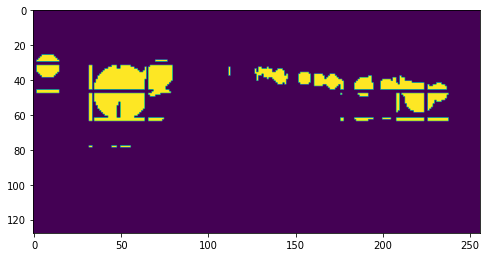

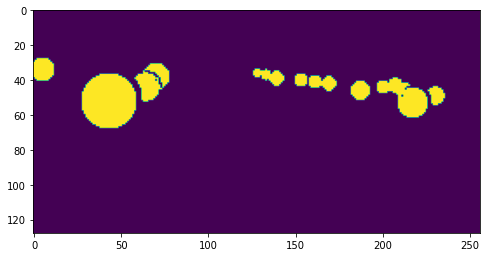

 46%|█████████████████████████████████████▌                                            | 11/24 [00:12<00:14,  1.15s/it]

theta_x: -0.0612
theta_y: -0.0313
theta_z: 0.0243
phi: 0.0012
gamma: -0.0108
rho: -0.0066


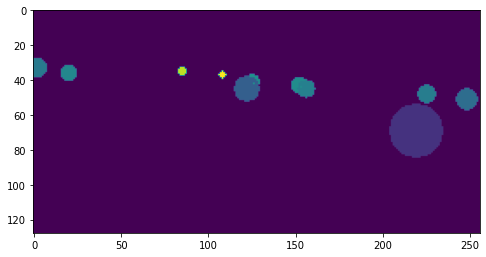

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(93.8434, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(94.0625, device='cuda:0')


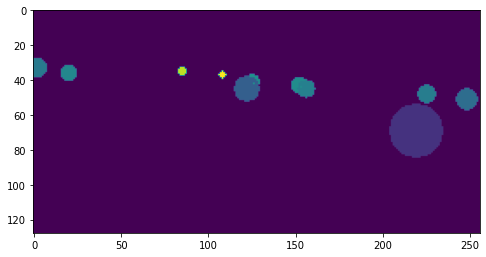

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


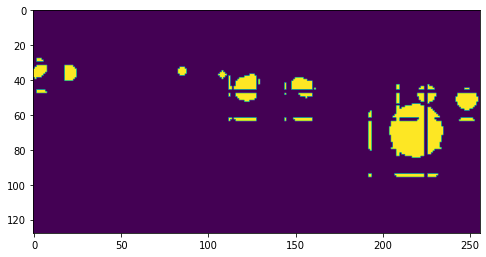

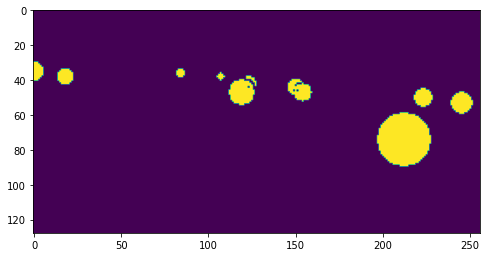

 50%|█████████████████████████████████████████                                         | 12/24 [00:13<00:14,  1.18s/it]

theta_x: -0.0620
theta_y: -0.0321
theta_z: 0.0245
phi: 0.0007
gamma: -0.0110
rho: -0.0066


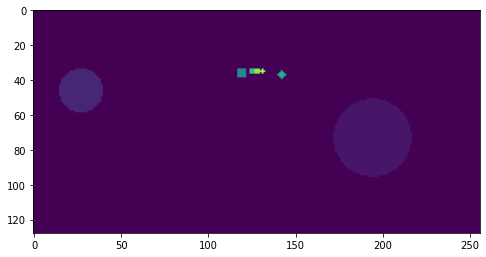

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(153.3942, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(153.6250, device='cuda:0')


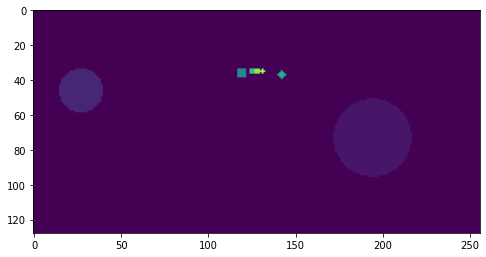

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


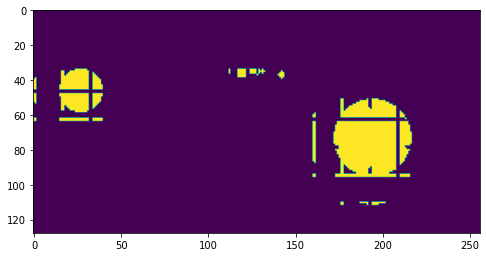

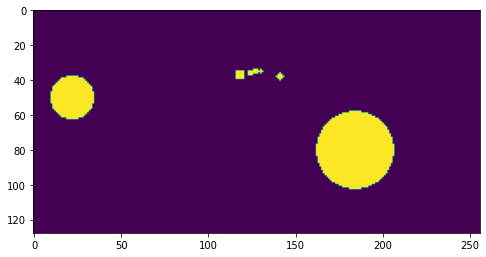

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:15<00:12,  1.18s/it]

theta_x: -0.0612
theta_y: -0.0328
theta_z: 0.0248
phi: 0.0005
gamma: -0.0109
rho: -0.0063


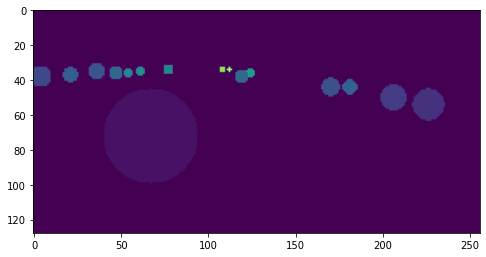

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(159.1623, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(159.5000, device='cuda:0')


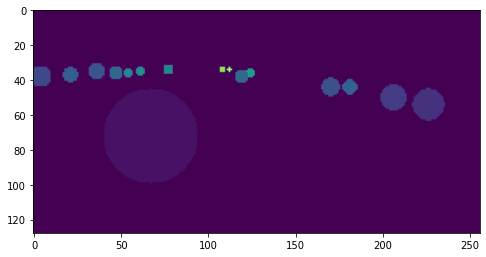

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


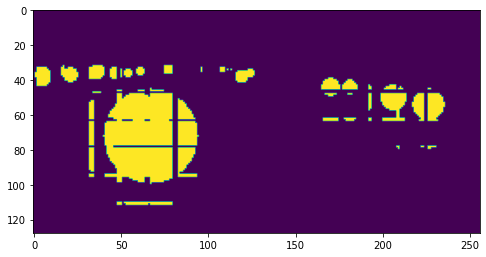

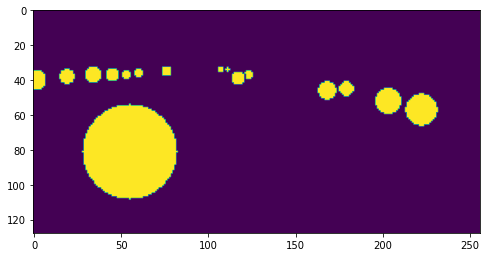

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:16<00:11,  1.16s/it]

theta_x: -0.0611
theta_y: -0.0341
theta_z: 0.0254
phi: 0.0006
gamma: -0.0108
rho: -0.0063


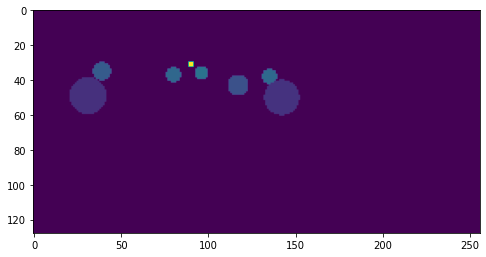

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(140.8750, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(141.2500, device='cuda:0')


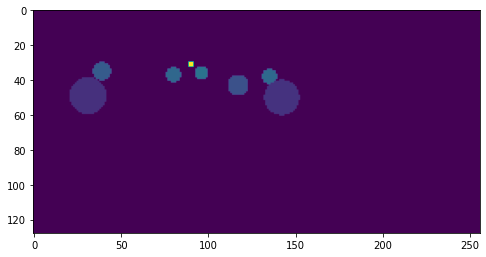

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


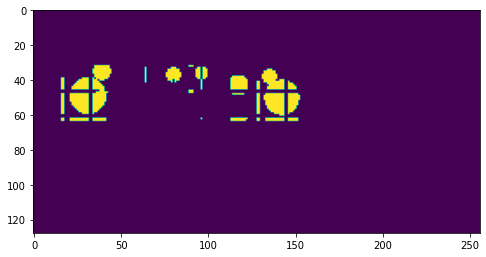

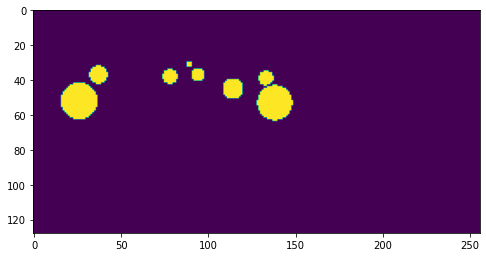

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:17<00:10,  1.16s/it]

theta_x: -0.0607
theta_y: -0.0363
theta_z: 0.0260
phi: 0.0007
gamma: -0.0107
rho: -0.0061


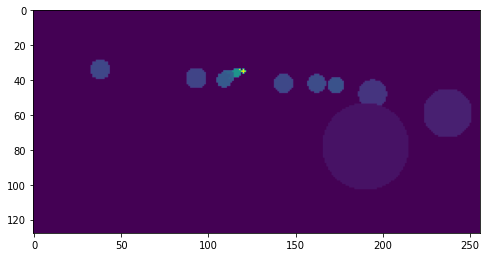

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(170.6785, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(171., device='cuda:0')


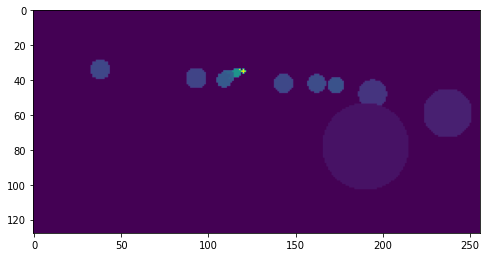

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


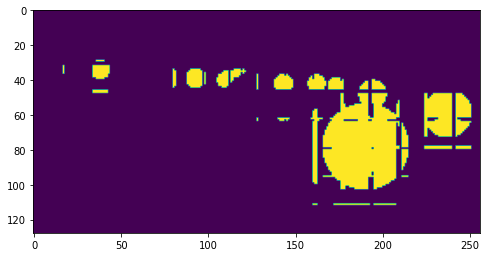

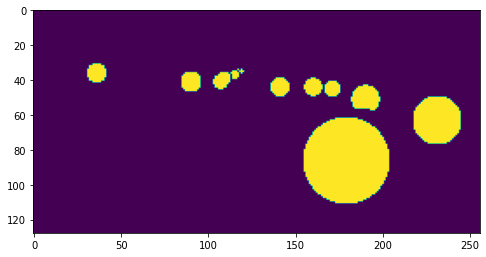

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:18<00:09,  1.15s/it]

theta_x: -0.0625
theta_y: -0.0403
theta_z: 0.0266
phi: 0.0010
gamma: -0.0103
rho: -0.0064


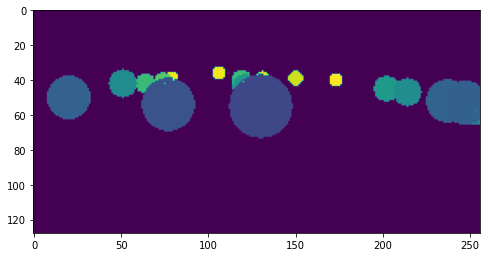

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(53.1789, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(53.1562, device='cuda:0')


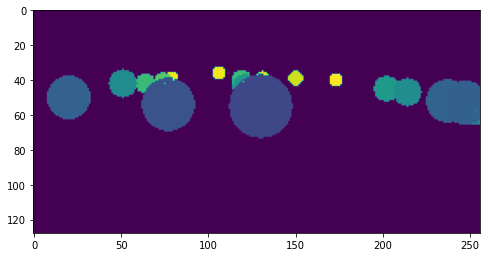

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


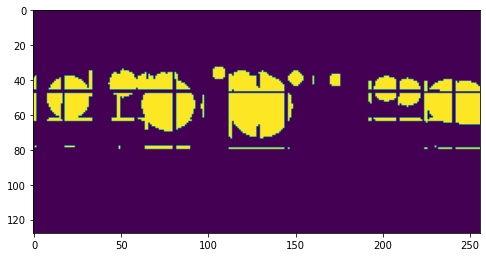

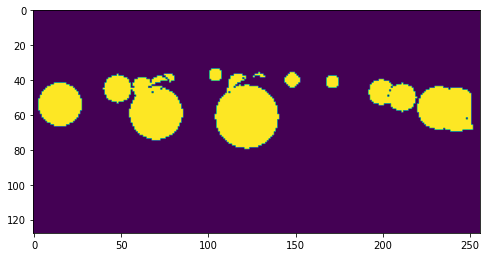

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:19<00:08,  1.15s/it]

theta_x: -0.0613
theta_y: -0.0431
theta_z: 0.0273
phi: 0.0003
gamma: -0.0099
rho: -0.0061


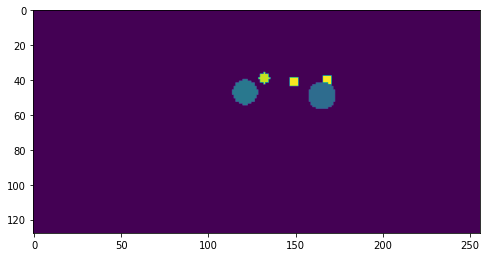

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(73.2593, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(73.2500, device='cuda:0')


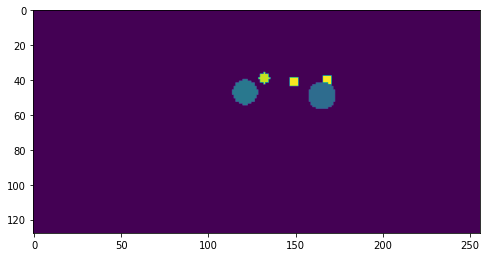

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


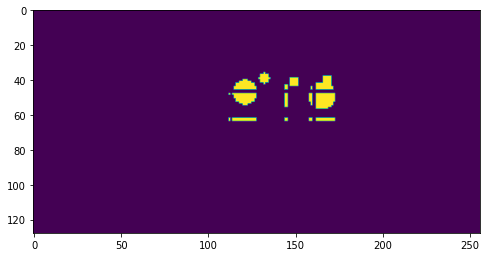

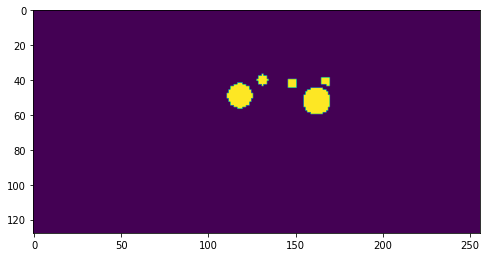

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:20<00:06,  1.14s/it]

theta_x: -0.0670
theta_y: -0.0412
theta_z: 0.0268
phi: 0.0008
gamma: -0.0102
rho: -0.0067


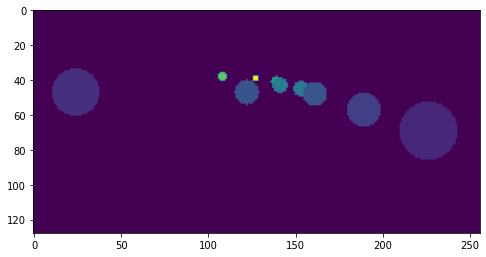

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(113.6898, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(113.8750, device='cuda:0')


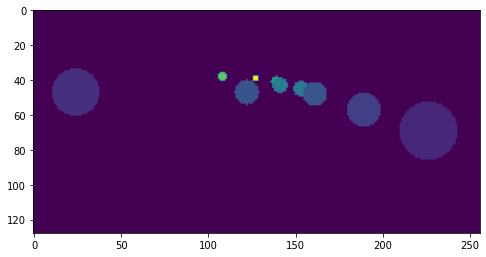

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


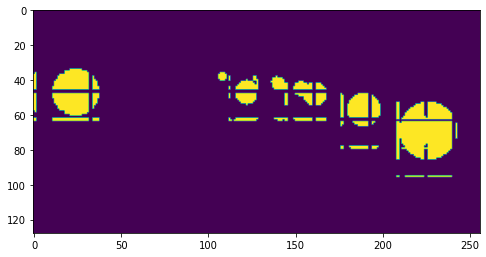

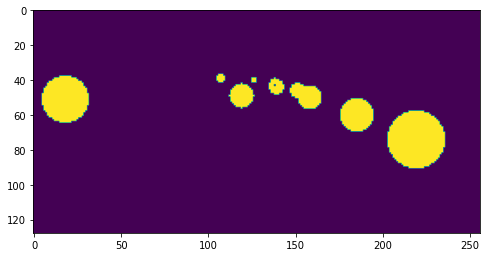

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:21<00:05,  1.16s/it]

theta_x: -0.0668
theta_y: -0.0427
theta_z: 0.0274
phi: 0.0001
gamma: -0.0103
rho: -0.0065


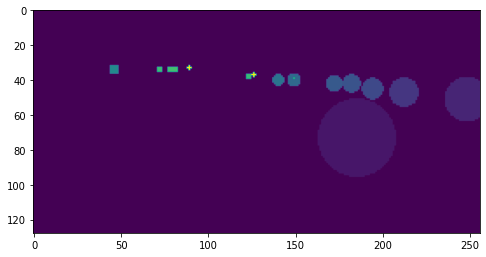

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(154.3152, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(154.7500, device='cuda:0')


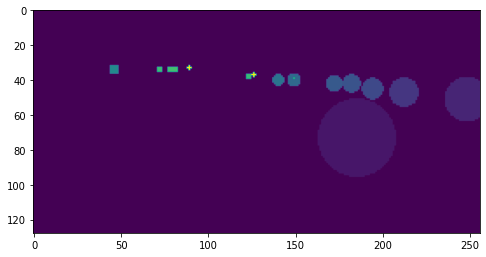

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


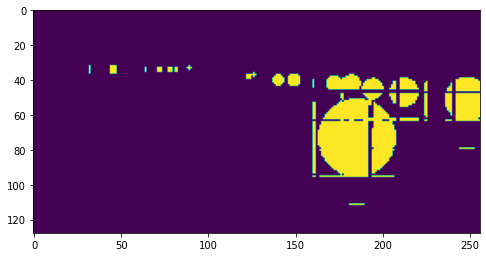

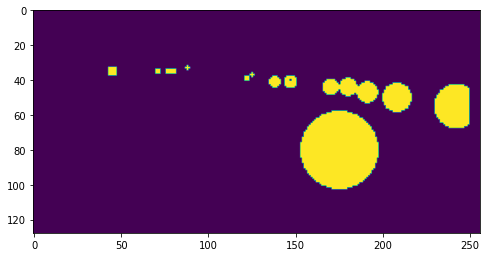

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:23<00:04,  1.16s/it]

theta_x: -0.0666
theta_y: -0.0442
theta_z: 0.0278
phi: -0.0001
gamma: -0.0102
rho: -0.0064


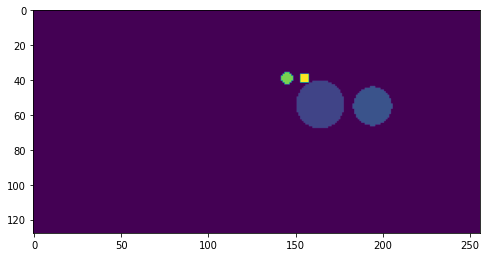

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(73.0951, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(73.1250, device='cuda:0')


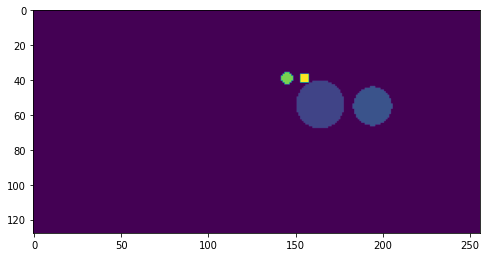

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


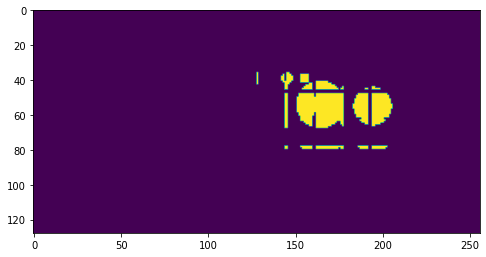

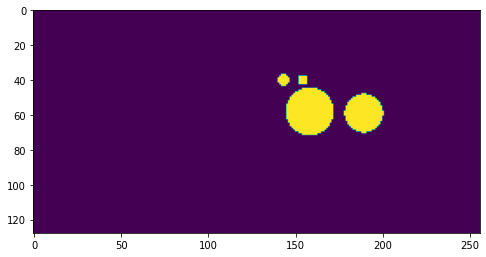

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:24<00:03,  1.17s/it]

theta_x: -0.0671
theta_y: -0.0439
theta_z: 0.0283
phi: 0.0001
gamma: -0.0106
rho: -0.0065


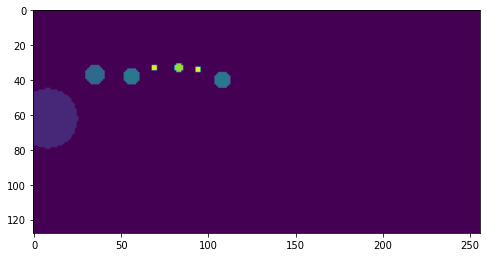

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(108.3291, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(108.6250, device='cuda:0')


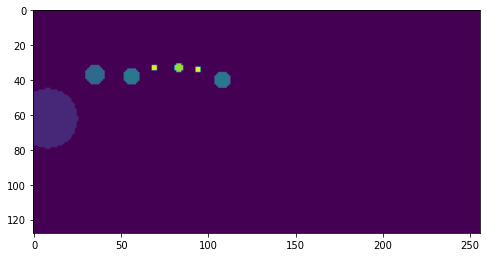

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


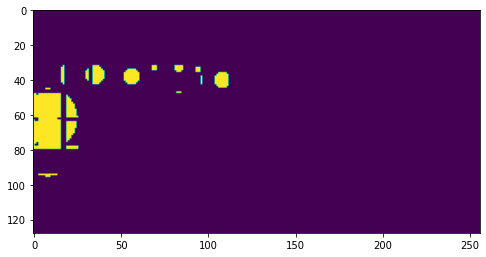

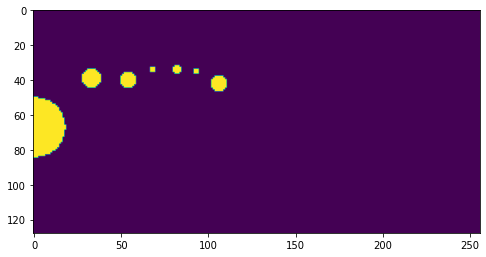

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:25<00:02,  1.18s/it]

theta_x: -0.0676
theta_y: -0.0417
theta_z: 0.0285
phi: 0.0001
gamma: -0.0111
rho: -0.0065


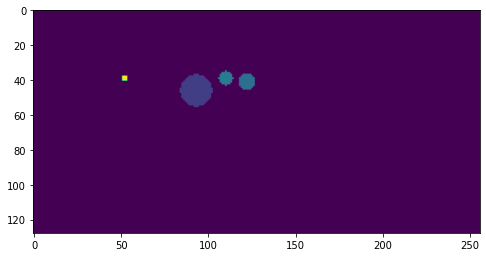

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(123.1909, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(123.7500, device='cuda:0')


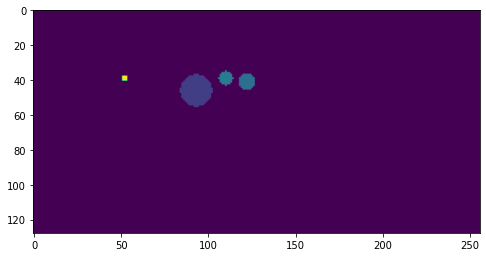

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


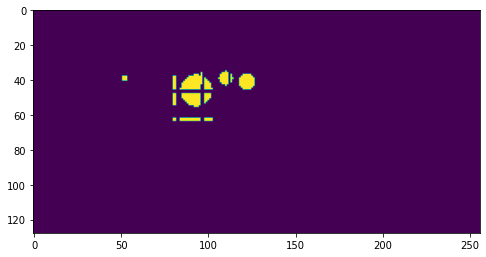

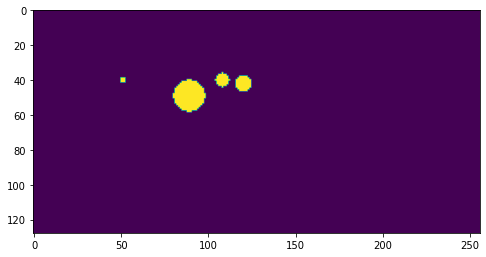

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:26<00:01,  1.23s/it]

theta_x: -0.0665
theta_y: -0.0429
theta_z: 0.0289
phi: -0.0000
gamma: -0.0112
rho: -0.0063


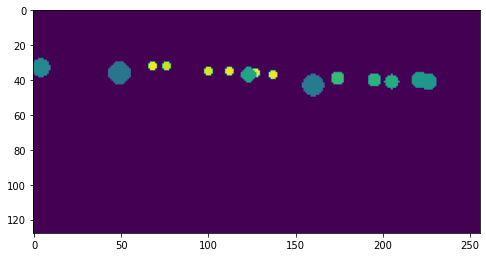

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(83.7500, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(83.8750, device='cuda:0')


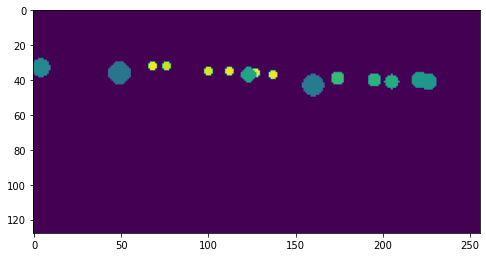

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


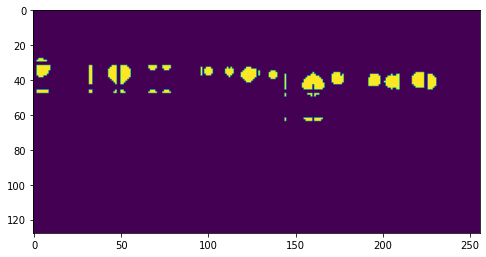

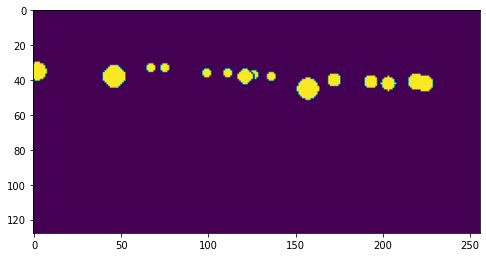

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

theta_x: -0.0688
theta_y: -0.0430
theta_z: 0.0288
phi: -0.0004
gamma: -0.0113
rho: -0.0064
Train Epoch: (4, 2) 	LR: 0.001000	Loss: 1.589674


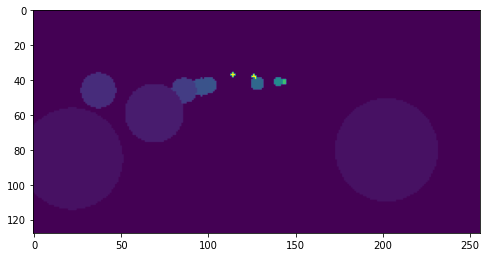

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(161.9494, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(162.2500, device='cuda:0')


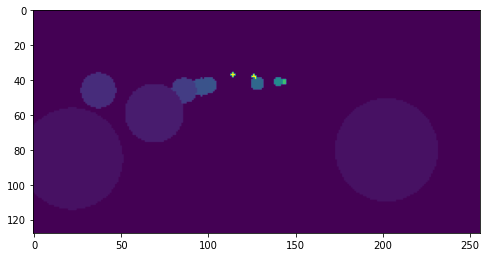

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


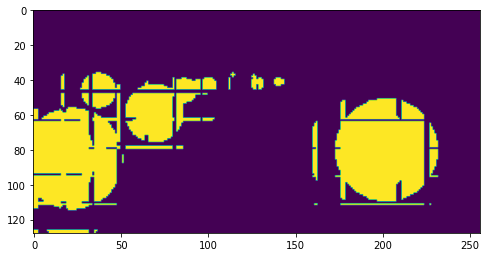

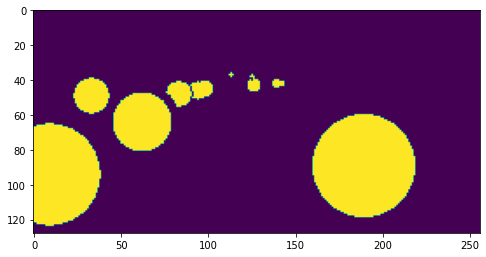

  4%|███▍                                                                               | 1/24 [00:01<00:28,  1.23s/it]

theta_x: -0.0671
theta_y: -0.0450
theta_z: 0.0294
phi: -0.0004
gamma: -0.0111
rho: -0.0060


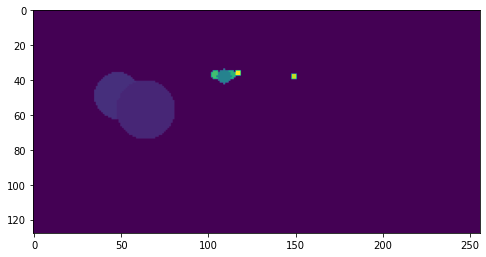

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(115.5957, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(115.8125, device='cuda:0')


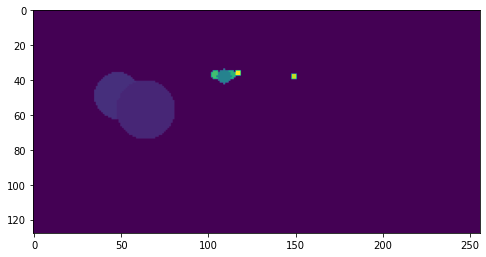

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


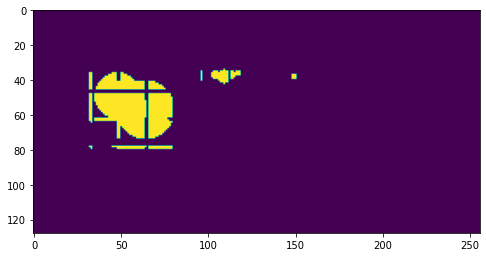

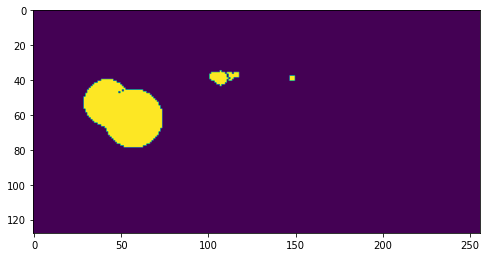

  8%|██████▉                                                                            | 2/24 [00:02<00:26,  1.22s/it]

theta_x: -0.0669
theta_y: -0.0474
theta_z: 0.0301
phi: 0.0000
gamma: -0.0107
rho: -0.0059


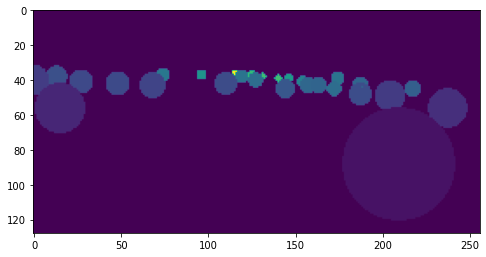

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(136.6130, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(136.8750, device='cuda:0')


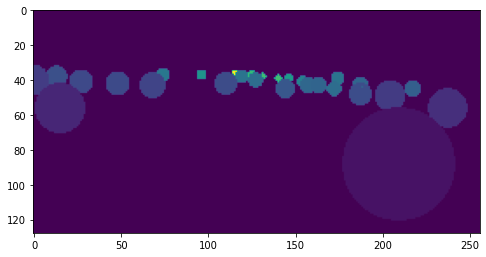

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


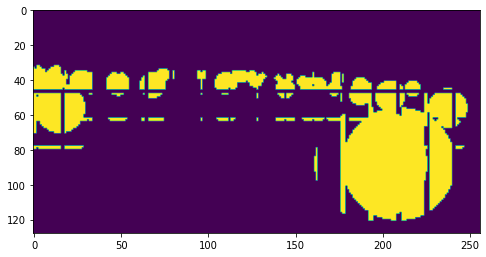

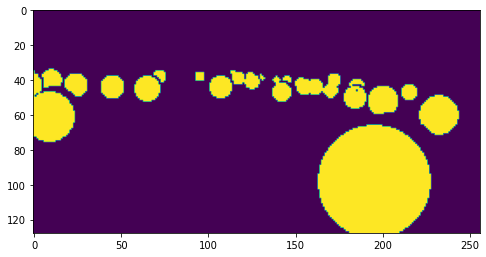

 12%|██████████▍                                                                        | 3/24 [00:03<00:25,  1.20s/it]

theta_x: -0.0662
theta_y: -0.0498
theta_z: 0.0305
phi: -0.0000
gamma: -0.0105
rho: -0.0057


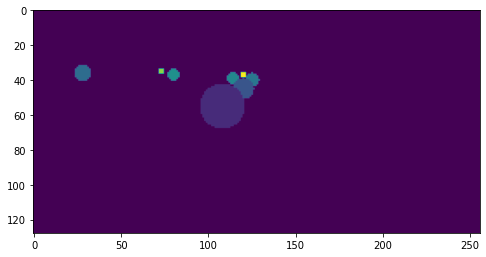

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(129.7625, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(130., device='cuda:0')


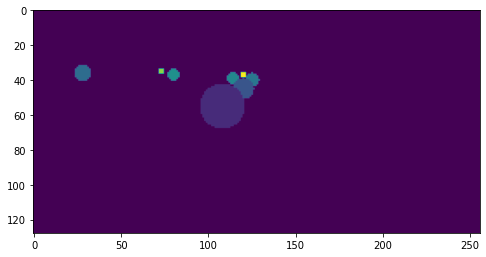

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


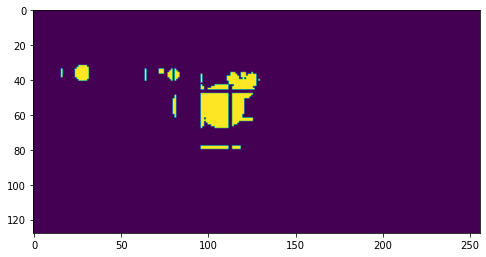

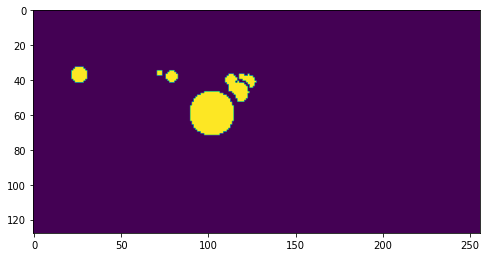

 17%|█████████████▊                                                                     | 4/24 [00:04<00:24,  1.22s/it]

theta_x: -0.0674
theta_y: -0.0500
theta_z: 0.0306
phi: 0.0003
gamma: -0.0106
rho: -0.0059


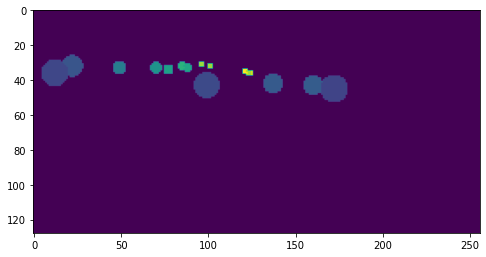

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(125.5980, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(125.8125, device='cuda:0')


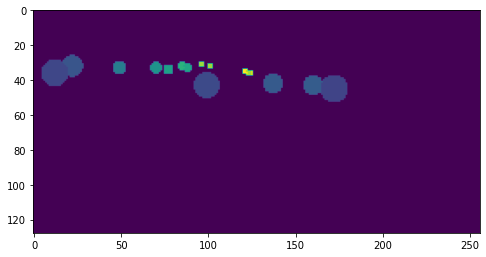

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


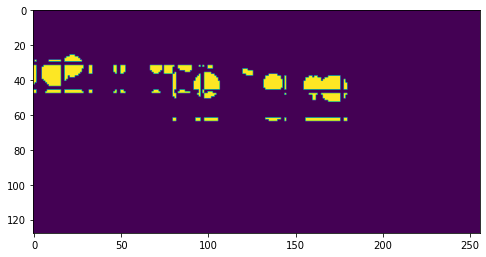

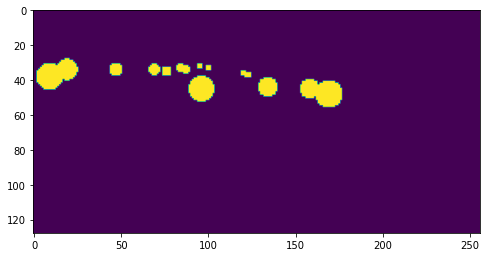

 21%|█████████████████▎                                                                 | 5/24 [00:06<00:22,  1.21s/it]

theta_x: -0.0682
theta_y: -0.0503
theta_z: 0.0308
phi: 0.0003
gamma: -0.0107
rho: -0.0060


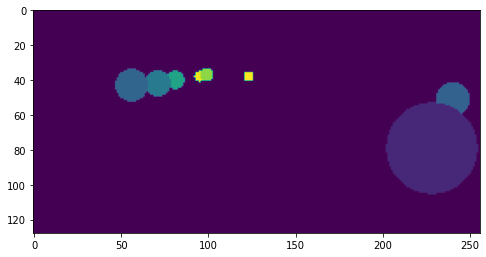

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(69.2676, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(69.3750, device='cuda:0')


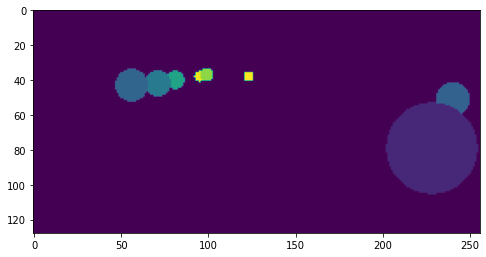

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


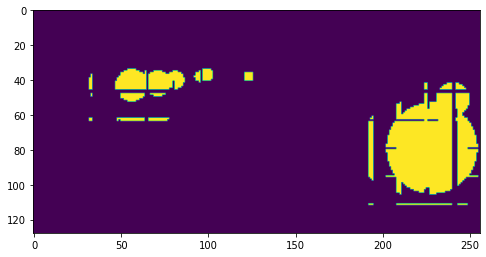

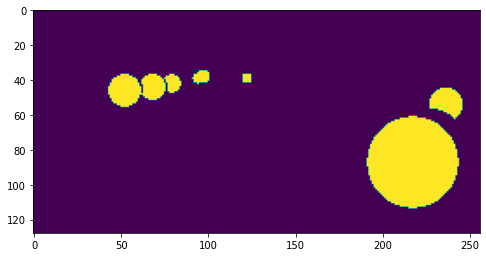

 25%|████████████████████▊                                                              | 6/24 [00:07<00:21,  1.19s/it]

theta_x: -0.0686
theta_y: -0.0499
theta_z: 0.0310
phi: 0.0002
gamma: -0.0110
rho: -0.0060


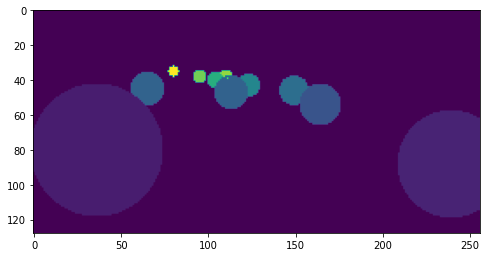

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(67.8104, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(68., device='cuda:0')


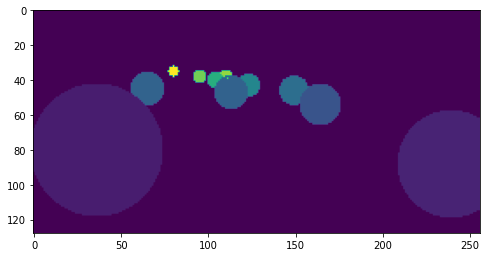

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


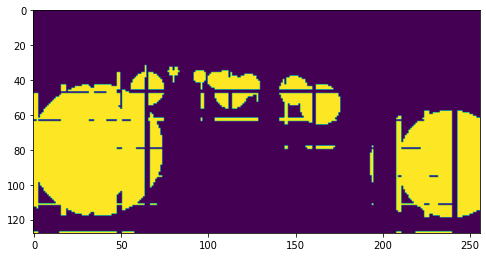

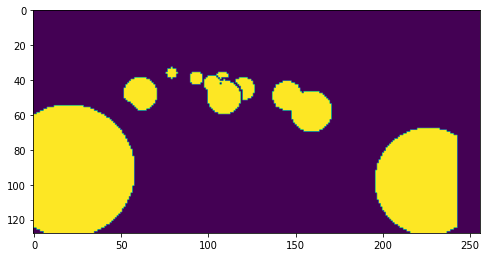

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:20,  1.19s/it]

theta_x: -0.0664
theta_y: -0.0503
theta_z: 0.0313
phi: -0.0005
gamma: -0.0113
rho: -0.0055


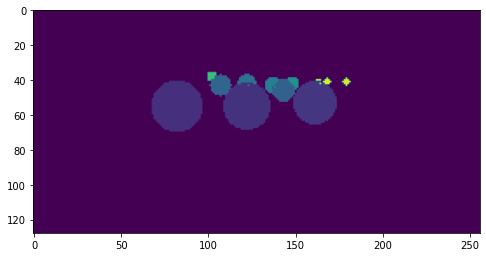

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(105.3501, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(105.4375, device='cuda:0')


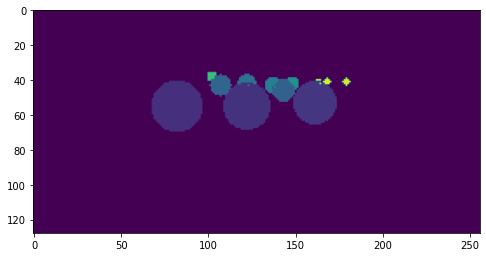

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


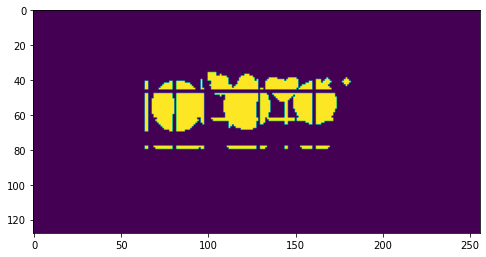

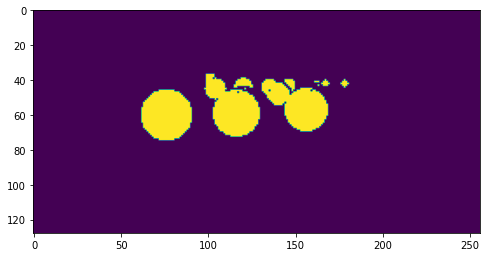

 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:19,  1.20s/it]

theta_x: -0.0664
theta_y: -0.0502
theta_z: 0.0318
phi: -0.0008
gamma: -0.0118
rho: -0.0054


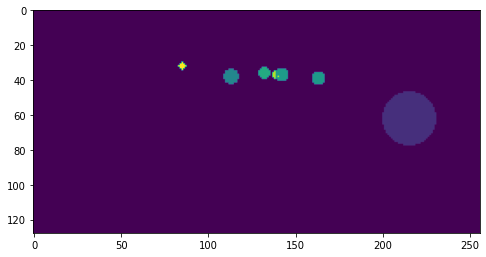

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(101.1626, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(101.4375, device='cuda:0')


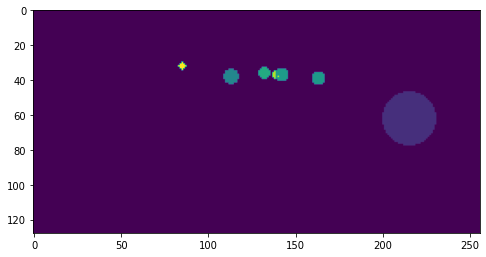

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


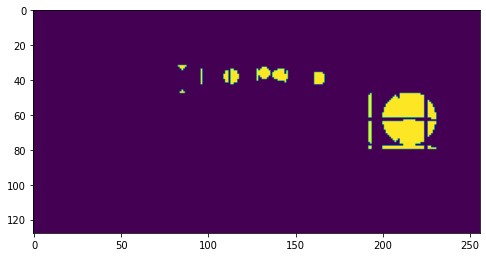

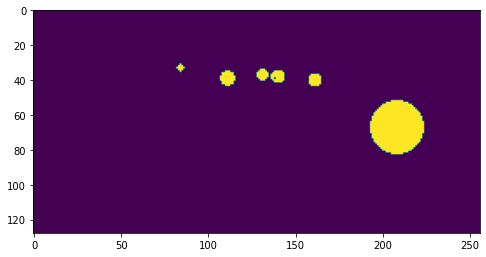

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:18,  1.20s/it]

theta_x: -0.0671
theta_y: -0.0512
theta_z: 0.0322
phi: -0.0004
gamma: -0.0116
rho: -0.0055


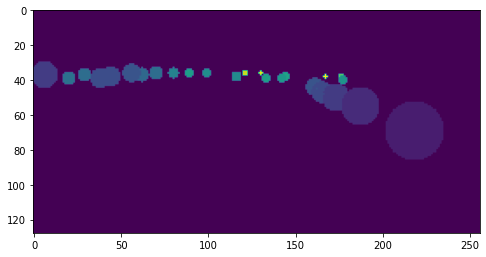

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(151.9082, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(152., device='cuda:0')


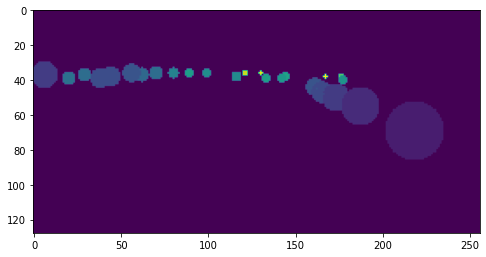

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


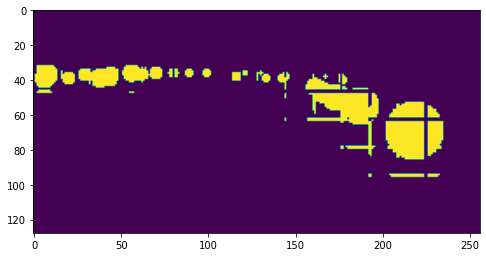

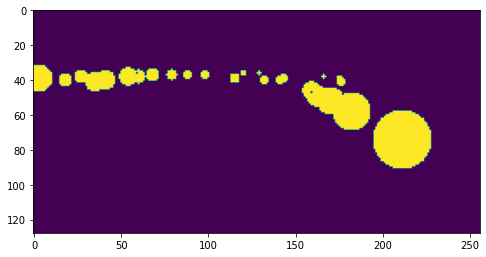

 42%|██████████████████████████████████▏                                               | 10/24 [00:12<00:16,  1.21s/it]

theta_x: -0.0684
theta_y: -0.0503
theta_z: 0.0325
phi: -0.0002
gamma: -0.0119
rho: -0.0058


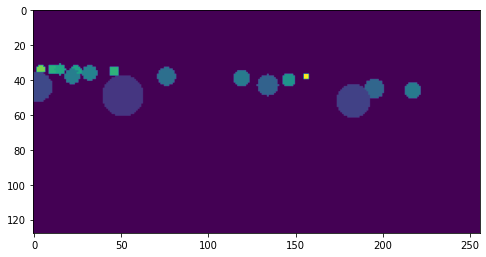

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(110.2807, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(110.3750, device='cuda:0')


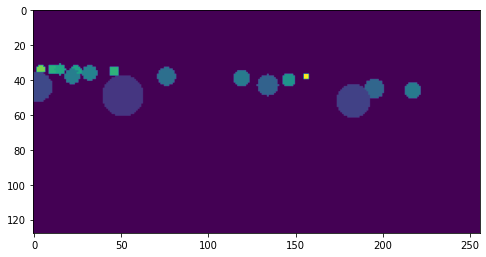

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


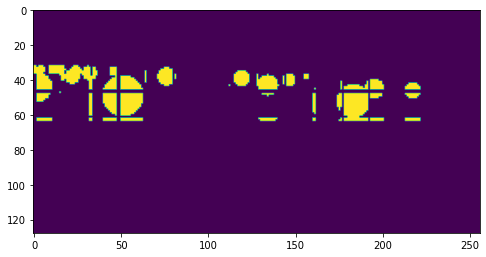

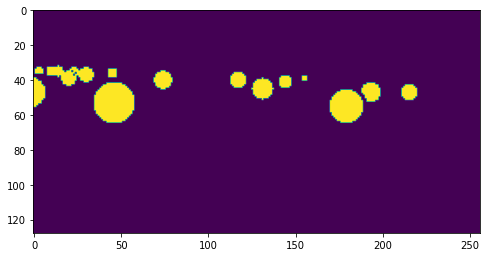

 46%|█████████████████████████████████████▌                                            | 11/24 [00:13<00:15,  1.22s/it]

theta_x: -0.0679
theta_y: -0.0514
theta_z: 0.0333
phi: -0.0004
gamma: -0.0118
rho: -0.0056


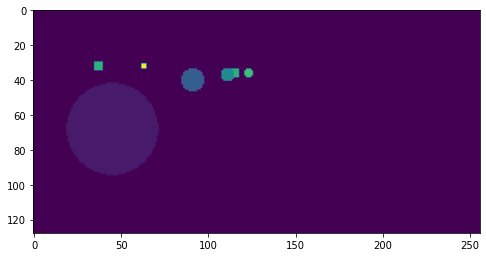

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(108.1971, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(108.5625, device='cuda:0')


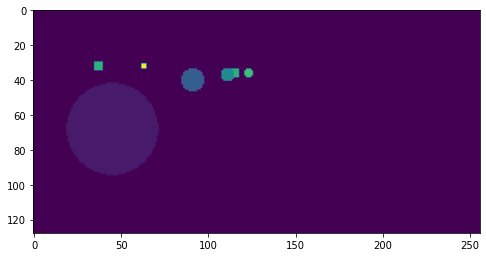

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


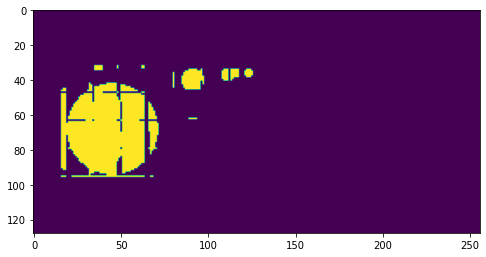

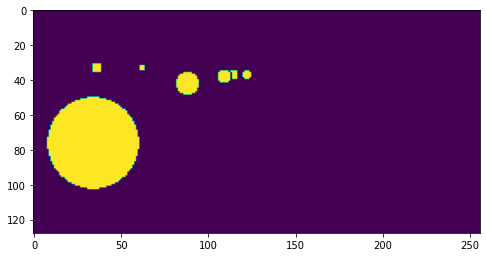

 50%|█████████████████████████████████████████                                         | 12/24 [00:14<00:14,  1.23s/it]

theta_x: -0.0680
theta_y: -0.0546
theta_z: 0.0338
phi: -0.0004
gamma: -0.0112
rho: -0.0055


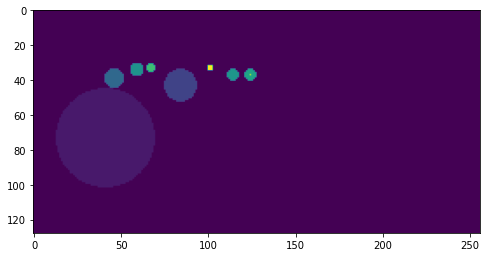

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(110.1907, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(110.4375, device='cuda:0')


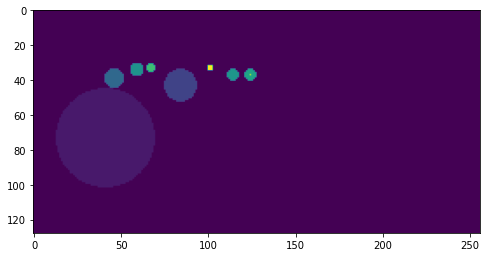

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


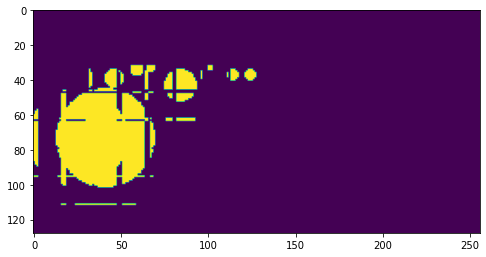

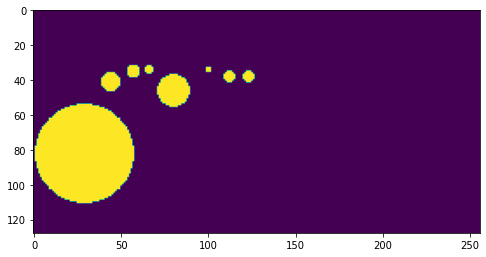

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:15<00:13,  1.22s/it]

theta_x: -0.0674
theta_y: -0.0550
theta_z: 0.0343
phi: -0.0006
gamma: -0.0114
rho: -0.0053


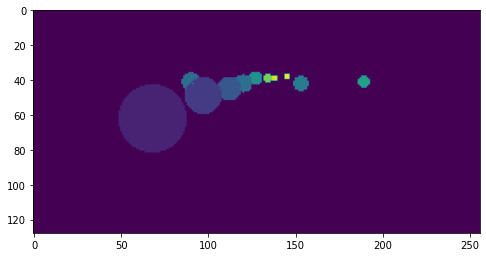

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(111.0558, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(111.1875, device='cuda:0')


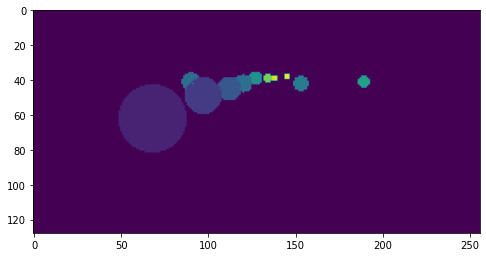

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


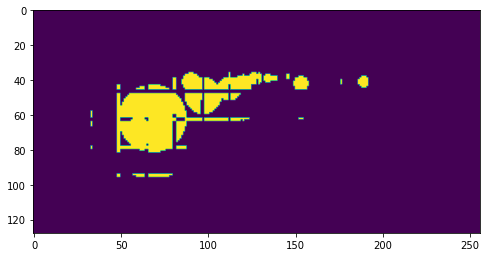

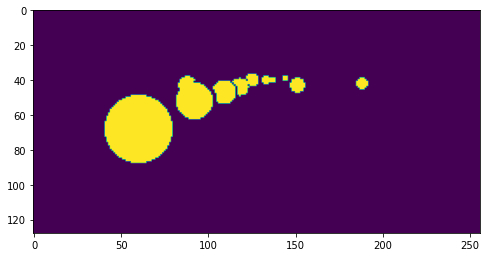

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:16<00:12,  1.21s/it]

theta_x: -0.0682
theta_y: -0.0530
theta_z: 0.0347
phi: 0.0002
gamma: -0.0118
rho: -0.0057


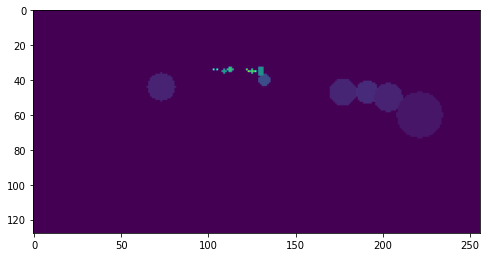

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(258.7723, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(259.2500, device='cuda:0')


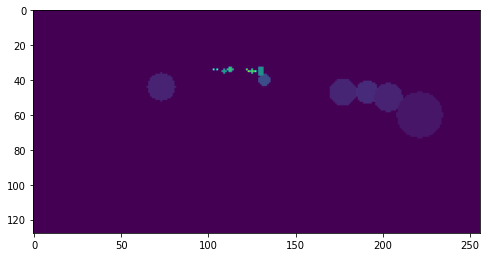

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


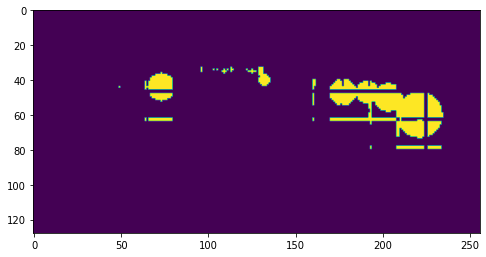

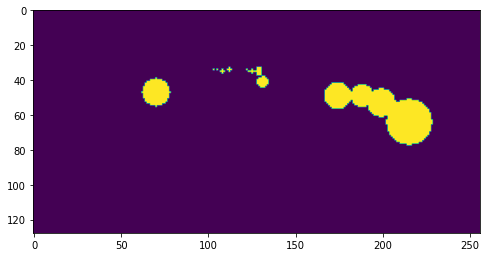

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:18<00:11,  1.25s/it]

theta_x: -0.0700
theta_y: -0.0541
theta_z: 0.0345
phi: 0.0000
gamma: -0.0116
rho: -0.0058


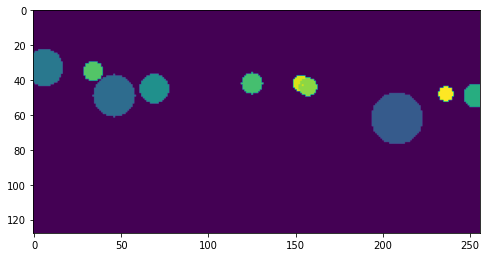

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(48.9093, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(48.8125, device='cuda:0')


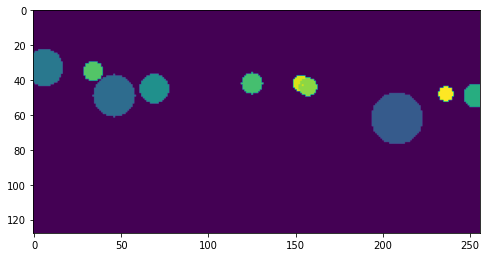

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


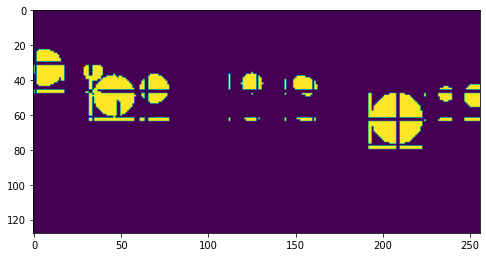

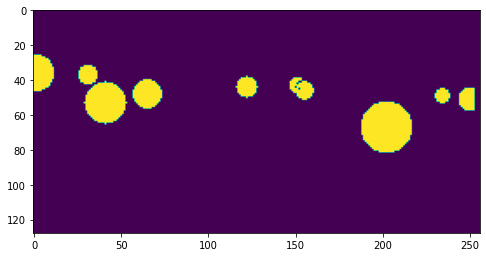

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:19<00:09,  1.24s/it]

theta_x: -0.0712
theta_y: -0.0549
theta_z: 0.0351
phi: 0.0006
gamma: -0.0118
rho: -0.0060


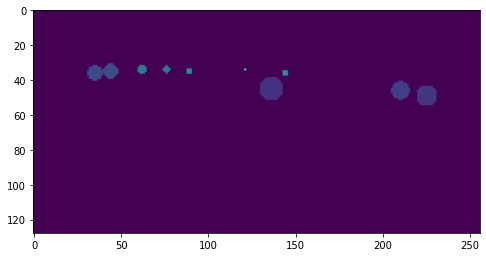

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(215.9382, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(216.3750, device='cuda:0')


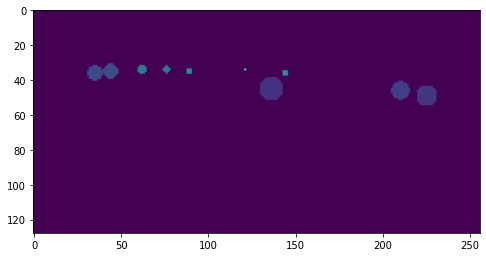

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


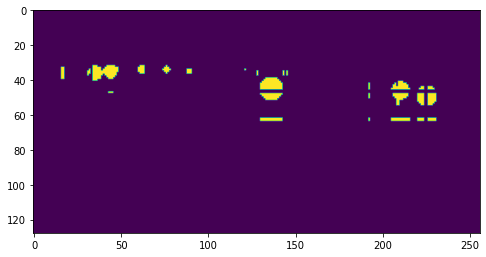

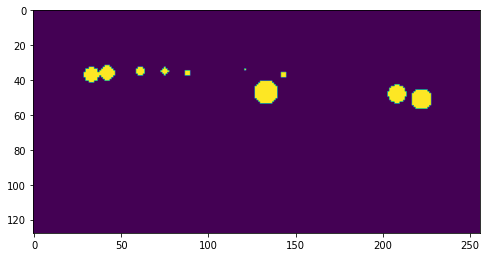

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:20<00:08,  1.24s/it]

theta_x: -0.0716
theta_y: -0.0547
theta_z: 0.0352
phi: 0.0006
gamma: -0.0119
rho: -0.0059


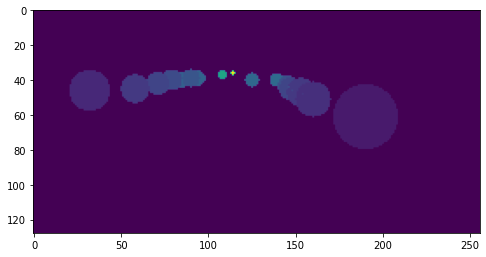

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(154.2828, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(154.6250, device='cuda:0')


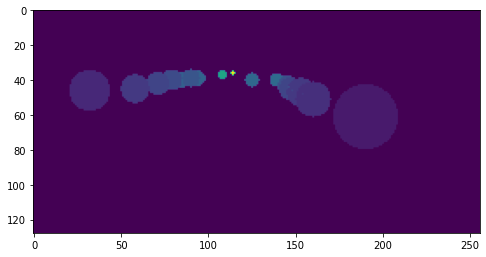

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


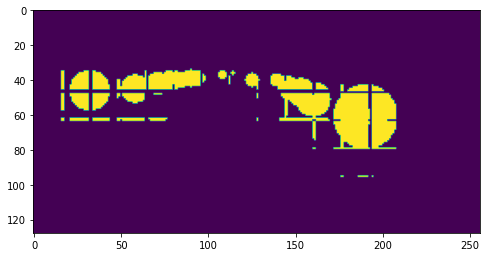

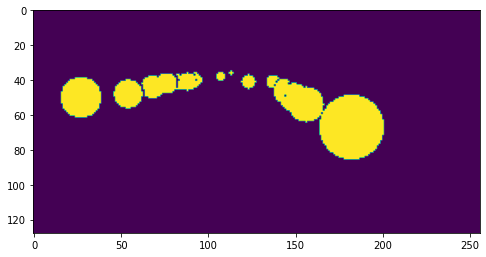

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:21<00:07,  1.21s/it]

theta_x: -0.0708
theta_y: -0.0558
theta_z: 0.0356
phi: 0.0002
gamma: -0.0118
rho: -0.0057


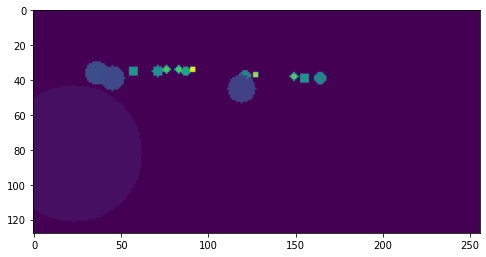

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(133.2308, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(133.6250, device='cuda:0')


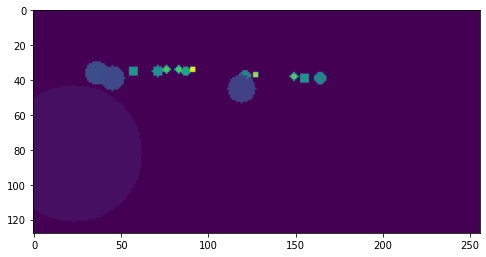

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


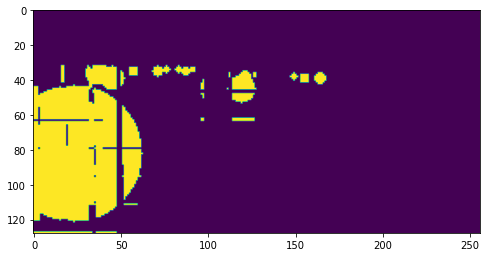

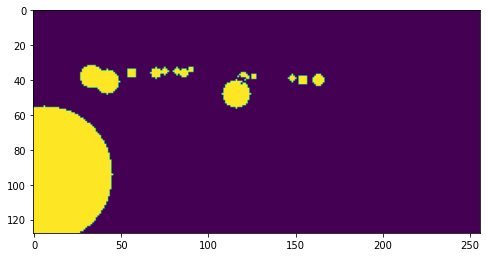

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:23<00:06,  1.22s/it]

theta_x: -0.0718
theta_y: -0.0532
theta_z: 0.0358
phi: 0.0006
gamma: -0.0126
rho: -0.0059


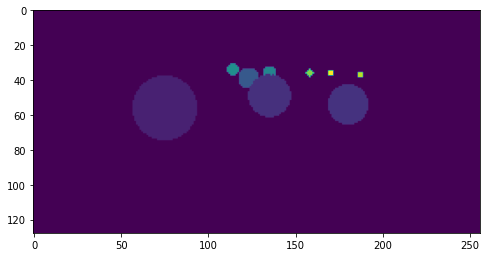

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(124.8394, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(124.8750, device='cuda:0')


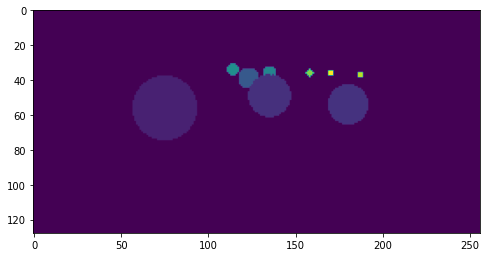

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


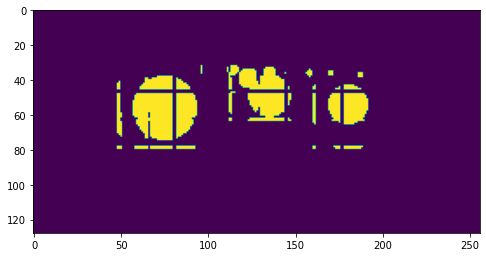

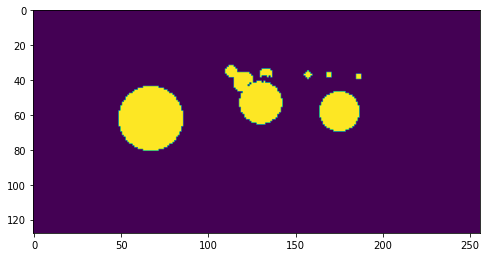

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:24<00:04,  1.21s/it]

theta_x: -0.0771
theta_y: -0.0524
theta_z: 0.0353
phi: 0.0007
gamma: -0.0127
rho: -0.0064


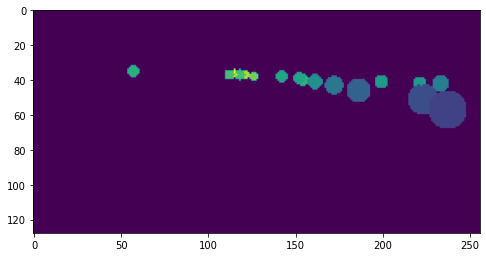

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(97.7326, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(97.9375, device='cuda:0')


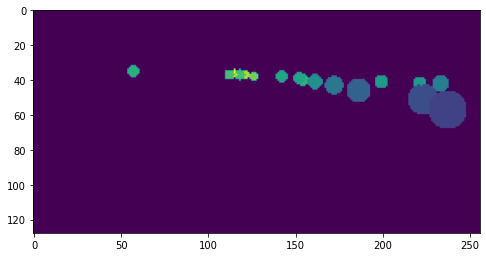

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


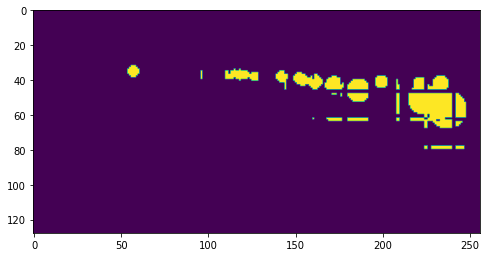

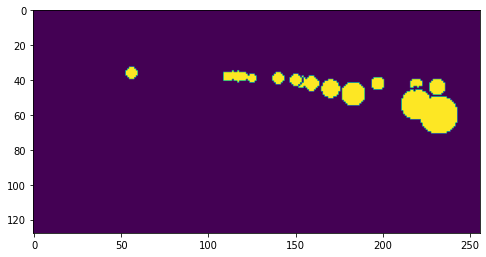

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:25<00:03,  1.23s/it]

theta_x: -0.0766
theta_y: -0.0556
theta_z: 0.0361
phi: 0.0008
gamma: -0.0122
rho: -0.0063


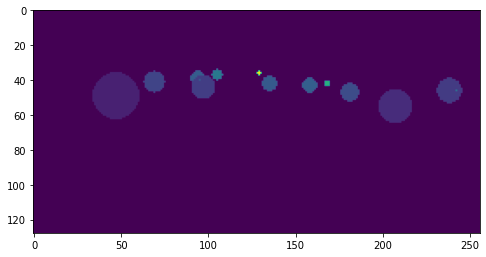

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(166.0786, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(166.3750, device='cuda:0')


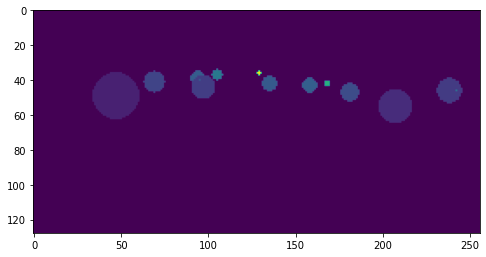

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


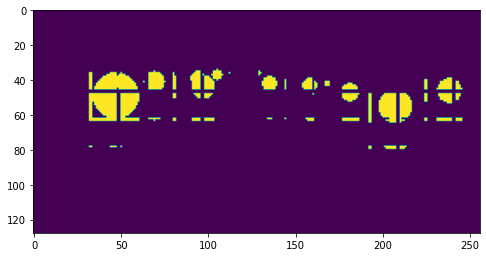

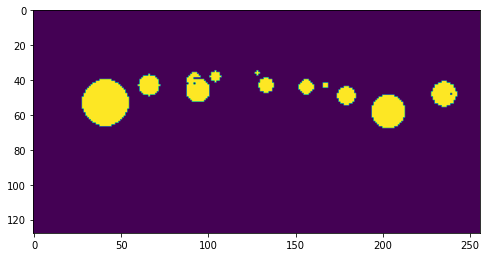

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:26<00:02,  1.24s/it]

theta_x: -0.0763
theta_y: -0.0563
theta_z: 0.0366
phi: 0.0004
gamma: -0.0121
rho: -0.0062


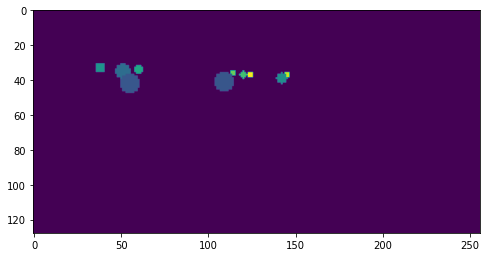

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(134.7339, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(135., device='cuda:0')


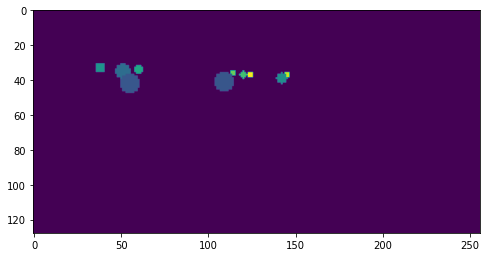

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


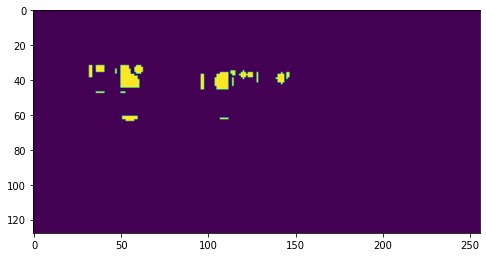

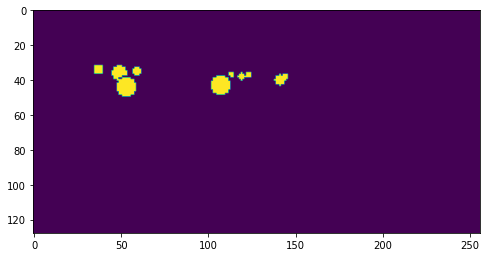

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:28<00:01,  1.25s/it]

theta_x: -0.0774
theta_y: -0.0558
theta_z: 0.0370
phi: 0.0003
gamma: -0.0124
rho: -0.0064


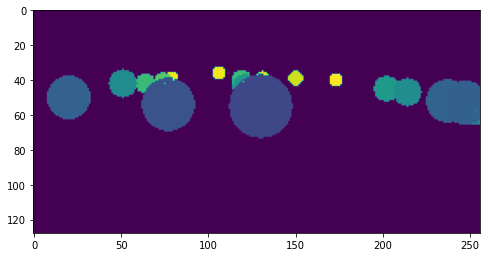

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(53.1633, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(53.1562, device='cuda:0')


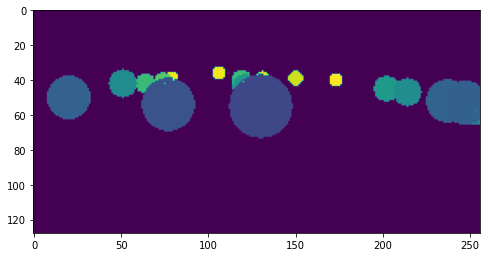

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


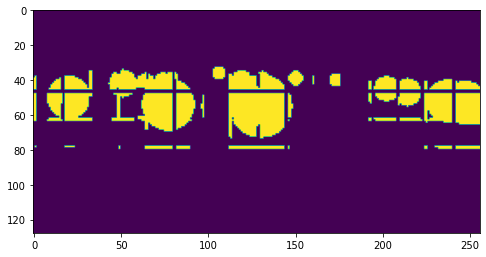

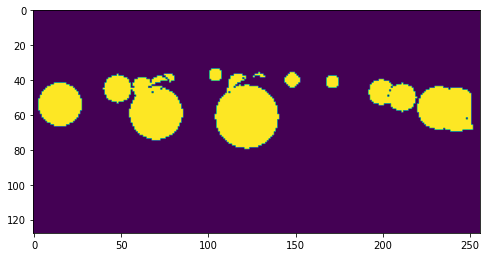

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

theta_x: -0.0758
theta_y: -0.0544
theta_z: 0.0373
phi: 0.0002
gamma: -0.0126
rho: -0.0062
Train Epoch: (4, 3) 	LR: 0.001000	Loss: 1.631793


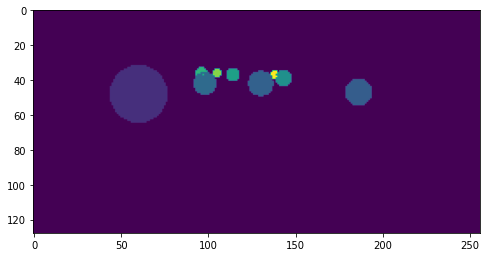

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(92.3180, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(92.4375, device='cuda:0')


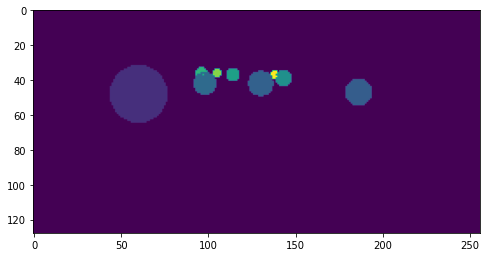

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


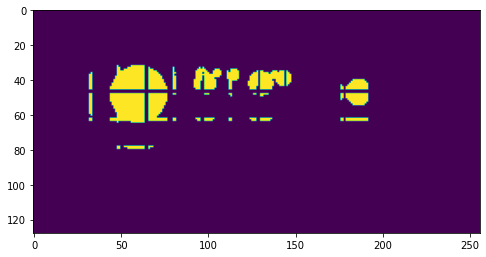

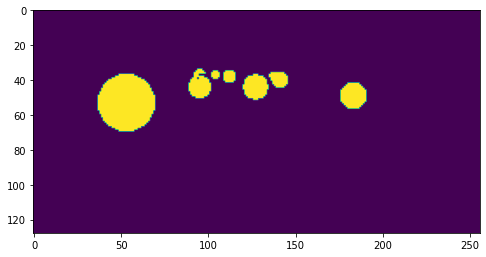

  4%|███▍                                                                               | 1/24 [00:01<00:28,  1.22s/it]

theta_x: -0.0766
theta_y: -0.0565
theta_z: 0.0382
phi: -0.0001
gamma: -0.0124
rho: -0.0061


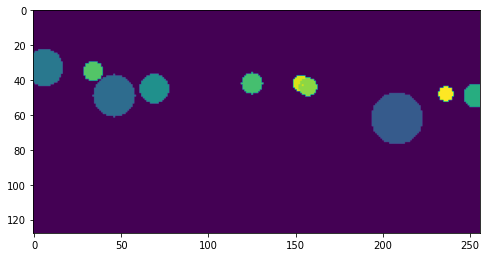

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(48.9025, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(48.8125, device='cuda:0')


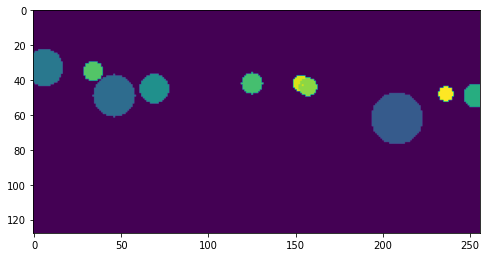

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


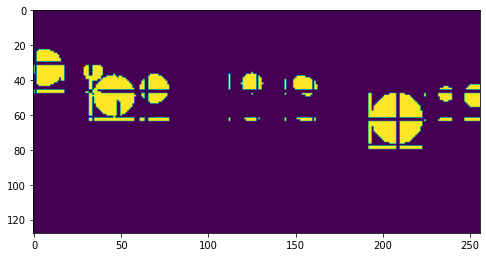

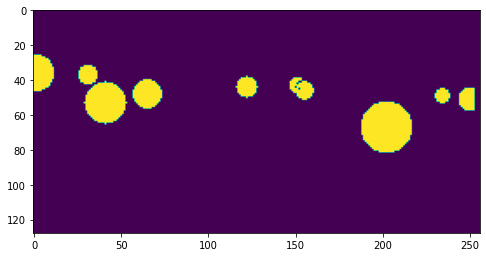

  8%|██████▉                                                                            | 2/24 [00:02<00:26,  1.20s/it]

theta_x: -0.0748
theta_y: -0.0587
theta_z: 0.0388
phi: -0.0004
gamma: -0.0121
rho: -0.0057


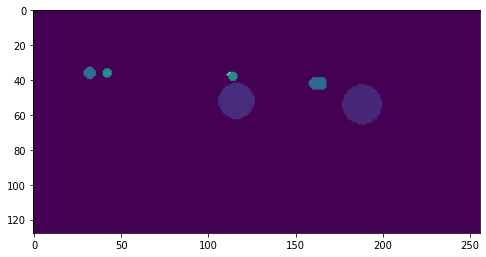

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(160.8596, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(161.2500, device='cuda:0')


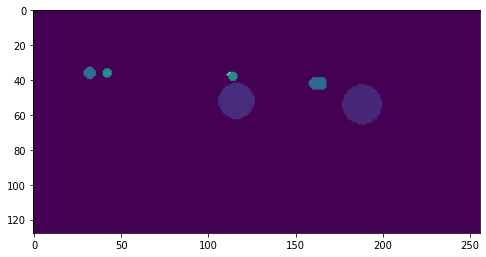

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


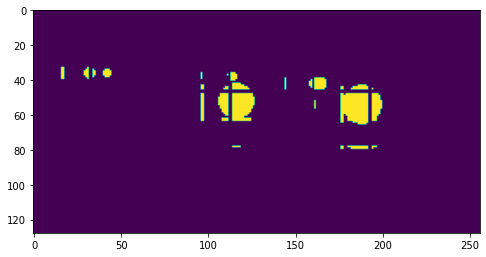

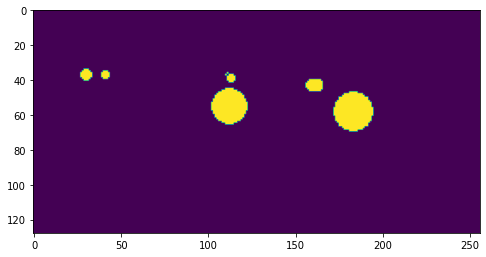

 12%|██████████▍                                                                        | 3/24 [00:03<00:25,  1.19s/it]

theta_x: -0.0802
theta_y: -0.0585
theta_z: 0.0381
phi: -0.0001
gamma: -0.0121
rho: -0.0062


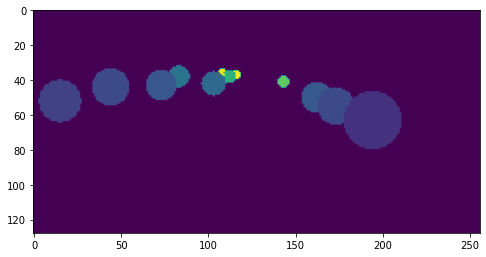

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(86.3906, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(86.5625, device='cuda:0')


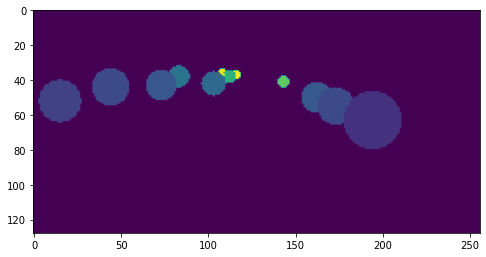

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


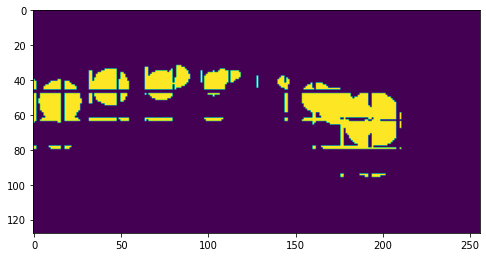

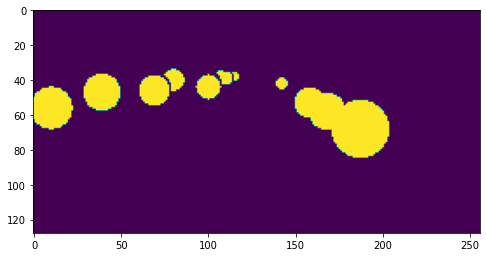

 17%|█████████████▊                                                                     | 4/24 [00:04<00:23,  1.19s/it]

theta_x: -0.0787
theta_y: -0.0590
theta_z: 0.0385
phi: -0.0004
gamma: -0.0123
rho: -0.0059


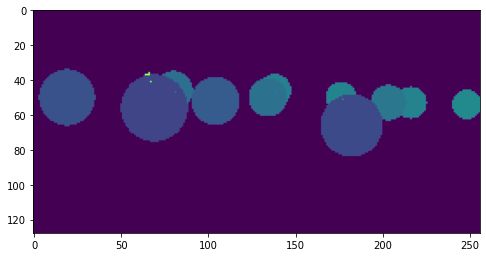

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(51.4182, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(51.5938, device='cuda:0')


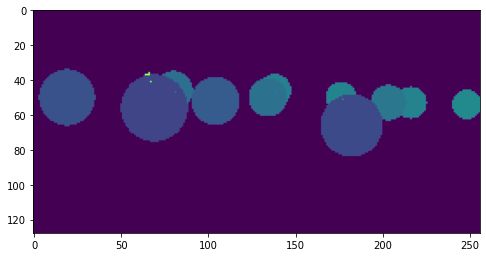

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


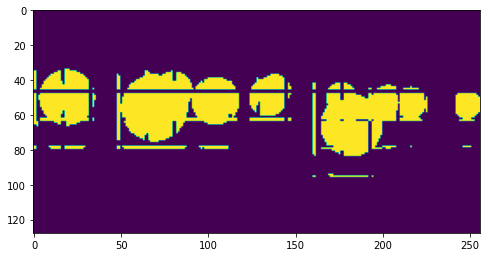

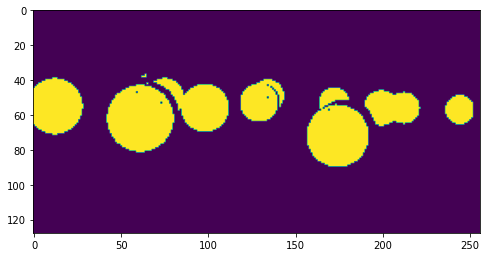

 21%|█████████████████▎                                                                 | 5/24 [00:05<00:22,  1.19s/it]

theta_x: -0.0782
theta_y: -0.0598
theta_z: 0.0391
phi: -0.0005
gamma: -0.0123
rho: -0.0057


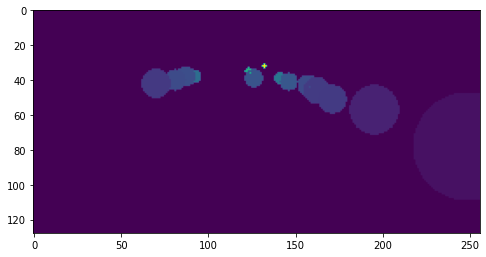

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(151.9026, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(152.1250, device='cuda:0')


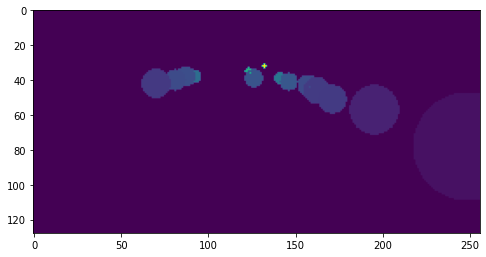

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


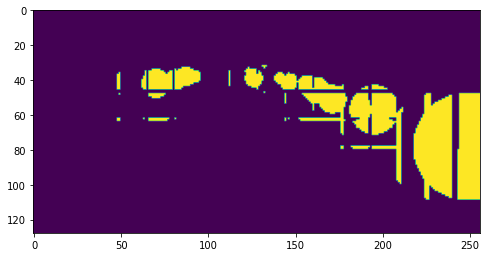

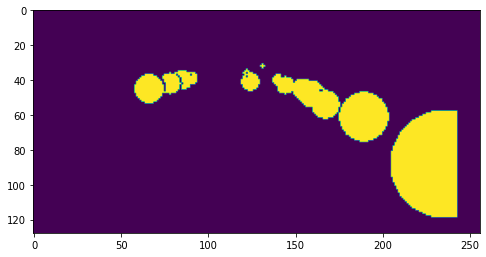

 25%|████████████████████▊                                                              | 6/24 [00:07<00:21,  1.18s/it]

theta_x: -0.0778
theta_y: -0.0600
theta_z: 0.0396
phi: -0.0005
gamma: -0.0124
rho: -0.0056


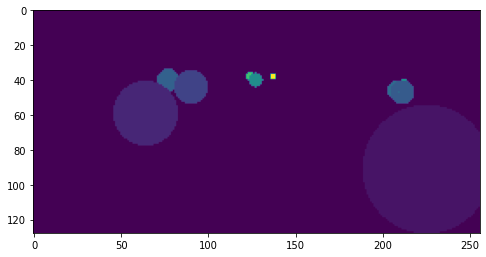

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(104.7882, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(104.9375, device='cuda:0')


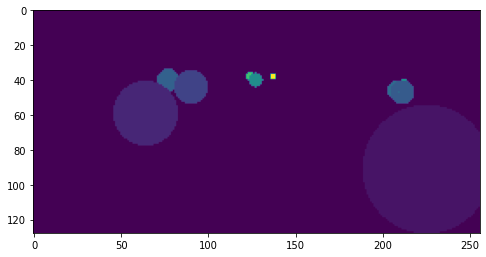

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


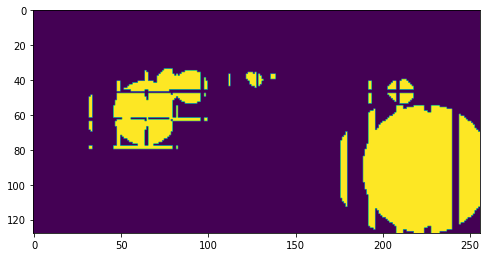

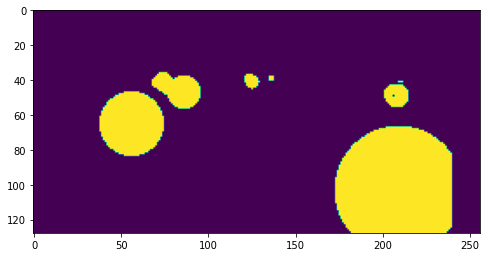

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:20,  1.18s/it]

theta_x: -0.0795
theta_y: -0.0606
theta_z: 0.0397
phi: -0.0000
gamma: -0.0120
rho: -0.0056


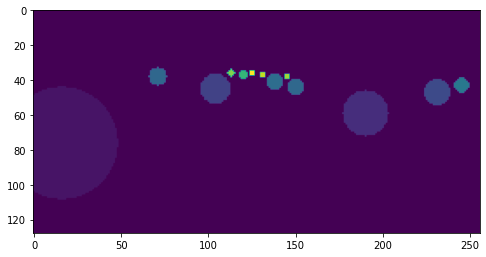

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(122.6543, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(122.8750, device='cuda:0')


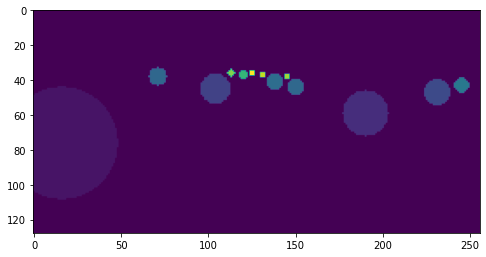

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


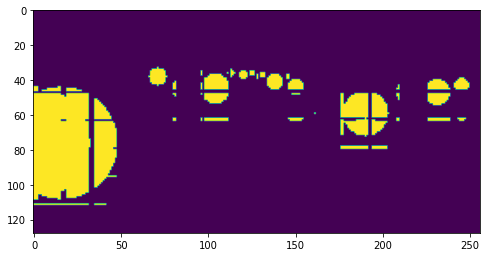

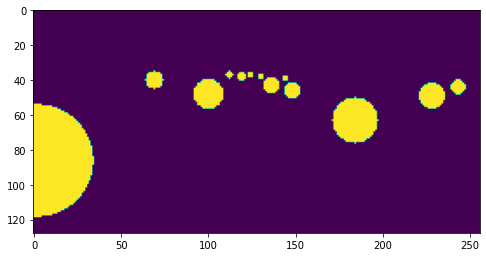

 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:19,  1.20s/it]

theta_x: -0.0777
theta_y: -0.0593
theta_z: 0.0402
phi: -0.0003
gamma: -0.0123
rho: -0.0053


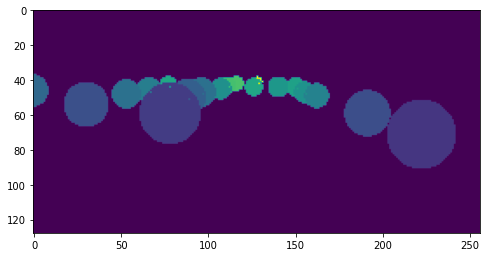

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(65.7659, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(65.8750, device='cuda:0')


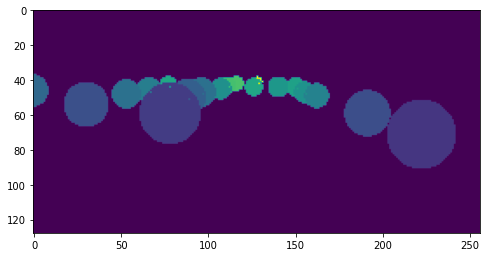

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


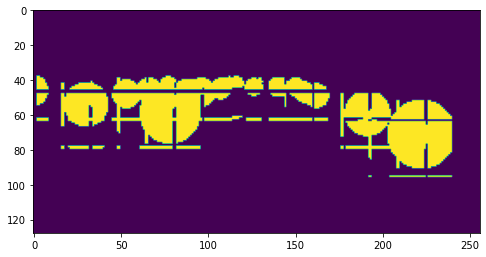

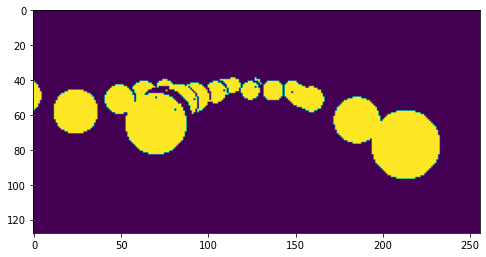

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:17,  1.20s/it]

theta_x: -0.0775
theta_y: -0.0578
theta_z: 0.0404
phi: -0.0007
gamma: -0.0125
rho: -0.0051


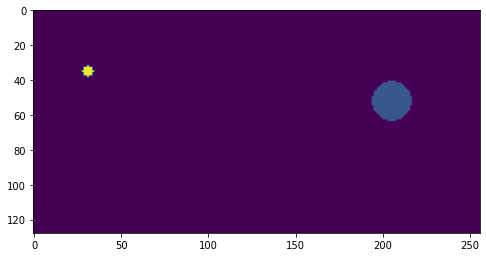

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(67.0831, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(67.3750, device='cuda:0')


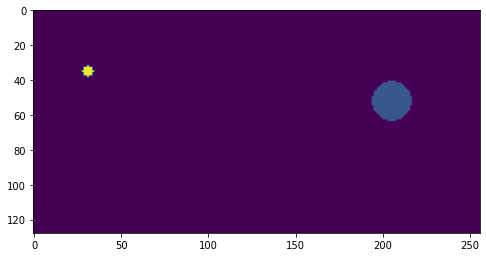

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


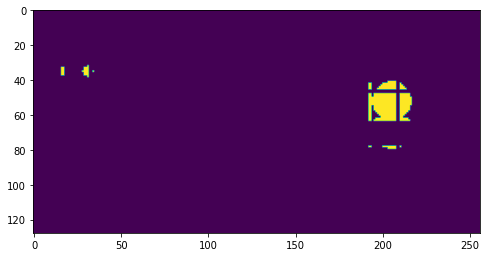

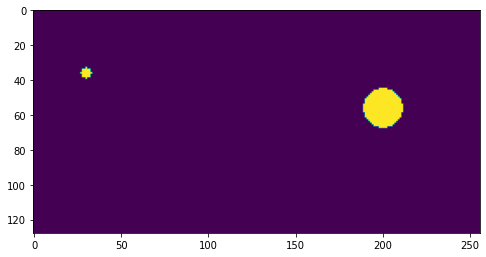

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:16,  1.18s/it]

theta_x: -0.0792
theta_y: -0.0582
theta_z: 0.0406
phi: -0.0003
gamma: -0.0127
rho: -0.0053


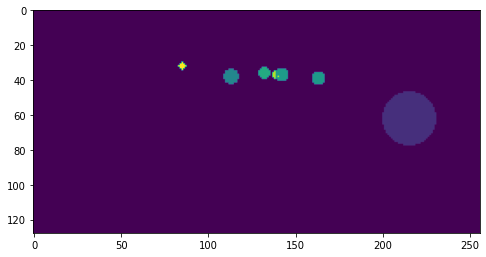

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(101.1566, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(101.4375, device='cuda:0')


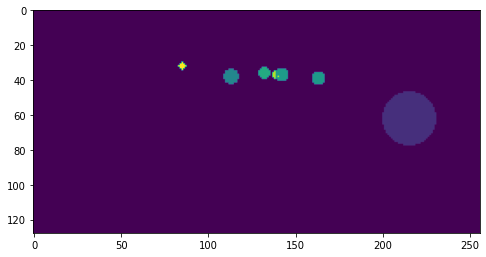

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


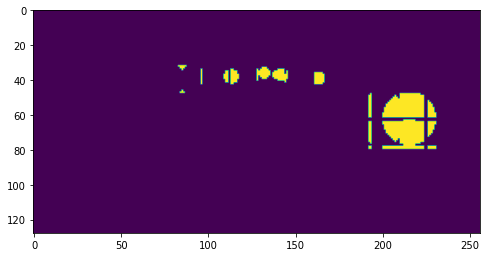

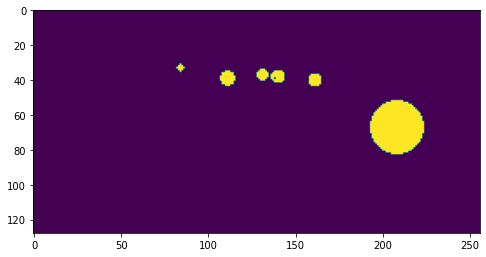

 46%|█████████████████████████████████████▌                                            | 11/24 [00:13<00:15,  1.18s/it]

theta_x: -0.0799
theta_y: -0.0593
theta_z: 0.0411
phi: -0.0004
gamma: -0.0126
rho: -0.0055


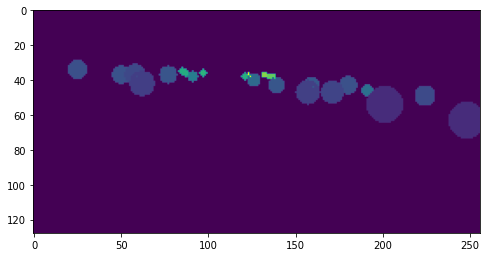

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(156.3031, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(156.6250, device='cuda:0')


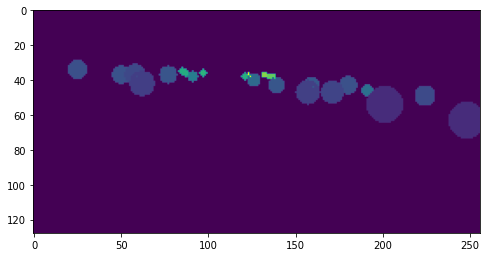

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


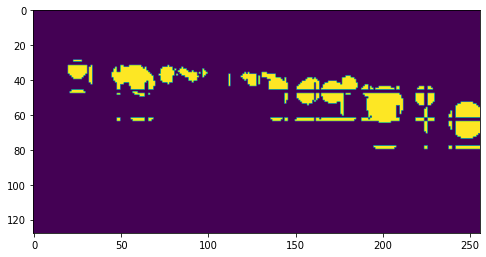

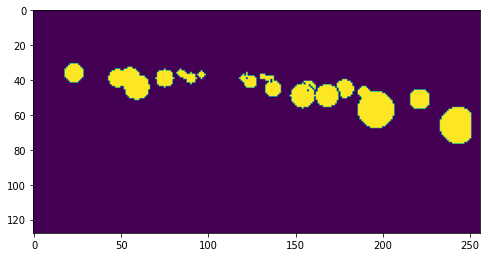

 50%|█████████████████████████████████████████                                         | 12/24 [00:14<00:14,  1.19s/it]

theta_x: -0.0817
theta_y: -0.0605
theta_z: 0.0416
phi: 0.0003
gamma: -0.0125
rho: -0.0059


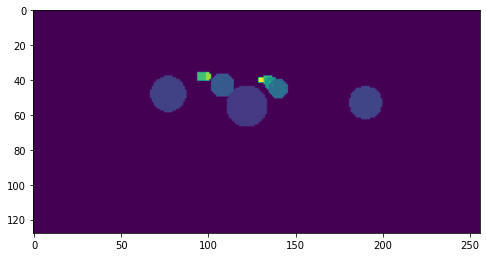

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(105.1793, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(105.3750, device='cuda:0')


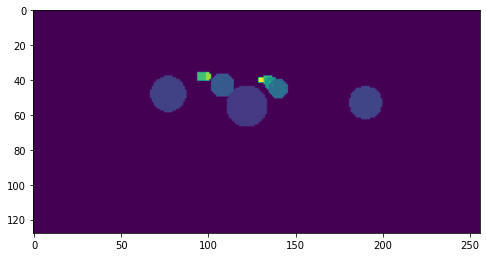

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


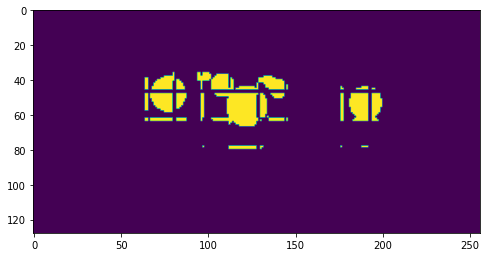

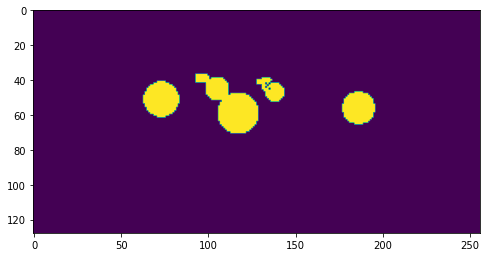

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:15<00:13,  1.18s/it]

theta_x: -0.0804
theta_y: -0.0593
theta_z: 0.0419
phi: -0.0000
gamma: -0.0126
rho: -0.0057


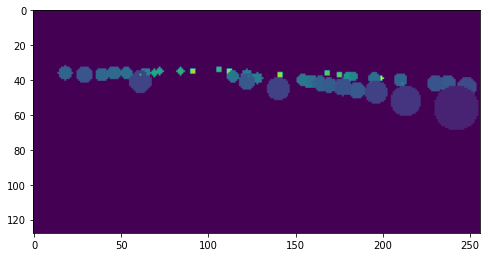

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(160.9170, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(160.8750, device='cuda:0')


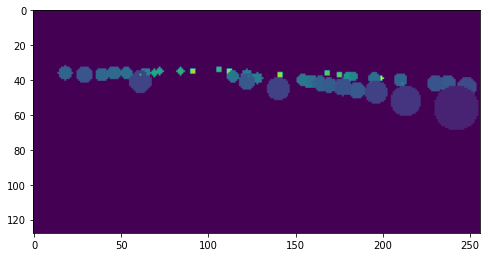

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


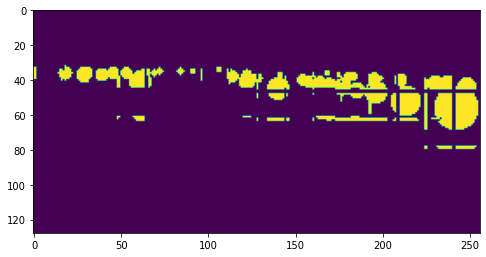

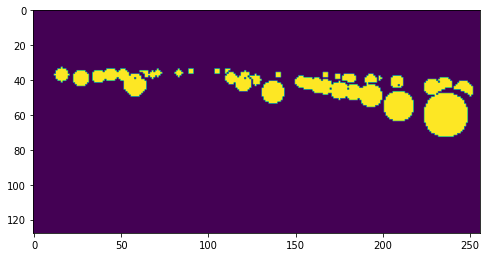

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:16<00:12,  1.21s/it]

theta_x: -0.0806
theta_y: -0.0593
theta_z: 0.0424
phi: 0.0000
gamma: -0.0128
rho: -0.0057


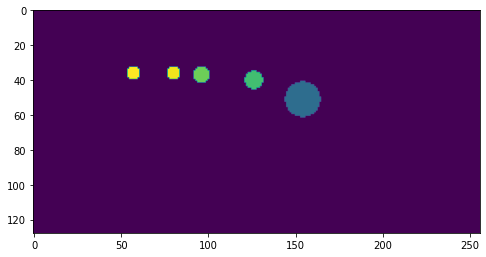

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(57.2467, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(57.4375, device='cuda:0')


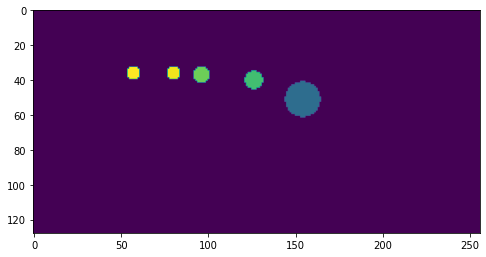

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


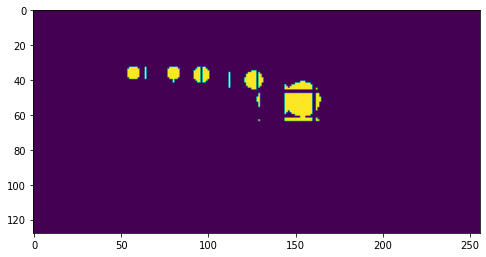

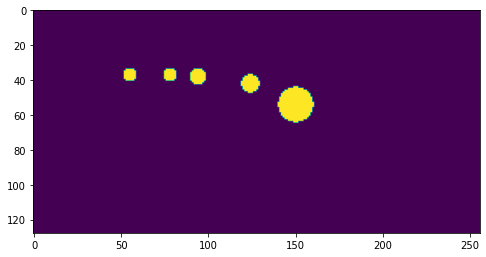

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:17<00:10,  1.20s/it]

theta_x: -0.0792
theta_y: -0.0618
theta_z: 0.0430
phi: -0.0005
gamma: -0.0124
rho: -0.0053


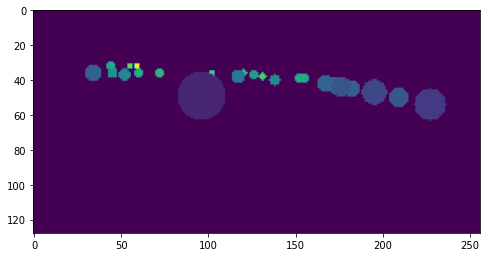

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(138.2601, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(138.7500, device='cuda:0')


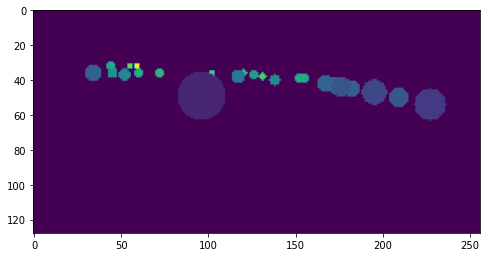

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


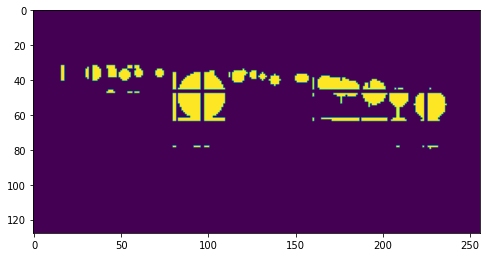

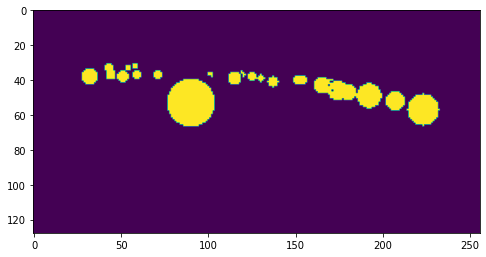

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:19<00:09,  1.21s/it]

theta_x: -0.0790
theta_y: -0.0631
theta_z: 0.0433
phi: -0.0006
gamma: -0.0123
rho: -0.0051


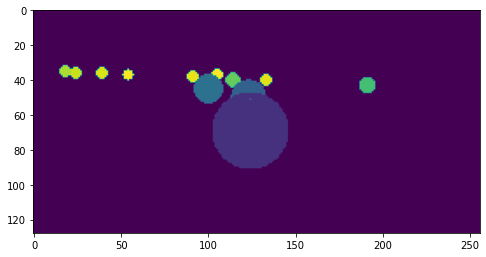

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(65.6952, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(65.9375, device='cuda:0')


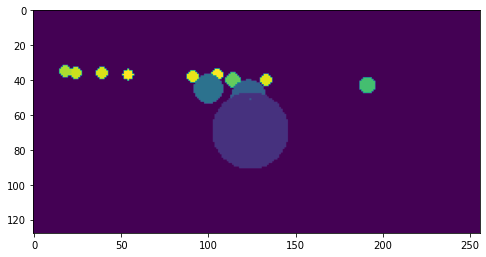

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


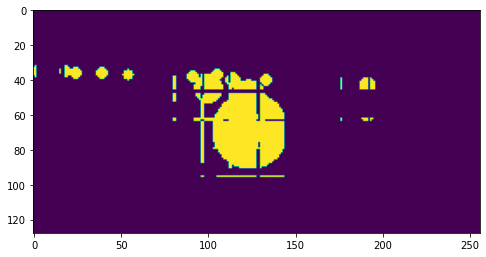

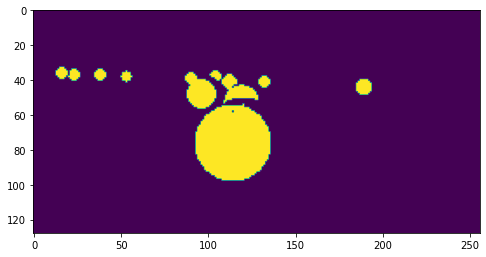

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:20<00:08,  1.21s/it]

theta_x: -0.0797
theta_y: -0.0611
theta_z: 0.0433
phi: -0.0004
gamma: -0.0127
rho: -0.0053


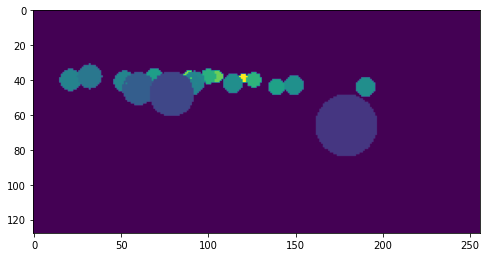

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(74.7955, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(74.9375, device='cuda:0')


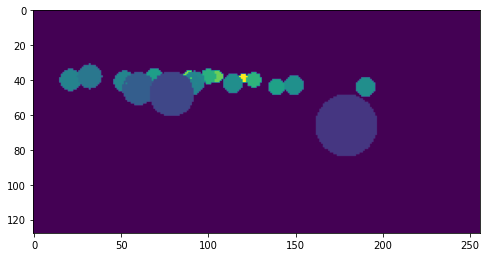

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


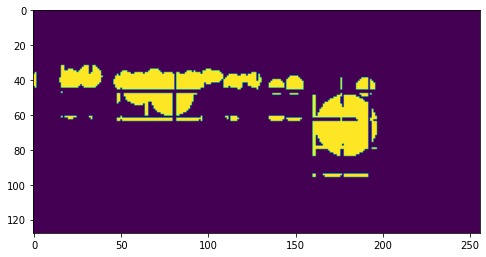

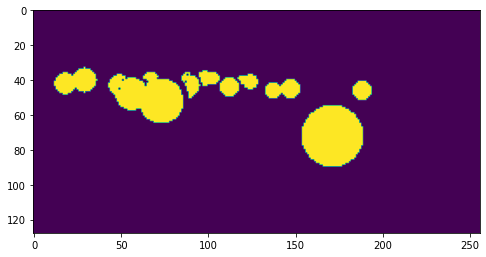

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:21<00:07,  1.19s/it]

theta_x: -0.0805
theta_y: -0.0616
theta_z: 0.0440
phi: 0.0001
gamma: -0.0127
rho: -0.0055


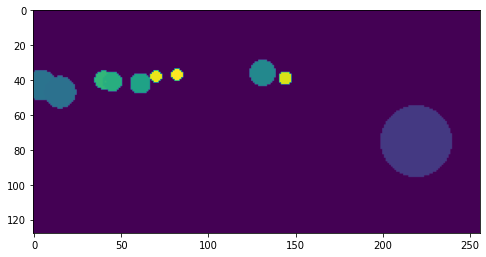

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(60.7702, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(60.9375, device='cuda:0')


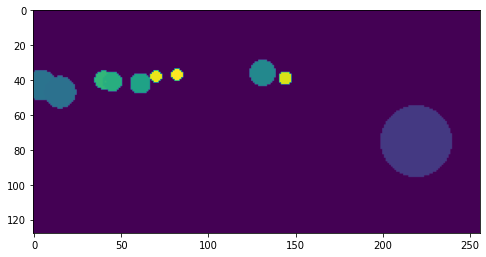

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


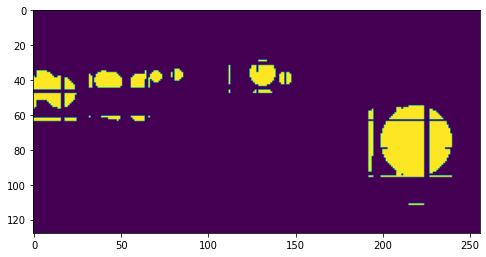

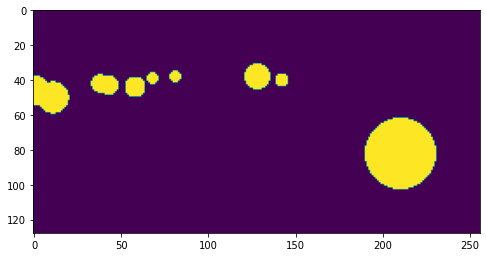

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:22<00:05,  1.19s/it]

theta_x: -0.0803
theta_y: -0.0629
theta_z: 0.0444
phi: -0.0001
gamma: -0.0126
rho: -0.0055


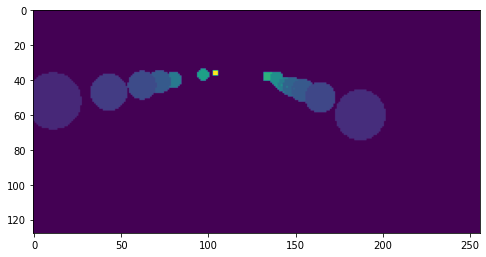

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(111.2822, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(111.5625, device='cuda:0')


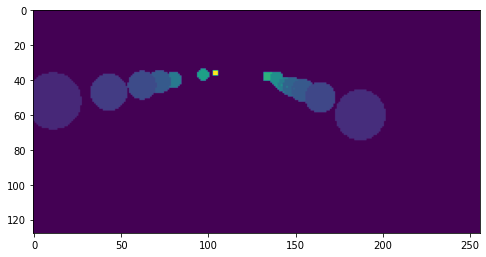

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


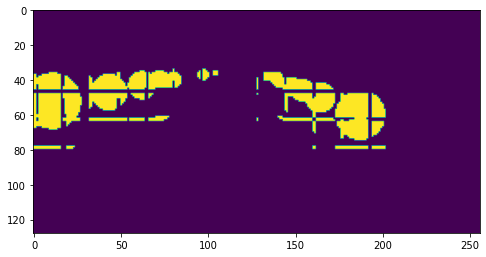

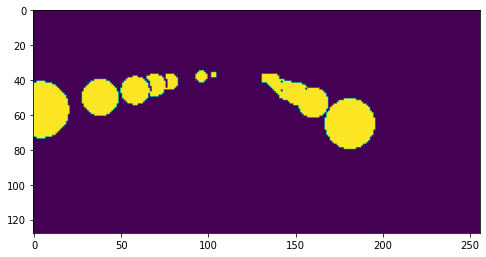

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:23<00:04,  1.21s/it]

theta_x: -0.0813
theta_y: -0.0628
theta_z: 0.0448
phi: 0.0000
gamma: -0.0129
rho: -0.0057


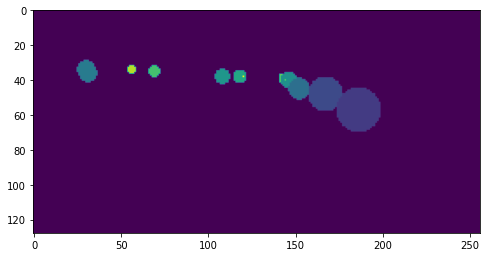

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(92.6211, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(92.8125, device='cuda:0')


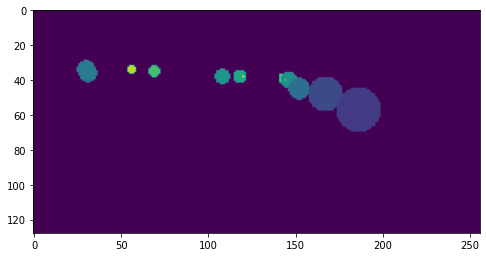

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


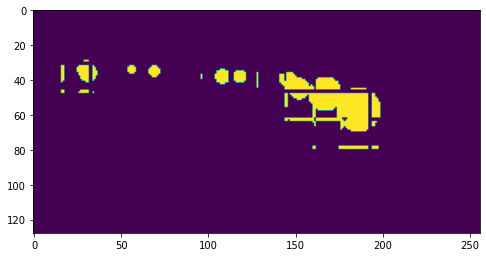

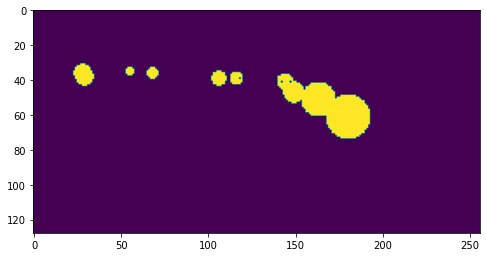

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:25<00:03,  1.23s/it]

theta_x: -0.0809
theta_y: -0.0641
theta_z: 0.0451
phi: 0.0001
gamma: -0.0126
rho: -0.0056


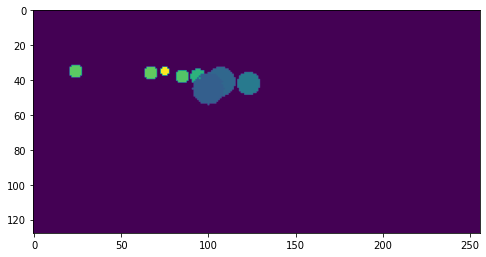

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(75.4604, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(75.6875, device='cuda:0')


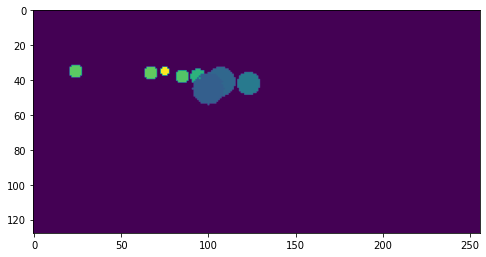

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


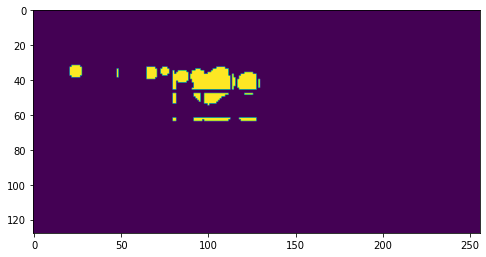

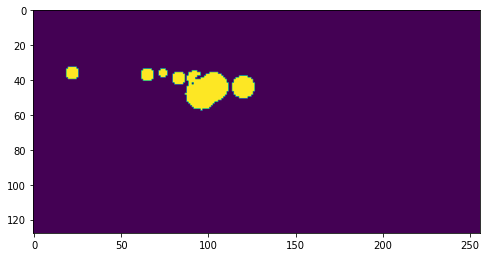

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:26<00:02,  1.23s/it]

theta_x: -0.0804
theta_y: -0.0649
theta_z: 0.0456
phi: 0.0008
gamma: -0.0125
rho: -0.0055


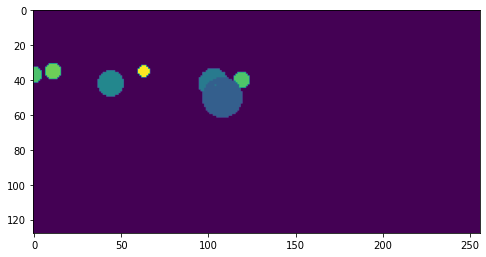

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(59.0213, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(59.2188, device='cuda:0')


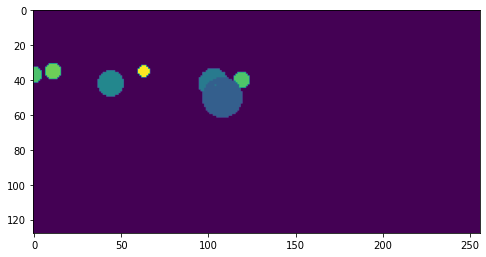

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


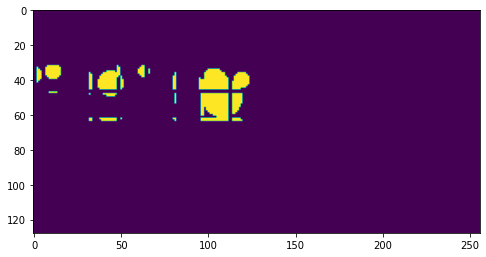

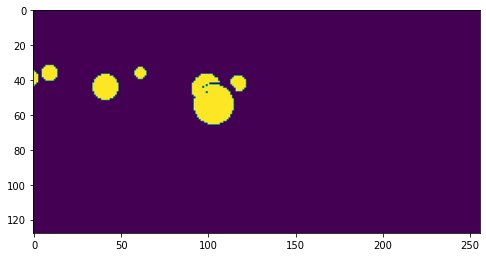

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:27<00:01,  1.24s/it]

theta_x: -0.0830
theta_y: -0.0645
theta_z: 0.0459
phi: 0.0016
gamma: -0.0127
rho: -0.0059


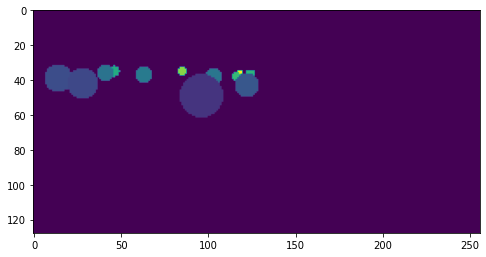

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(110.8361, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(111.0625, device='cuda:0')


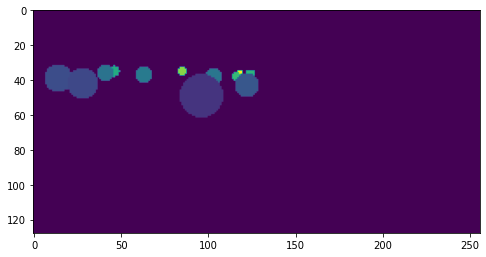

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


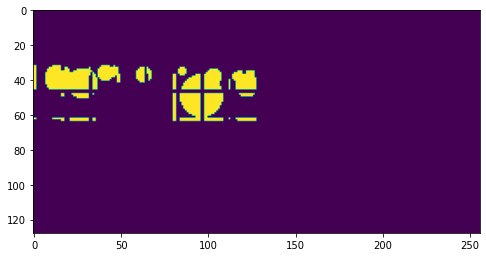

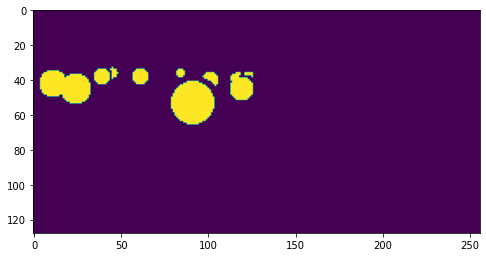

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

theta_x: -0.0812
theta_y: -0.0639
theta_z: 0.0463
phi: 0.0012
gamma: -0.0129
rho: -0.0055
Train Epoch: (4, 4) 	LR: 0.001000	Loss: 1.739130


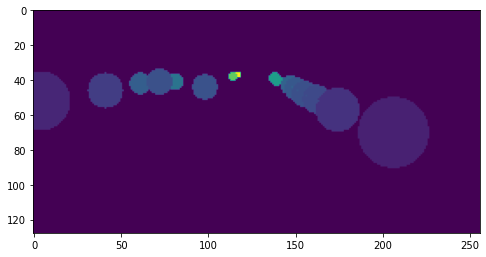

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(113.7711, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(114., device='cuda:0')


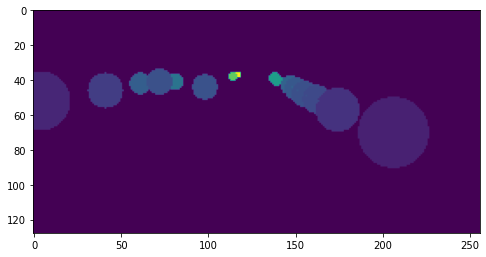

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


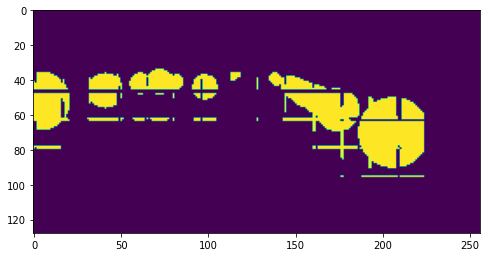

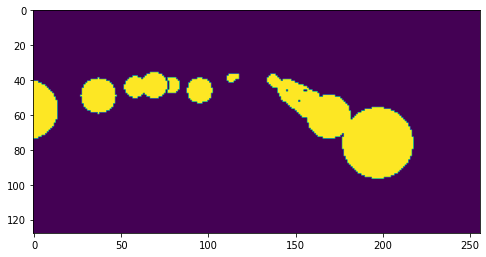

  4%|███▍                                                                               | 1/24 [00:01<00:28,  1.23s/it]

theta_x: -0.0794
theta_y: -0.0665
theta_z: 0.0465
phi: 0.0005
gamma: -0.0123
rho: -0.0050


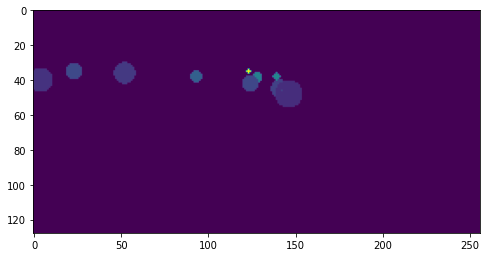

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(202.3576, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(202.7500, device='cuda:0')


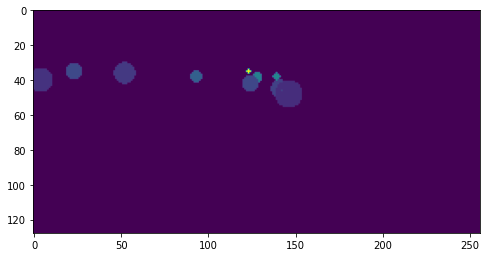

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


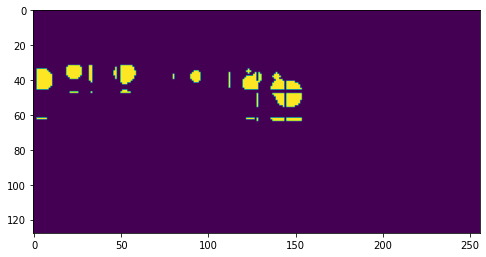

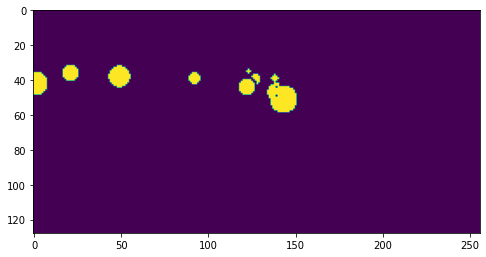

  8%|██████▉                                                                            | 2/24 [00:02<00:27,  1.25s/it]

theta_x: -0.0804
theta_y: -0.0675
theta_z: 0.0469
phi: 0.0006
gamma: -0.0124
rho: -0.0051


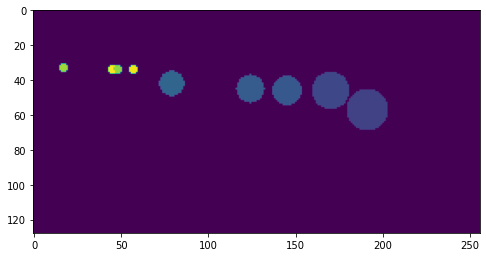

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(89.3283, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(89.6875, device='cuda:0')


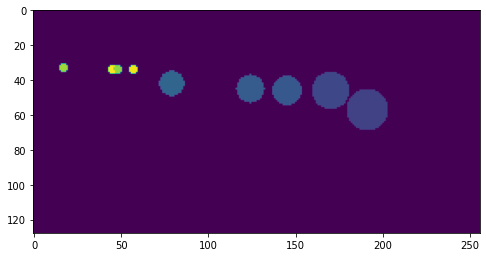

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


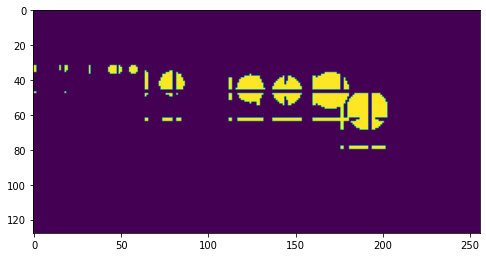

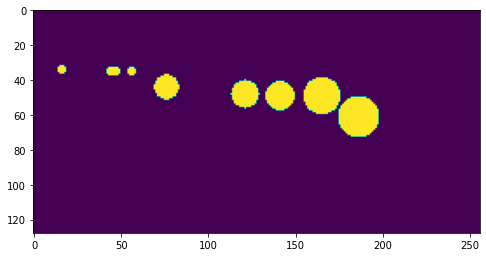

 12%|██████████▍                                                                        | 3/24 [00:03<00:26,  1.29s/it]

theta_x: -0.0819
theta_y: -0.0651
theta_z: 0.0472
phi: 0.0008
gamma: -0.0129
rho: -0.0054


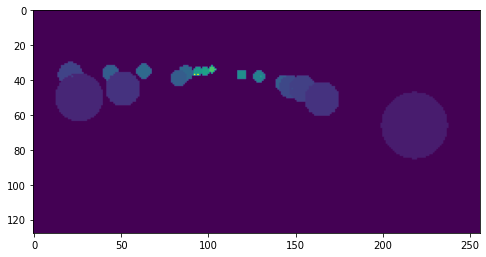

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(143.3020, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(143.7500, device='cuda:0')


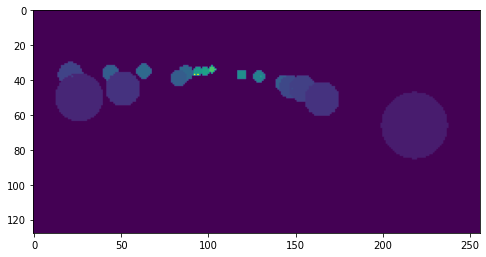

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


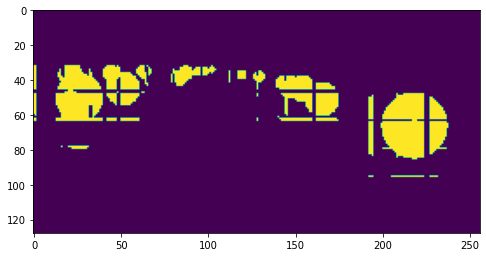

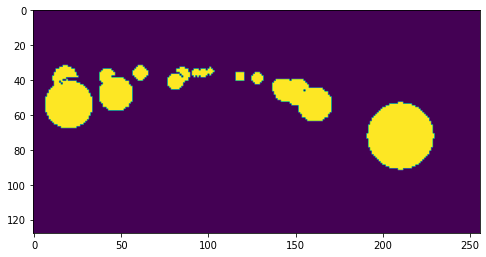

 17%|█████████████▊                                                                     | 4/24 [00:05<00:27,  1.37s/it]

theta_x: -0.0831
theta_y: -0.0654
theta_z: 0.0476
phi: 0.0007
gamma: -0.0131
rho: -0.0057


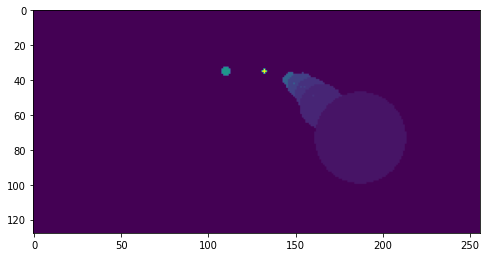

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(155.6094, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(155.8750, device='cuda:0')


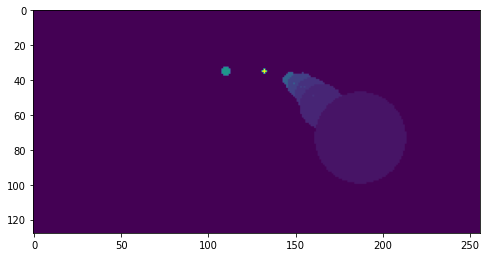

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


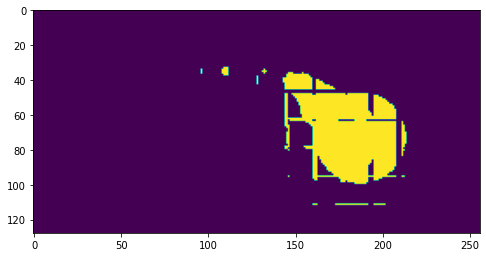

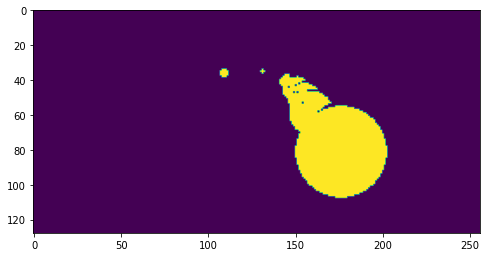

 21%|█████████████████▎                                                                 | 5/24 [00:06<00:26,  1.38s/it]

theta_x: -0.0835
theta_y: -0.0657
theta_z: 0.0479
phi: 0.0011
gamma: -0.0131
rho: -0.0059


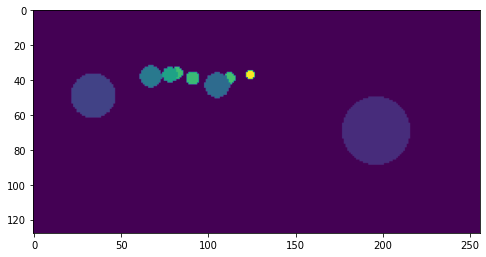

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(83.1699, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(83.3125, device='cuda:0')


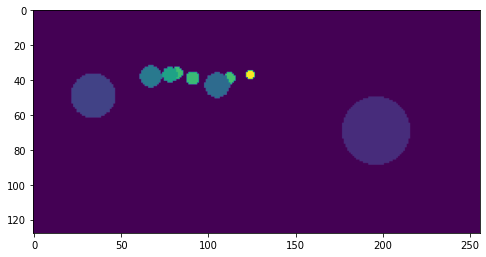

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


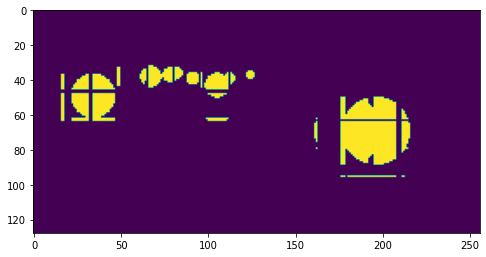

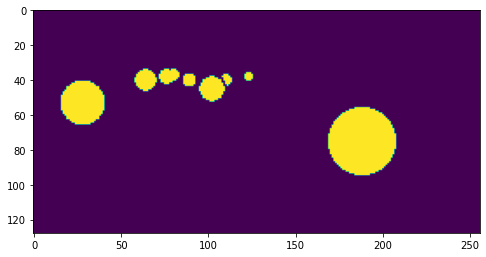

 25%|████████████████████▊                                                              | 6/24 [00:08<00:24,  1.34s/it]

theta_x: -0.0836
theta_y: -0.0670
theta_z: 0.0483
phi: 0.0010
gamma: -0.0130
rho: -0.0057


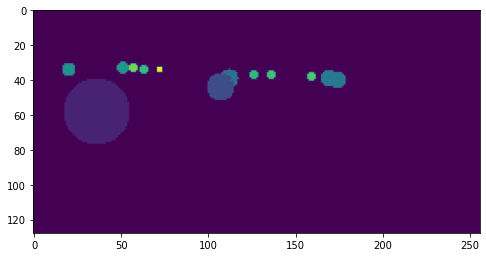

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(110.8185, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(111.1875, device='cuda:0')


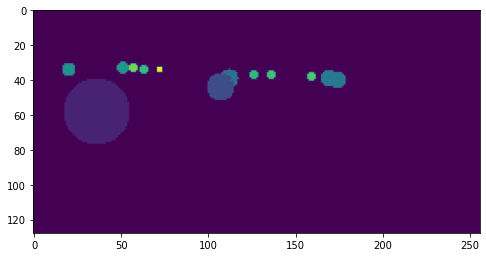

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


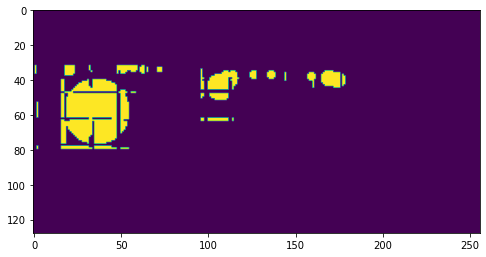

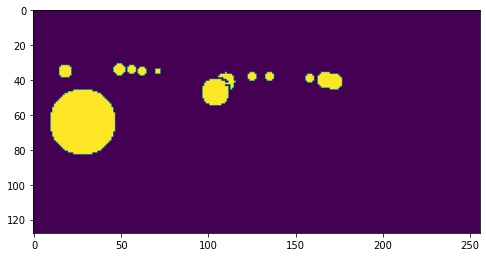

 29%|████████████████████████▏                                                          | 7/24 [00:09<00:21,  1.28s/it]

theta_x: -0.0833
theta_y: -0.0688
theta_z: 0.0488
phi: 0.0006
gamma: -0.0129
rho: -0.0054


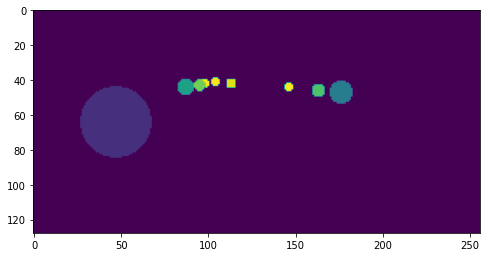

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(76.5756, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(76.6875, device='cuda:0')


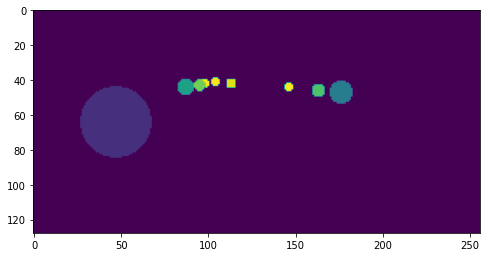

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


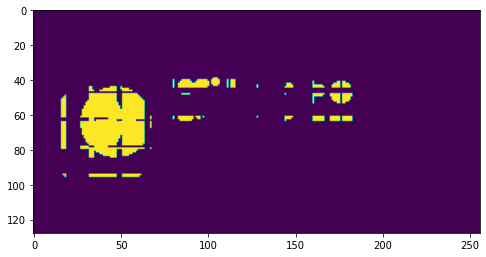

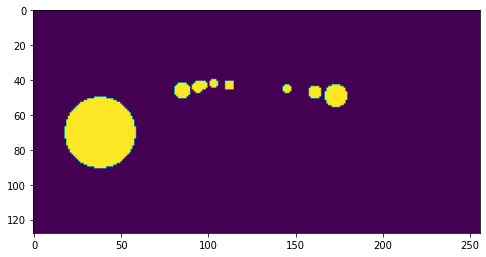

 33%|███████████████████████████▋                                                       | 8/24 [00:10<00:20,  1.29s/it]

theta_x: -0.0846
theta_y: -0.0668
theta_z: 0.0488
phi: 0.0012
gamma: -0.0134
rho: -0.0056


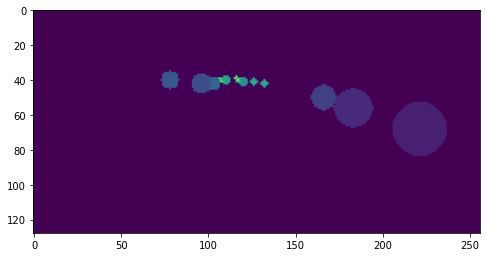

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(151.8734, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(152.2500, device='cuda:0')


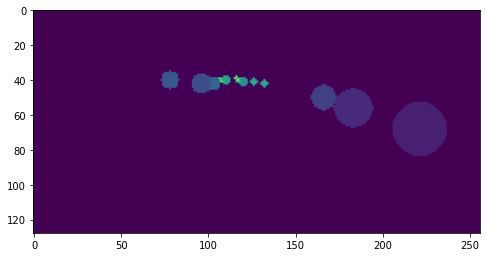

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


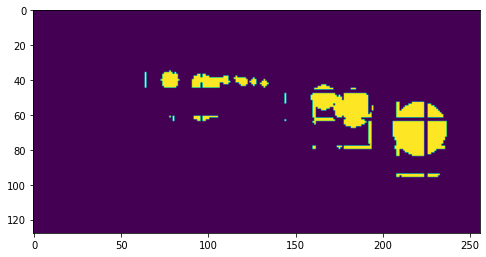

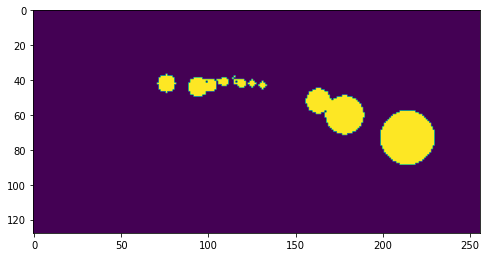

 38%|███████████████████████████████▏                                                   | 9/24 [00:11<00:19,  1.28s/it]

theta_x: -0.0836
theta_y: -0.0677
theta_z: 0.0495
phi: 0.0010
gamma: -0.0133
rho: -0.0054


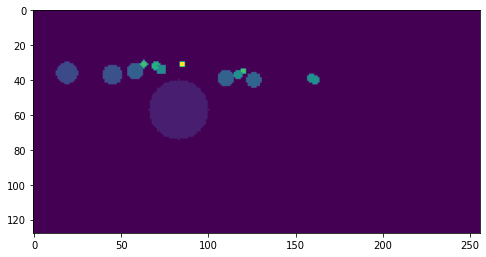

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(145.9604, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(146.3750, device='cuda:0')


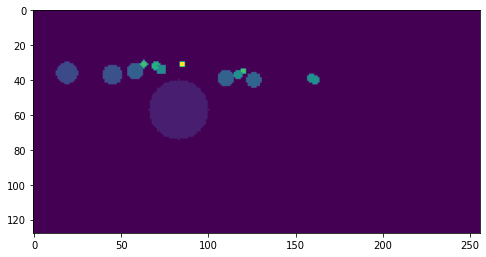

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


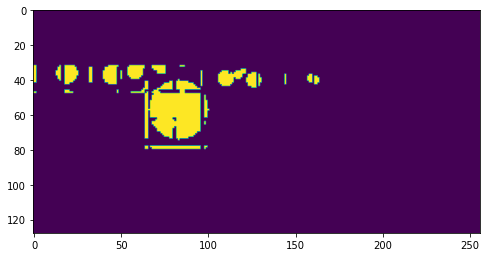

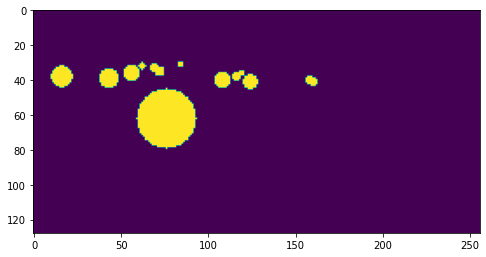

 42%|██████████████████████████████████▏                                               | 10/24 [00:13<00:17,  1.27s/it]

theta_x: -0.0822
theta_y: -0.0688
theta_z: 0.0501
phi: 0.0012
gamma: -0.0133
rho: -0.0051


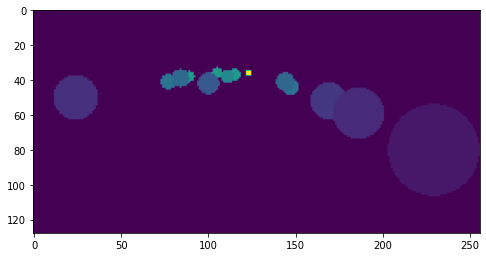

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(120.3274, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(120.5625, device='cuda:0')


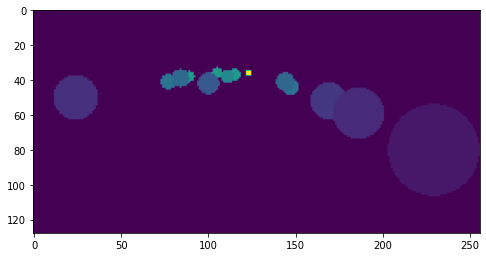

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


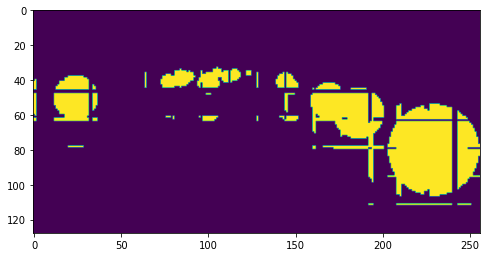

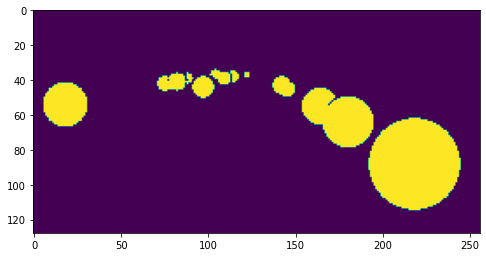

 46%|█████████████████████████████████████▌                                            | 11/24 [00:14<00:16,  1.26s/it]

theta_x: -0.0828
theta_y: -0.0691
theta_z: 0.0503
phi: 0.0011
gamma: -0.0133
rho: -0.0052


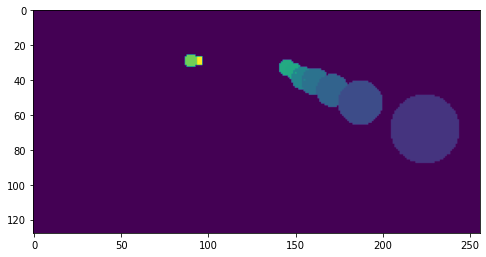

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(69.8090, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(69.9375, device='cuda:0')


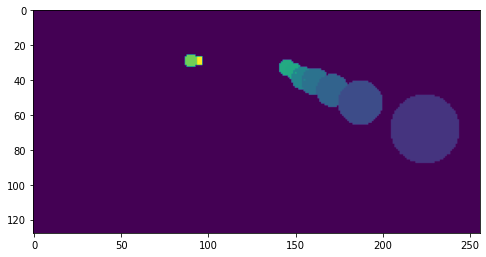

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


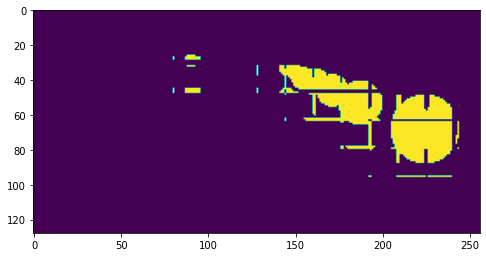

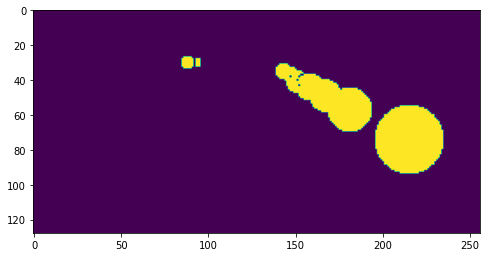

 50%|█████████████████████████████████████████                                         | 12/24 [00:15<00:15,  1.28s/it]

theta_x: -0.0804
theta_y: -0.0702
theta_z: 0.0505
phi: 0.0000
gamma: -0.0131
rho: -0.0045


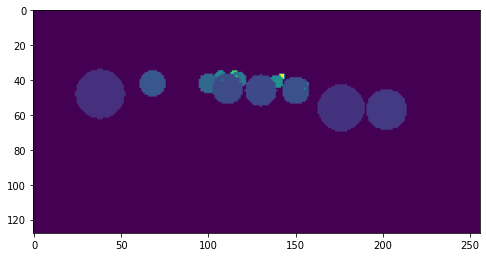

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(104.8391, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(105., device='cuda:0')


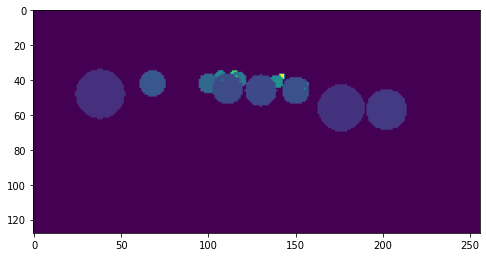

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


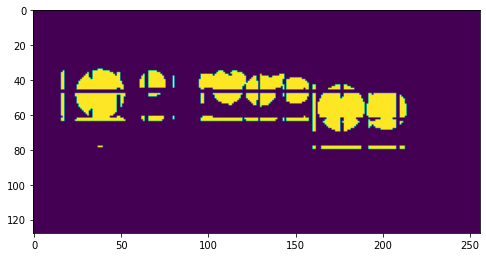

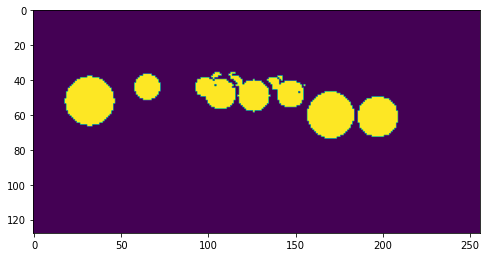

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:16<00:14,  1.28s/it]

theta_x: -0.0831
theta_y: -0.0681
theta_z: 0.0506
phi: 0.0010
gamma: -0.0138
rho: -0.0051


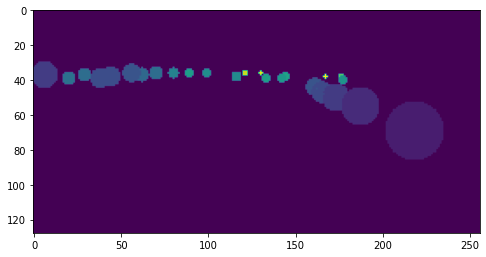

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(151.8562, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(152., device='cuda:0')


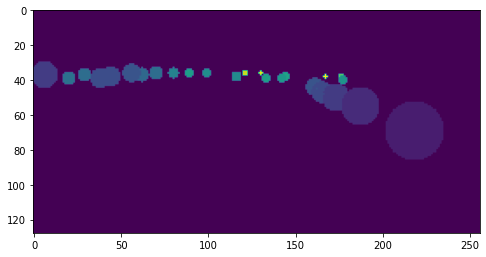

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


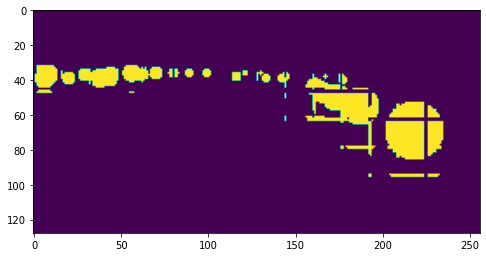

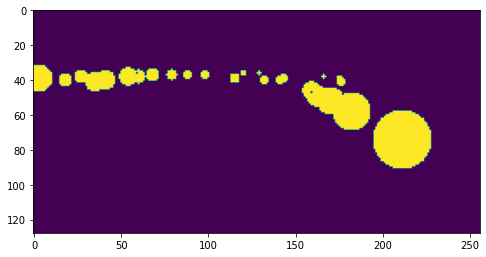

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:18<00:12,  1.29s/it]

theta_x: -0.0822
theta_y: -0.0690
theta_z: 0.0510
phi: 0.0015
gamma: -0.0134
rho: -0.0050


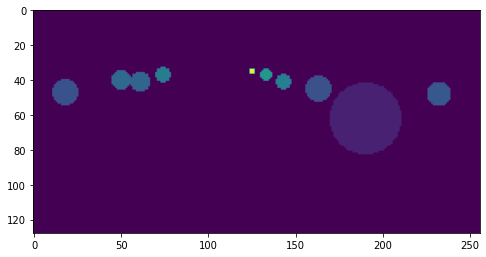

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(111.6134, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(111.8125, device='cuda:0')


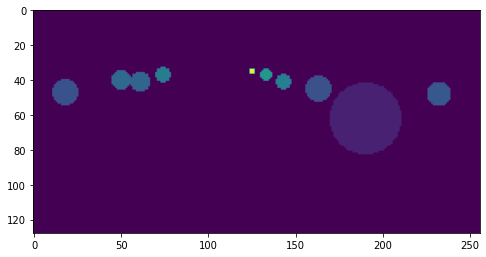

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


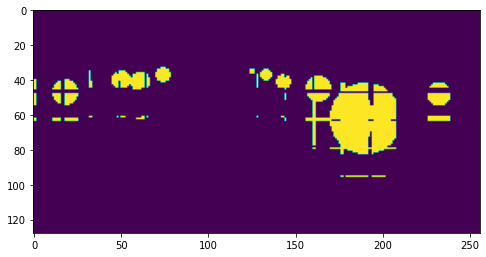

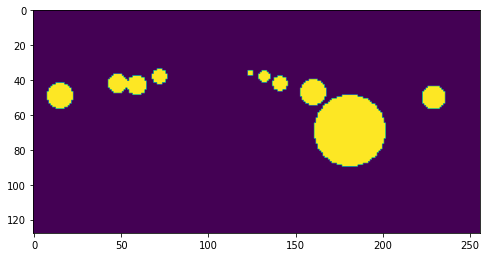

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:19<00:11,  1.27s/it]

theta_x: -0.0809
theta_y: -0.0687
theta_z: 0.0511
phi: 0.0017
gamma: -0.0133
rho: -0.0047


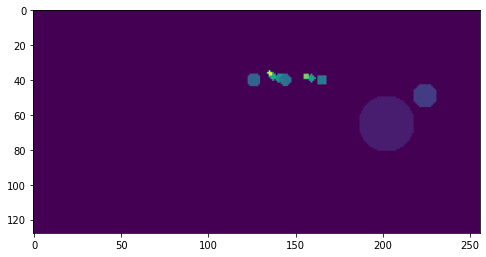

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(165.5932, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(165.8750, device='cuda:0')


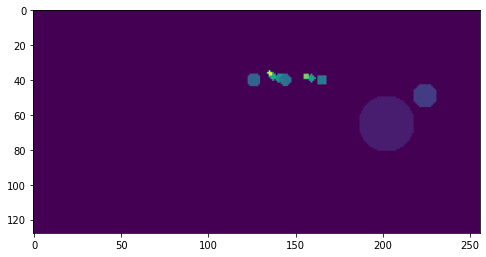

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


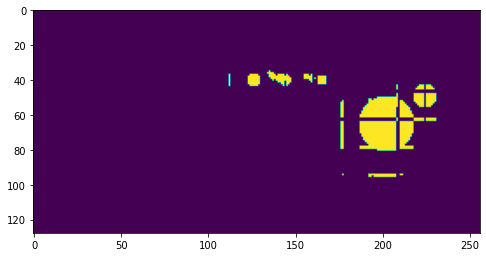

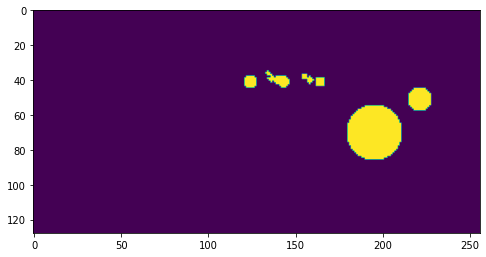

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:20<00:10,  1.27s/it]

theta_x: -0.0798
theta_y: -0.0704
theta_z: 0.0517
phi: 0.0016
gamma: -0.0130
rho: -0.0044


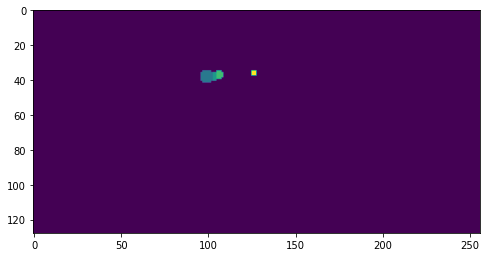

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(129.1446, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(129.3750, device='cuda:0')


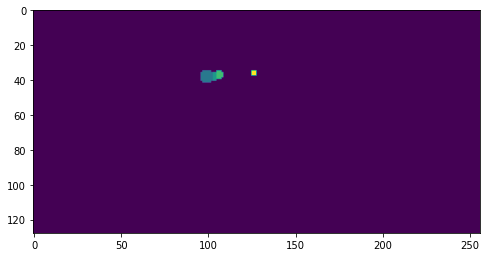

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


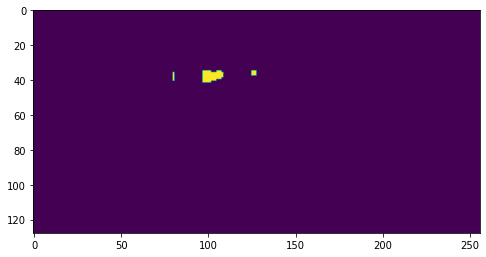

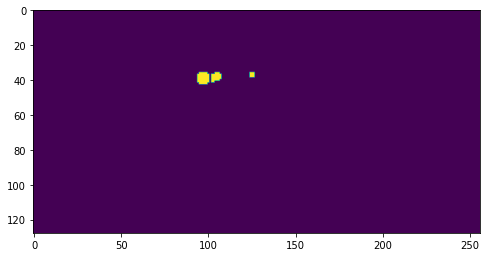

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:21<00:08,  1.26s/it]

theta_x: -0.0798
theta_y: -0.0709
theta_z: 0.0521
phi: 0.0012
gamma: -0.0128
rho: -0.0044


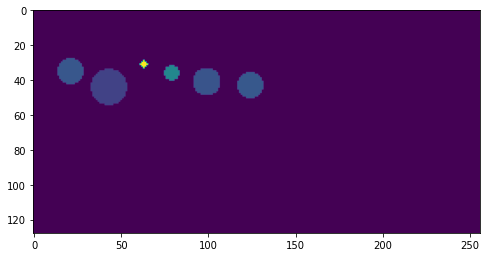

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(100.7400, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(101.0625, device='cuda:0')


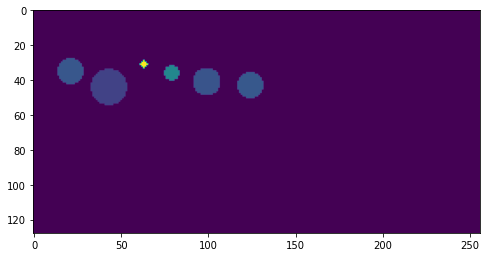

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


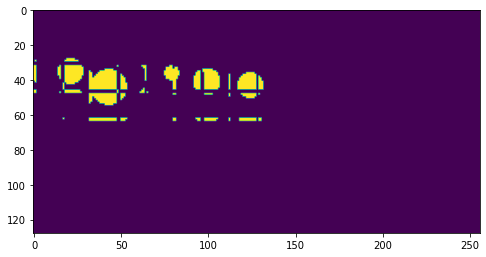

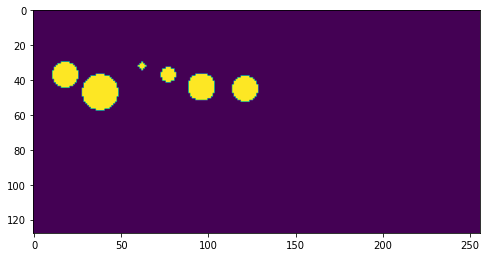

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:23<00:07,  1.27s/it]

theta_x: -0.0839
theta_y: -0.0669
theta_z: 0.0514
phi: 0.0015
gamma: -0.0132
rho: -0.0050


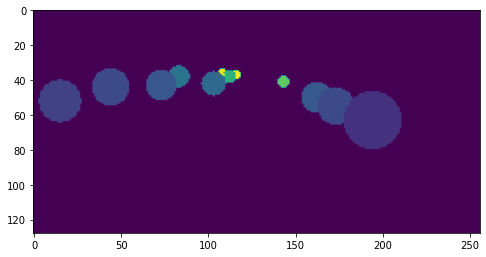

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(86.3990, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(86.5625, device='cuda:0')


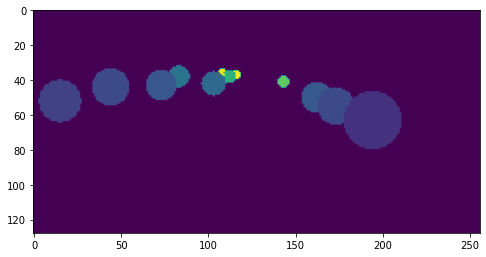

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


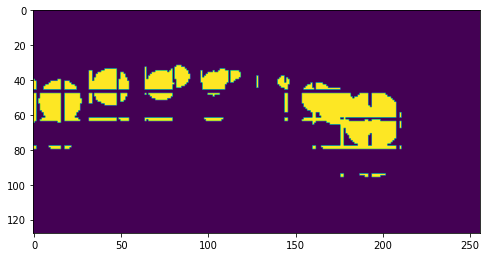

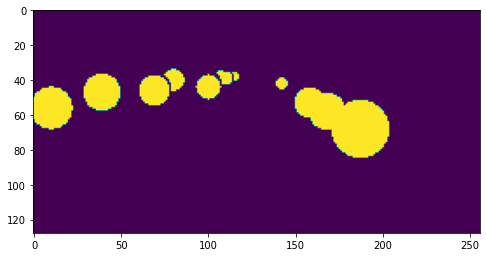

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:24<00:06,  1.29s/it]

theta_x: -0.0838
theta_y: -0.0687
theta_z: 0.0523
phi: 0.0017
gamma: -0.0129
rho: -0.0050


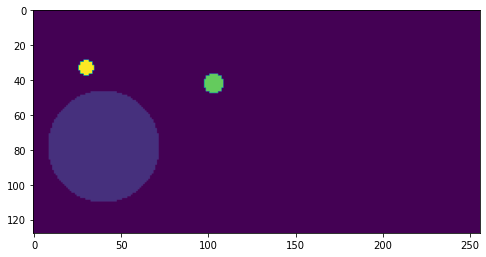

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(46.5381, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(46.6875, device='cuda:0')


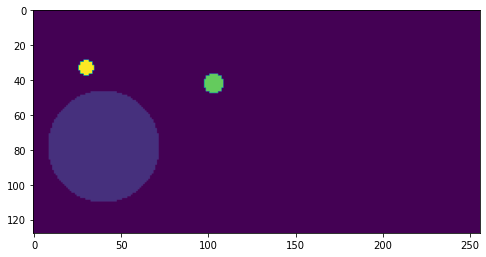

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


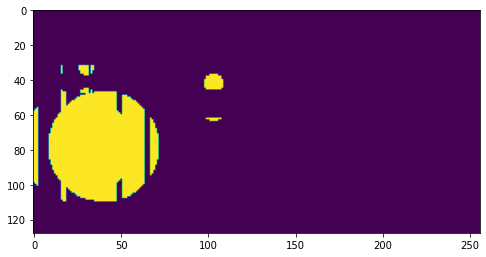

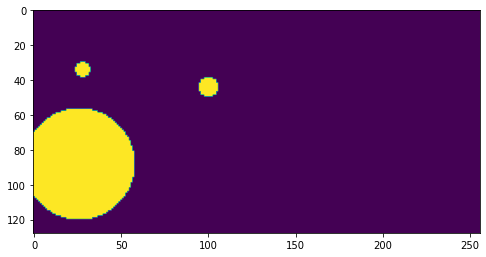

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:25<00:05,  1.26s/it]

theta_x: -0.0827
theta_y: -0.0691
theta_z: 0.0525
phi: 0.0007
gamma: -0.0130
rho: -0.0045


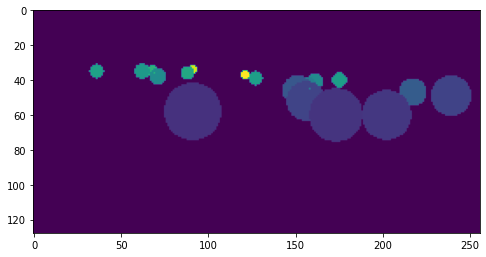

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(89.5962, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(89.7500, device='cuda:0')


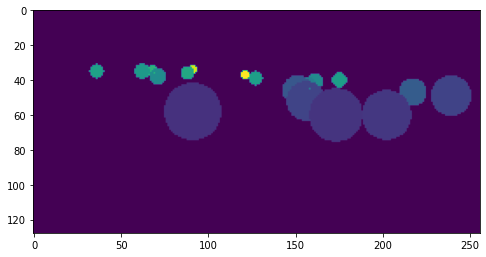

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


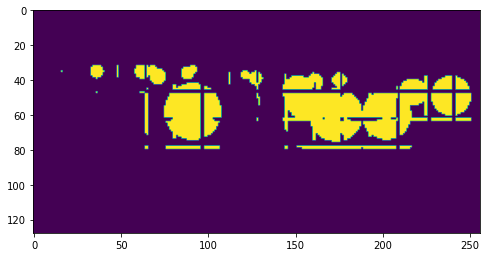

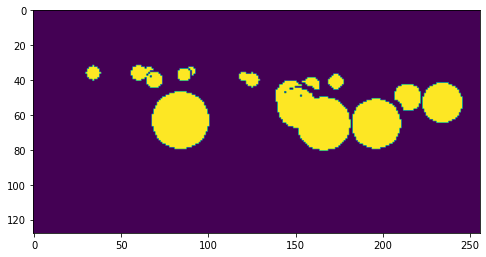

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:26<00:03,  1.22s/it]

theta_x: -0.0836
theta_y: -0.0691
theta_z: 0.0528
phi: 0.0006
gamma: -0.0127
rho: -0.0046


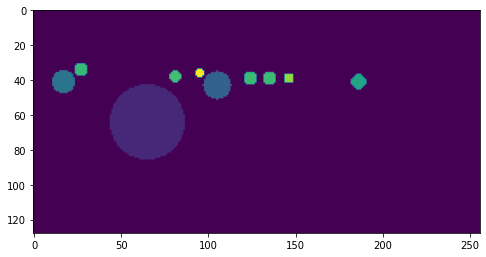

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(83.1881, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(83.3750, device='cuda:0')


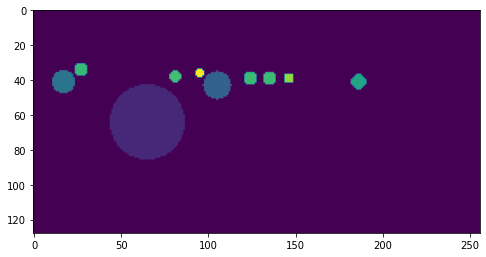

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


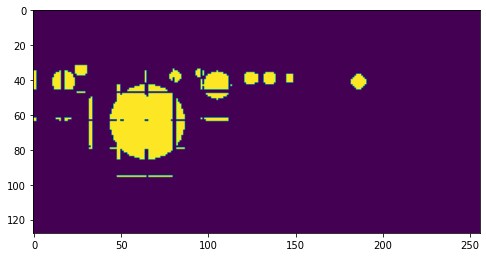

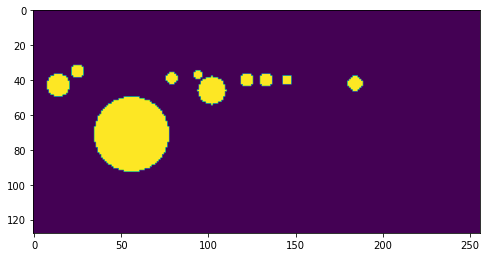

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:28<00:02,  1.21s/it]

theta_x: -0.0833
theta_y: -0.0699
theta_z: 0.0533
phi: 0.0000
gamma: -0.0127
rho: -0.0044


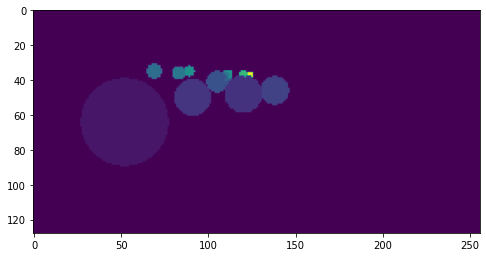

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(132.1245, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(132.3750, device='cuda:0')


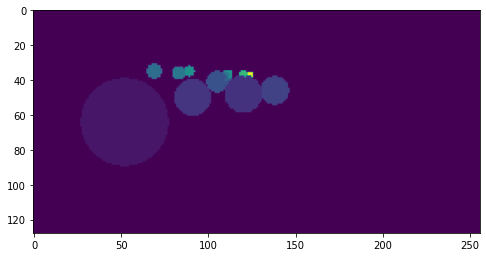

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


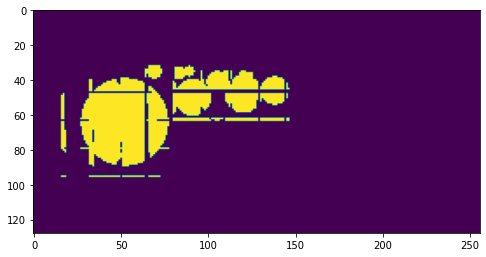

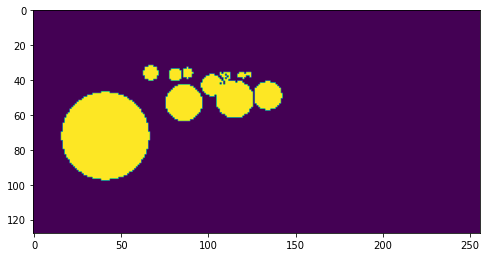

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:29<00:01,  1.19s/it]

theta_x: -0.0827
theta_y: -0.0697
theta_z: 0.0535
phi: 0.0001
gamma: -0.0128
rho: -0.0043


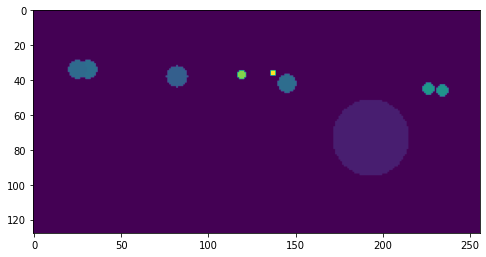

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(112.5885, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(112.7500, device='cuda:0')


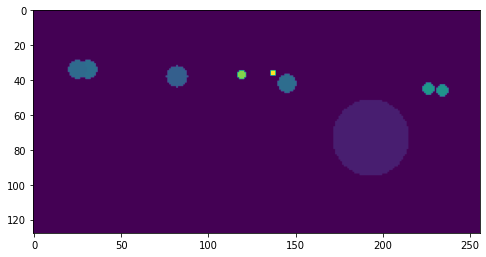

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


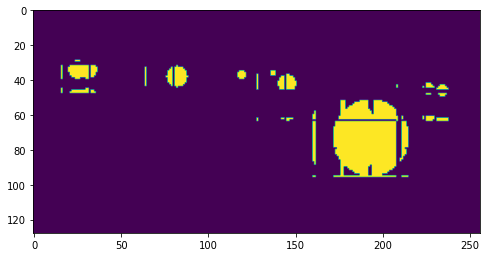

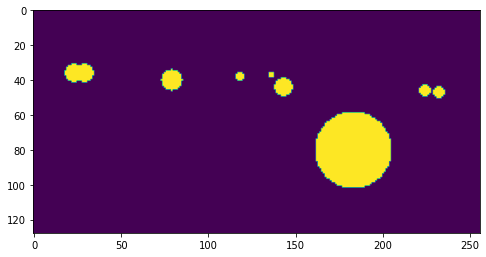

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

theta_x: -0.0828
theta_y: -0.0702
theta_z: 0.0537
phi: 0.0000
gamma: -0.0128
rho: -0.0044
Train Epoch: (4, 5) 	LR: 0.001000	Loss: 1.786685


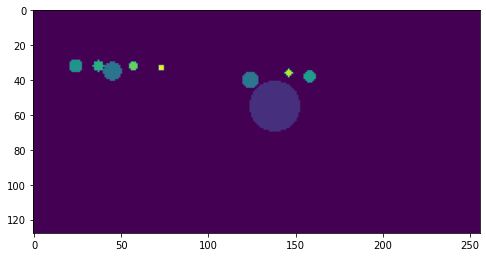

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(105.6285, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(105.9375, device='cuda:0')


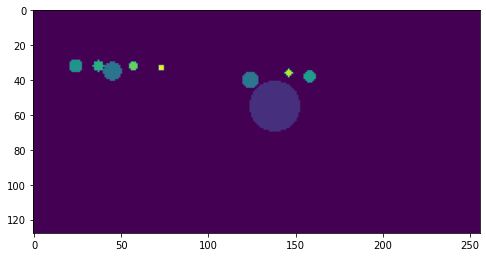

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


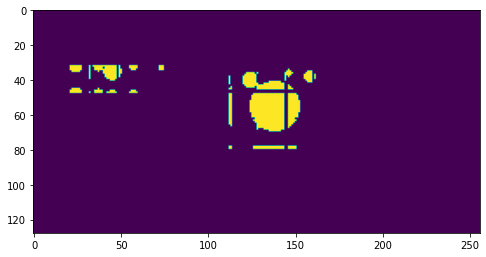

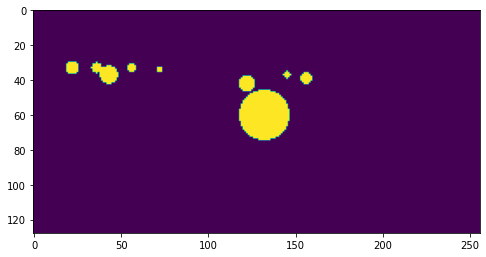

  4%|███▍                                                                               | 1/24 [00:01<00:27,  1.20s/it]

theta_x: -0.0842
theta_y: -0.0709
theta_z: 0.0536
phi: 0.0002
gamma: -0.0127
rho: -0.0047


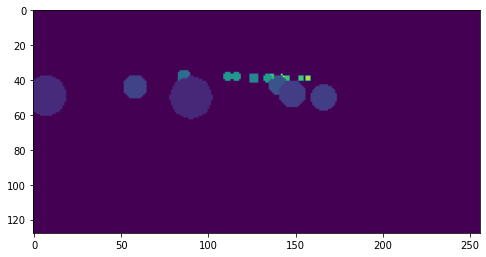

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(150.3973, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(150.6250, device='cuda:0')


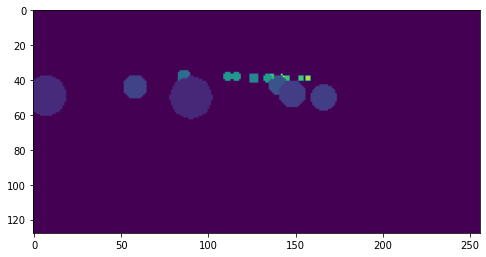

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


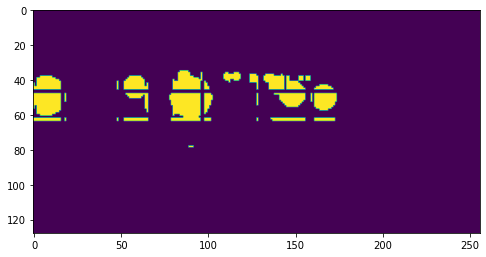

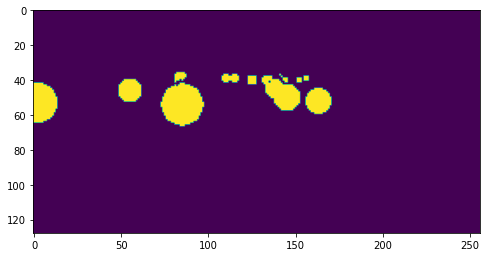

  8%|██████▉                                                                            | 2/24 [00:02<00:26,  1.18s/it]

theta_x: -0.0853
theta_y: -0.0697
theta_z: 0.0536
phi: 0.0009
gamma: -0.0128
rho: -0.0051


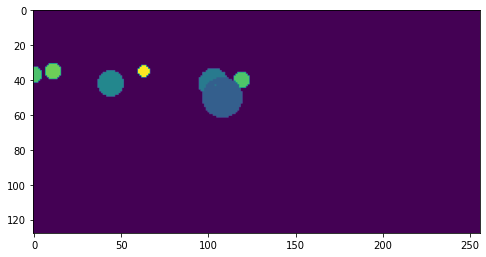

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(59.0422, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(59.2188, device='cuda:0')


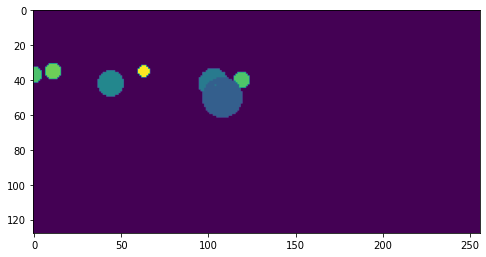

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


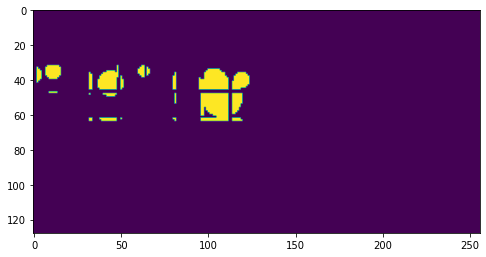

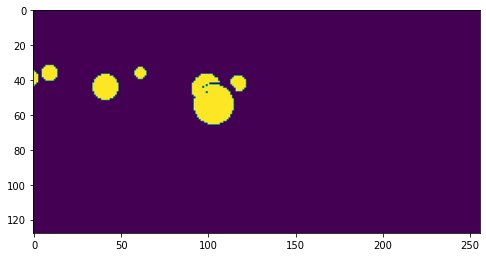

 12%|██████████▍                                                                        | 3/24 [00:03<00:24,  1.18s/it]

theta_x: -0.0850
theta_y: -0.0693
theta_z: 0.0538
phi: 0.0006
gamma: -0.0131
rho: -0.0051


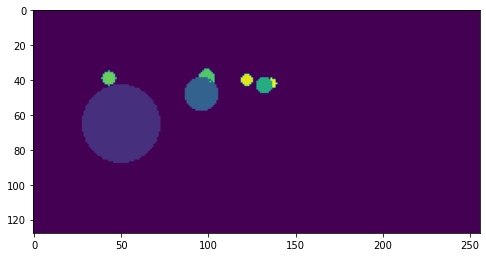

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(67.3440, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(67.4375, device='cuda:0')


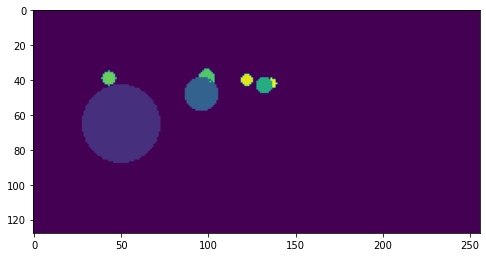

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


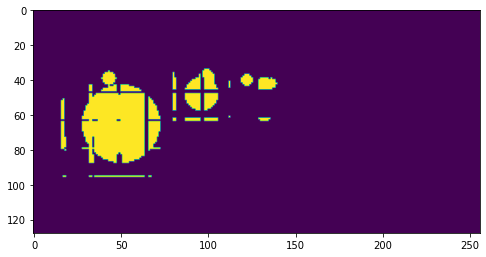

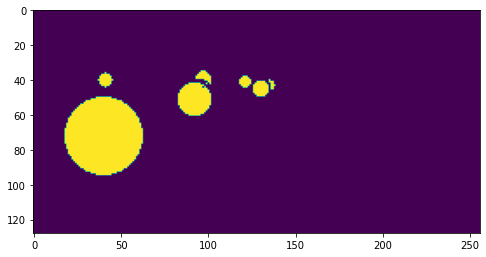

 17%|█████████████▊                                                                     | 4/24 [00:04<00:23,  1.20s/it]

theta_x: -0.0833
theta_y: -0.0711
theta_z: 0.0540
phi: 0.0002
gamma: -0.0129
rho: -0.0047


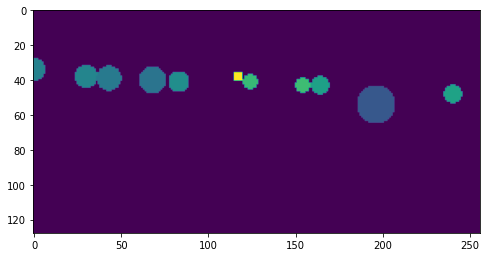

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(70.0625, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(70.1875, device='cuda:0')


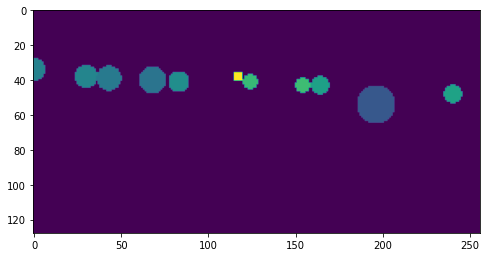

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


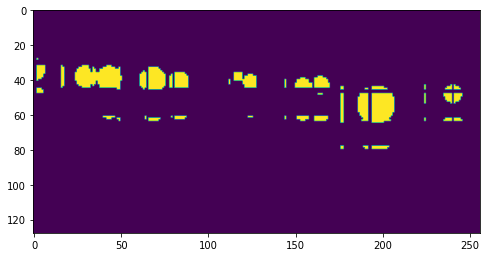

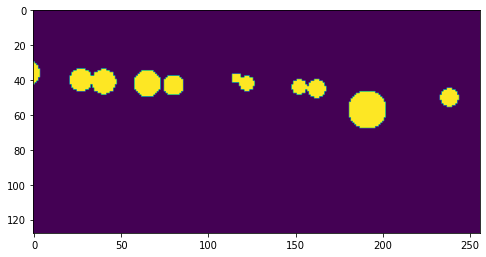

 21%|█████████████████▎                                                                 | 5/24 [00:05<00:22,  1.19s/it]

theta_x: -0.0849
theta_y: -0.0698
theta_z: 0.0544
phi: -0.0001
gamma: -0.0133
rho: -0.0049


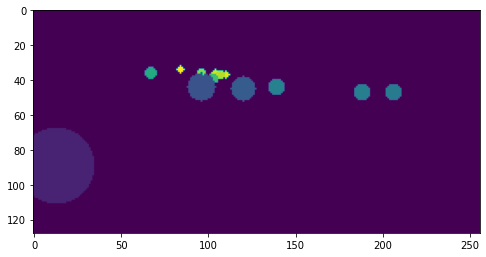

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(101.6030, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(101.8750, device='cuda:0')


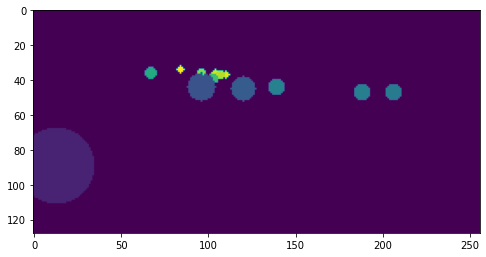

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


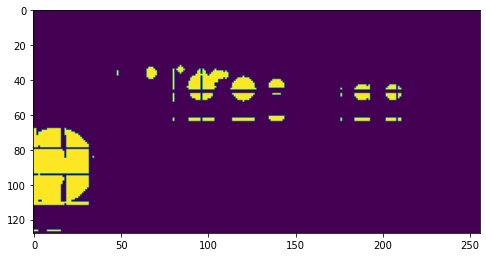

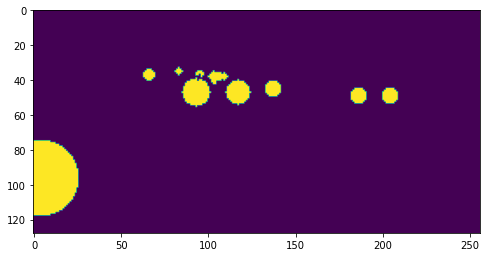

 25%|████████████████████▊                                                              | 6/24 [00:07<00:21,  1.18s/it]

theta_x: -0.0842
theta_y: -0.0709
theta_z: 0.0548
phi: -0.0004
gamma: -0.0131
rho: -0.0047


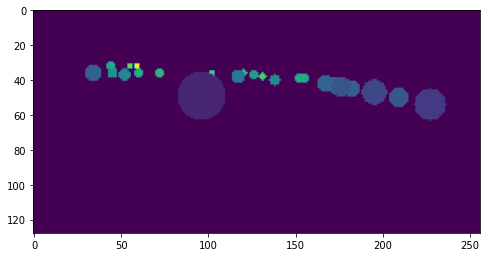

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(138.2661, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(138.7500, device='cuda:0')


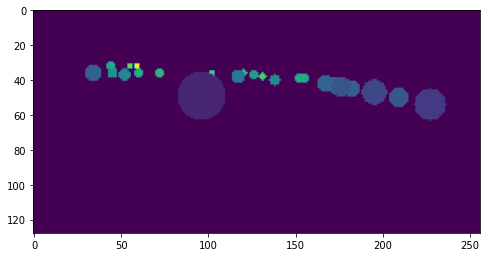

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


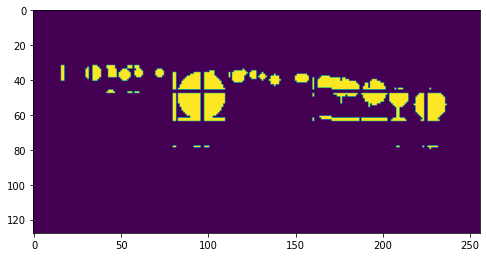

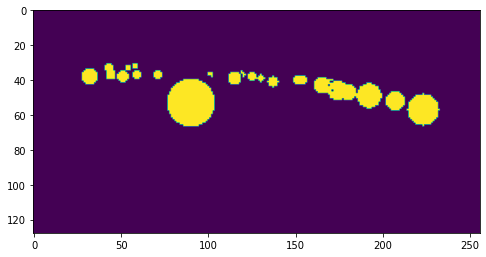

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:19,  1.17s/it]

theta_x: -0.0850
theta_y: -0.0710
theta_z: 0.0550
phi: -0.0001
gamma: -0.0131
rho: -0.0049


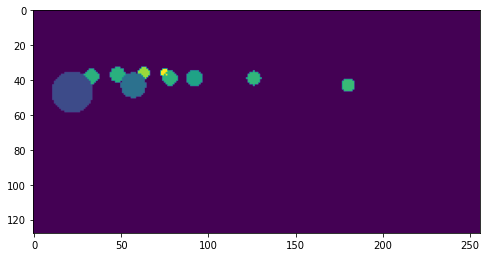

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(76.7802, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(77., device='cuda:0')


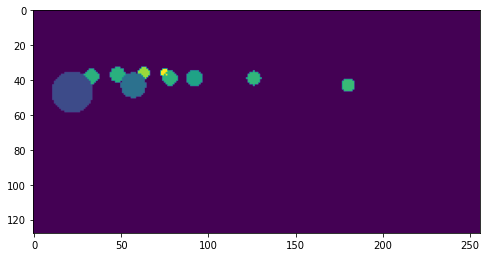

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


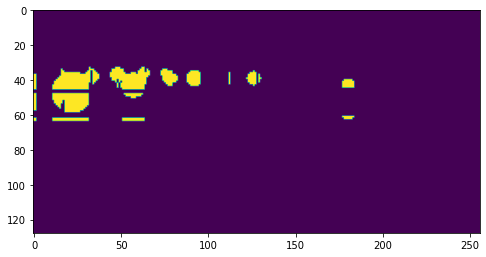

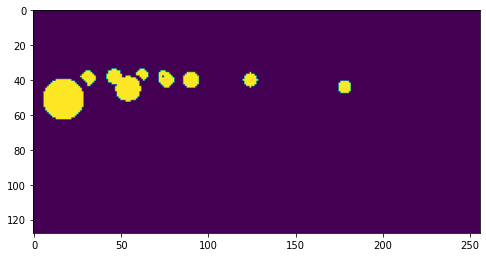

 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:18,  1.18s/it]

theta_x: -0.0867
theta_y: -0.0709
theta_z: 0.0548
phi: 0.0000
gamma: -0.0130
rho: -0.0048


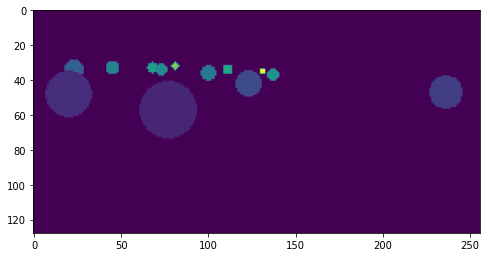

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(119.4444, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(119.6250, device='cuda:0')


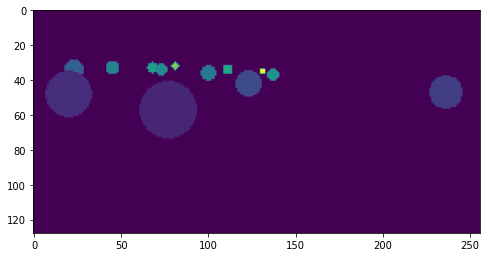

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


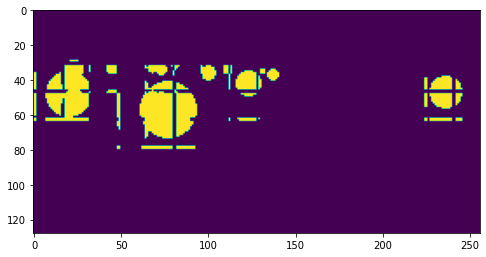

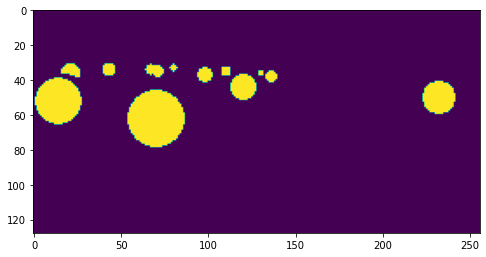

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:17,  1.17s/it]

theta_x: -0.0859
theta_y: -0.0710
theta_z: 0.0552
phi: 0.0000
gamma: -0.0127
rho: -0.0048


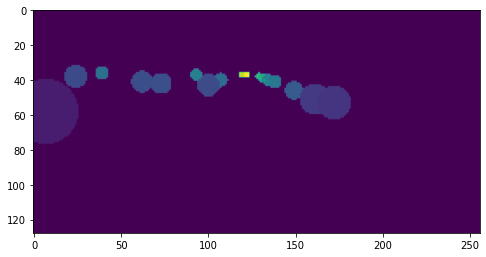

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(141.8468, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(142.1250, device='cuda:0')


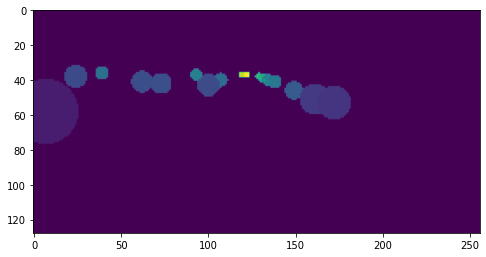

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


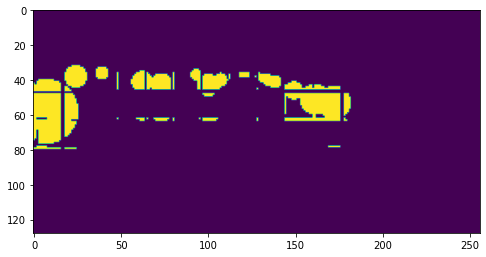

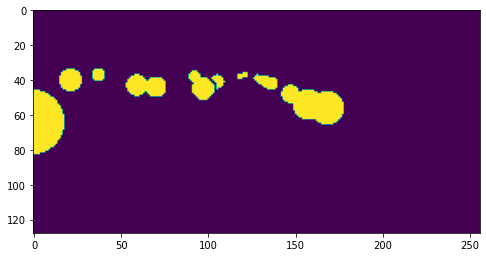

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:16,  1.15s/it]

theta_x: -0.0856
theta_y: -0.0709
theta_z: 0.0552
phi: 0.0003
gamma: -0.0128
rho: -0.0047


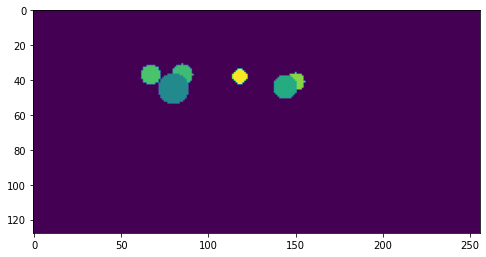

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(49.8993, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(49.9688, device='cuda:0')


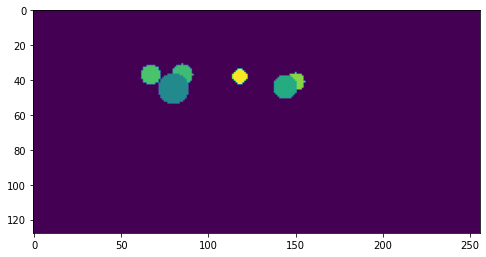

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


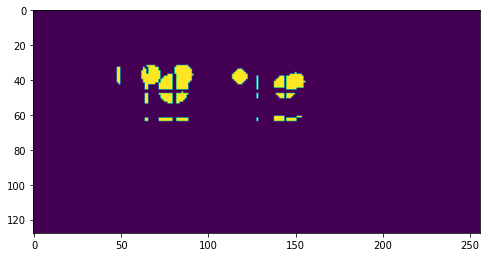

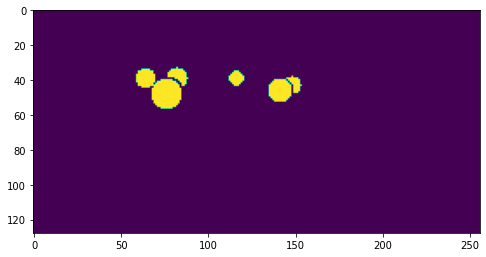

 46%|█████████████████████████████████████▌                                            | 11/24 [00:12<00:14,  1.15s/it]

theta_x: -0.0896
theta_y: -0.0666
theta_z: 0.0543
phi: 0.0005
gamma: -0.0135
rho: -0.0051


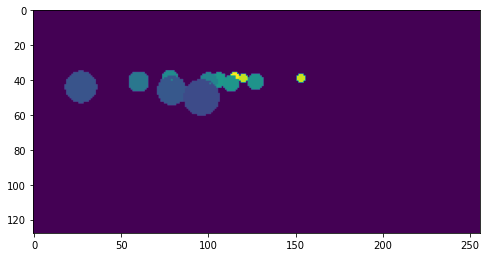

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(88.0047, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(88.1875, device='cuda:0')


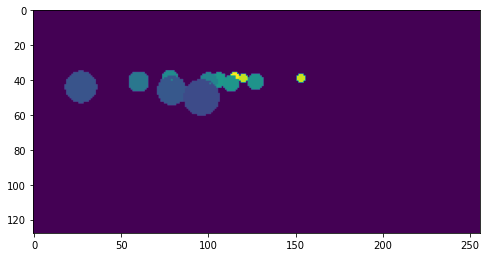

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


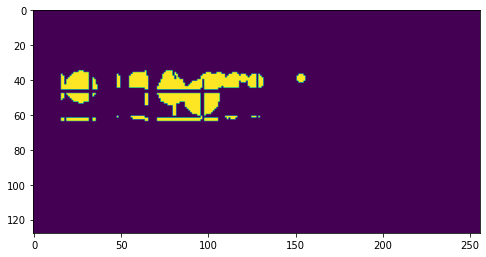

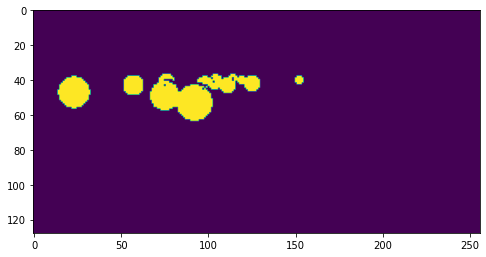

 50%|█████████████████████████████████████████                                         | 12/24 [00:13<00:13,  1.15s/it]

theta_x: -0.0894
theta_y: -0.0668
theta_z: 0.0549
phi: 0.0004
gamma: -0.0136
rho: -0.0050


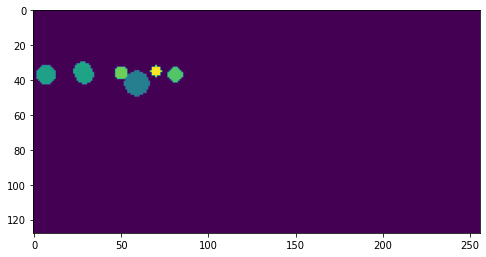

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(66.9311, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(67.1250, device='cuda:0')


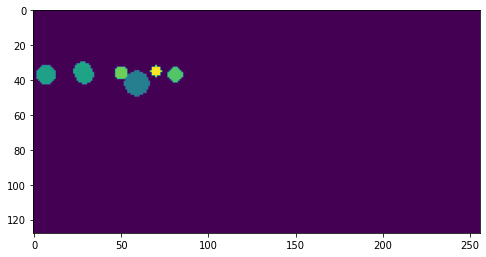

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


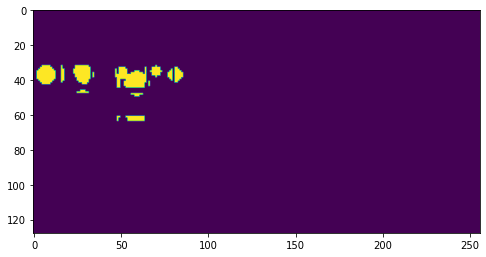

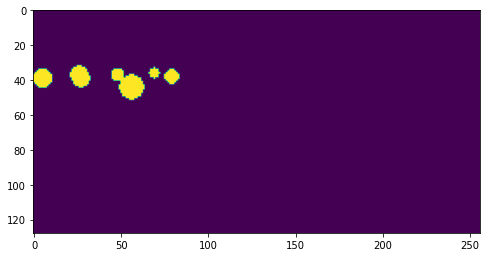

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:15<00:12,  1.16s/it]

theta_x: -0.0879
theta_y: -0.0671
theta_z: 0.0554
phi: 0.0001
gamma: -0.0137
rho: -0.0048


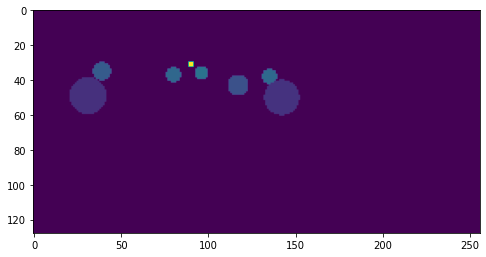

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(140.8868, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(141.2500, device='cuda:0')


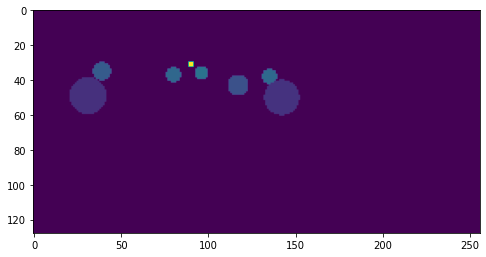

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


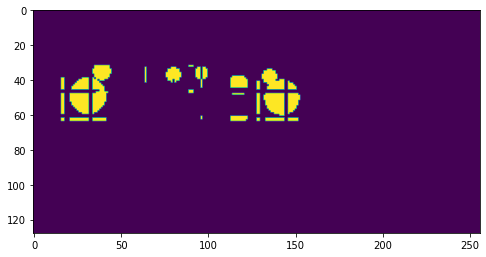

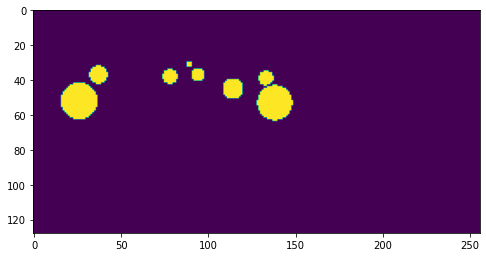

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:16<00:11,  1.15s/it]

theta_x: -0.0893
theta_y: -0.0685
theta_z: 0.0557
phi: 0.0000
gamma: -0.0134
rho: -0.0047


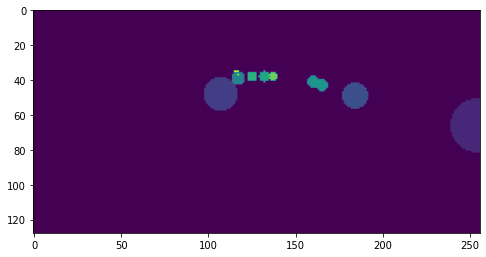

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(114.9431, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(115.1875, device='cuda:0')


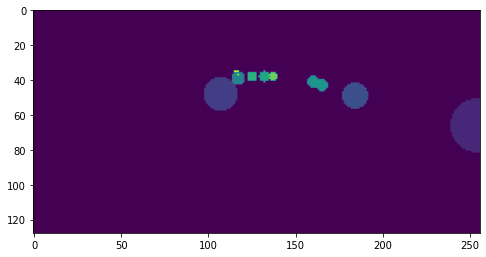

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


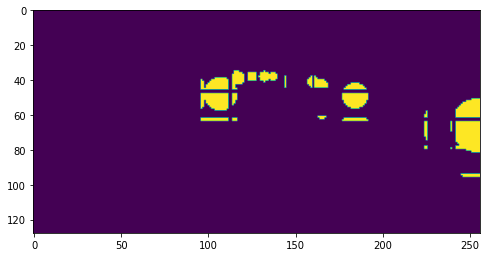

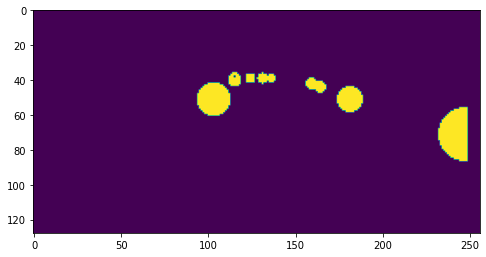

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:17<00:10,  1.17s/it]

theta_x: -0.0883
theta_y: -0.0666
theta_z: 0.0561
phi: -0.0001
gamma: -0.0138
rho: -0.0045


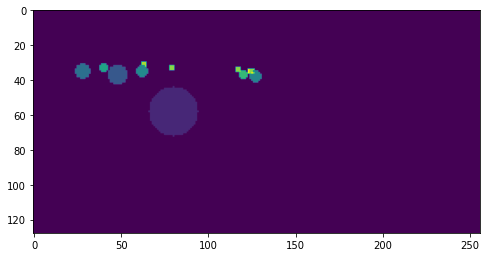

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(130.8755, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(131.1250, device='cuda:0')


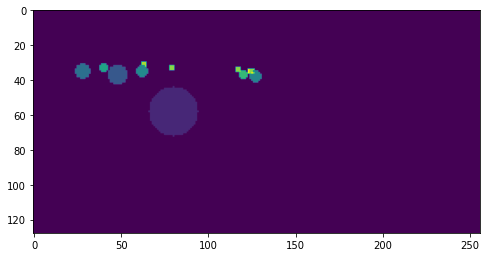

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


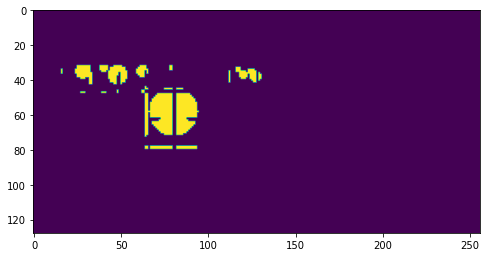

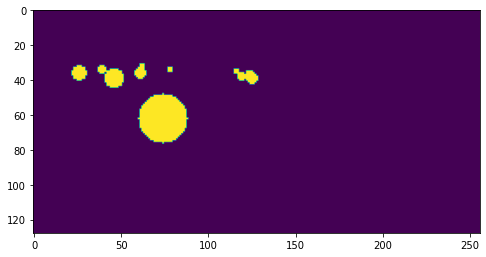

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:18<00:09,  1.18s/it]

theta_x: -0.0901
theta_y: -0.0696
theta_z: 0.0566
phi: 0.0006
gamma: -0.0134
rho: -0.0047


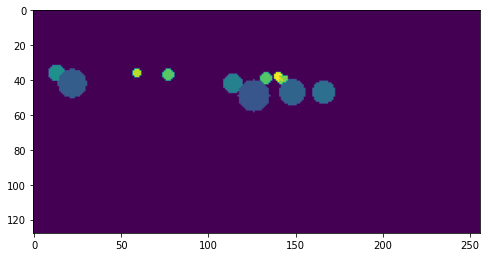

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(86.5156, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(86.6250, device='cuda:0')


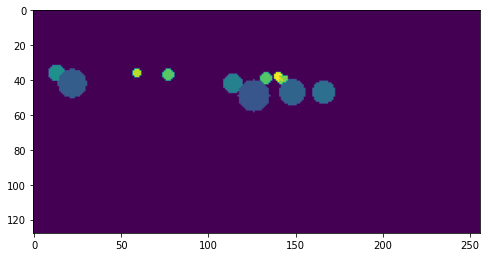

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


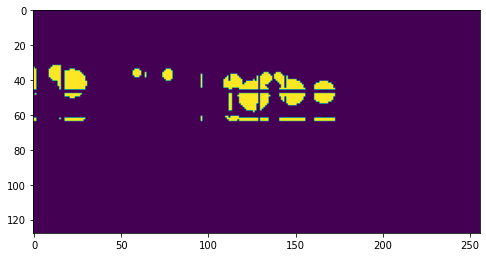

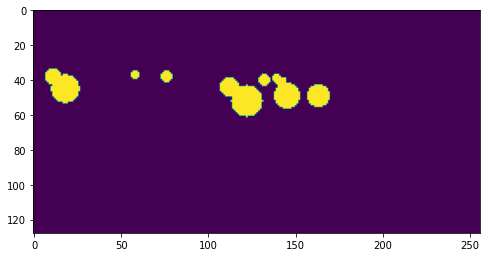

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:19<00:08,  1.16s/it]

theta_x: -0.0918
theta_y: -0.0699
theta_z: 0.0567
phi: 0.0009
gamma: -0.0133
rho: -0.0051


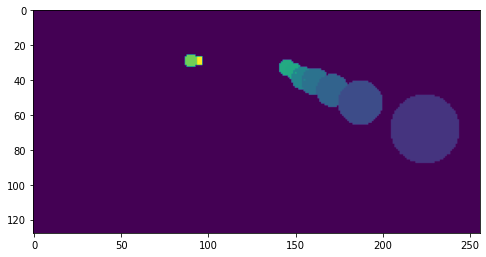

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(69.8132, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(69.9375, device='cuda:0')


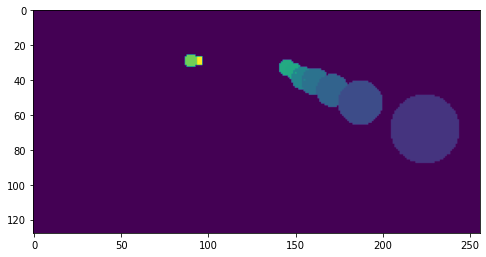

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


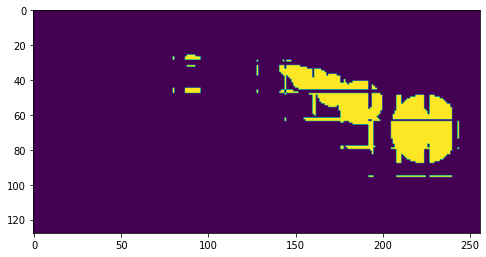

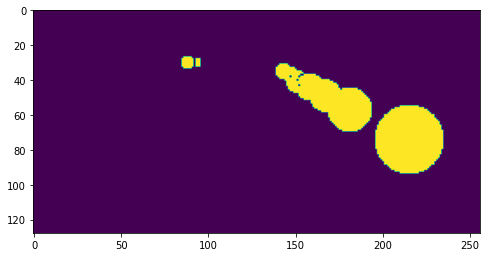

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:20<00:06,  1.15s/it]

theta_x: -0.0910
theta_y: -0.0710
theta_z: 0.0573
phi: 0.0007
gamma: -0.0130
rho: -0.0048


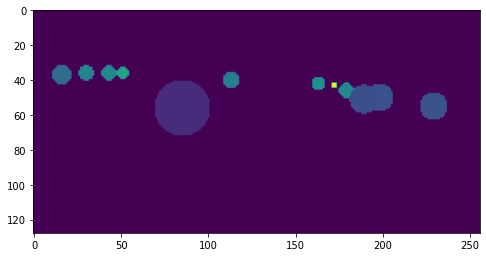

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(104.2316, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(104.3125, device='cuda:0')


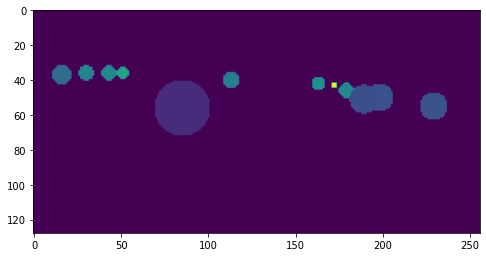

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


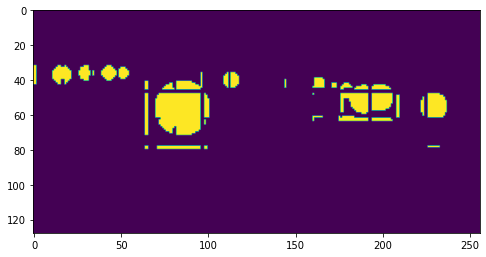

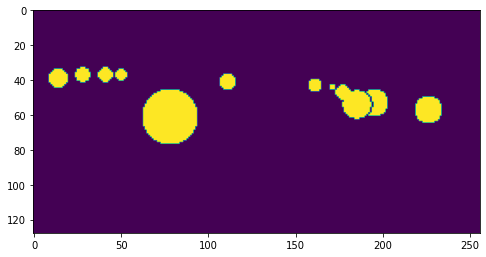

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:22<00:05,  1.16s/it]

theta_x: -0.0923
theta_y: -0.0696
theta_z: 0.0574
phi: 0.0009
gamma: -0.0132
rho: -0.0052


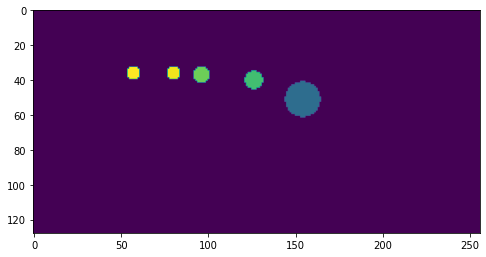

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(57.2701, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(57.4375, device='cuda:0')


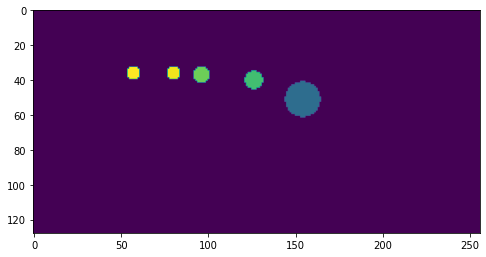

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


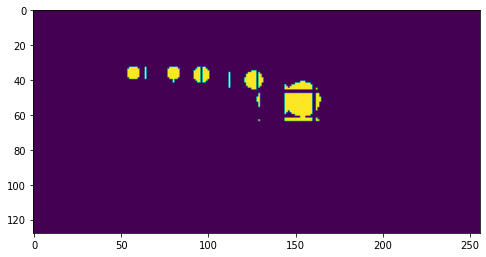

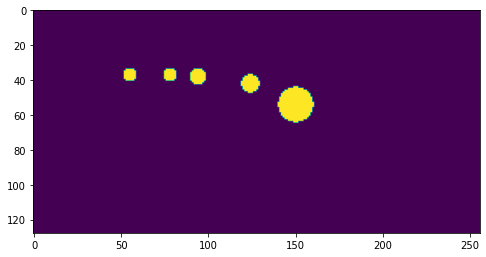

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:23<00:04,  1.15s/it]

theta_x: -0.0898
theta_y: -0.0719
theta_z: 0.0580
phi: 0.0006
gamma: -0.0129
rho: -0.0047


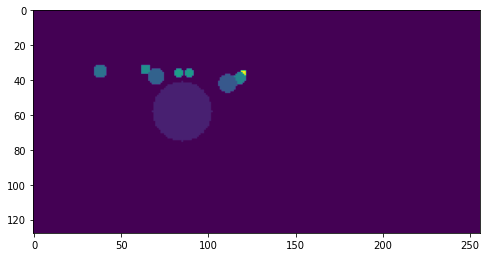

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(141.7249, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(142., device='cuda:0')


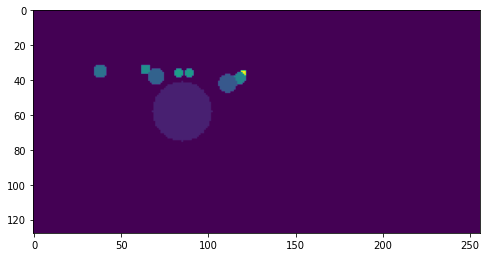

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


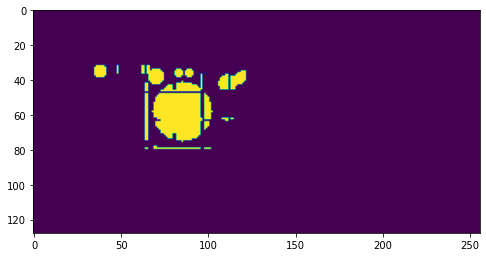

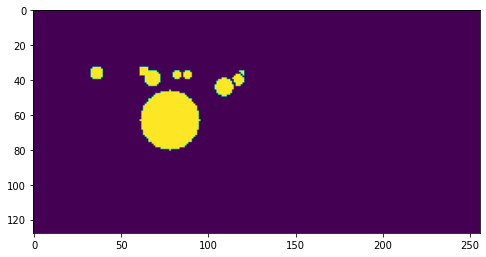

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:24<00:03,  1.16s/it]

theta_x: -0.0888
theta_y: -0.0735
theta_z: 0.0583
phi: 0.0002
gamma: -0.0128
rho: -0.0047


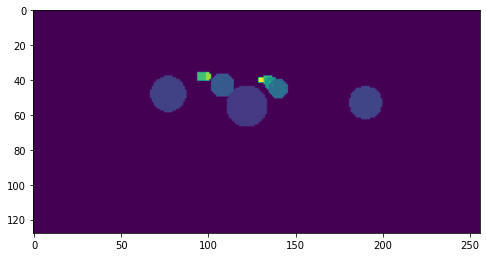

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(105.1861, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(105.3750, device='cuda:0')


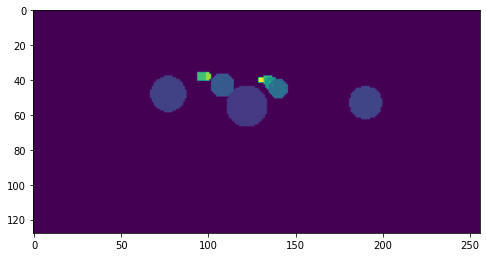

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


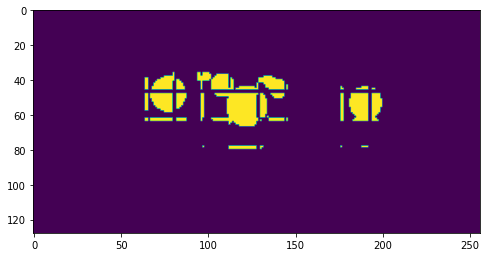

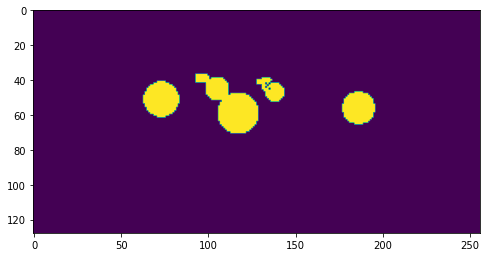

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:25<00:02,  1.15s/it]

theta_x: -0.0886
theta_y: -0.0733
theta_z: 0.0589
phi: 0.0002
gamma: -0.0130
rho: -0.0045


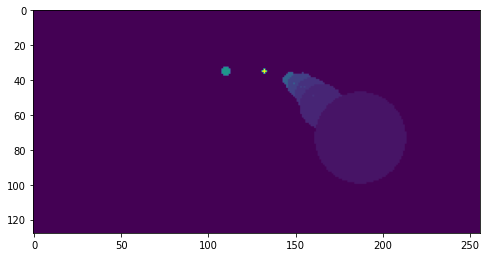

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(155.6172, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(155.8750, device='cuda:0')


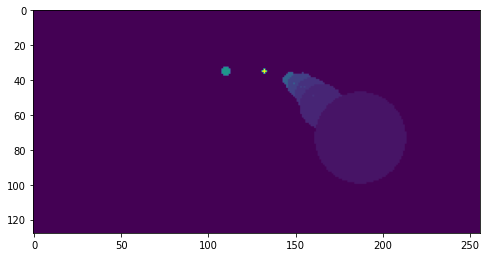

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


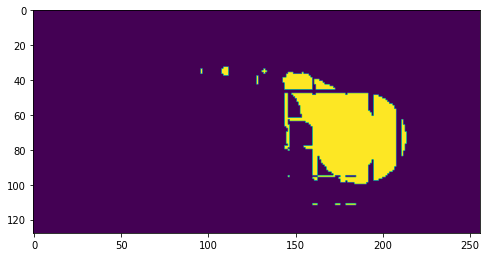

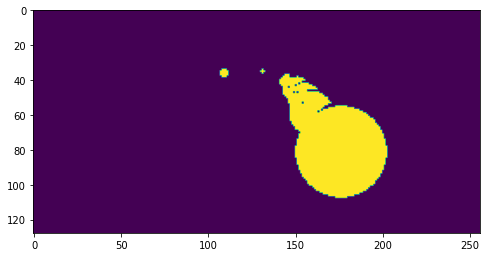

 96%|██████████████████████████████████████████████████████████████████████████████▌   | 23/24 [00:26<00:01,  1.16s/it]

theta_x: -0.0883
theta_y: -0.0739
theta_z: 0.0595
phi: -0.0001
gamma: -0.0131
rho: -0.0045


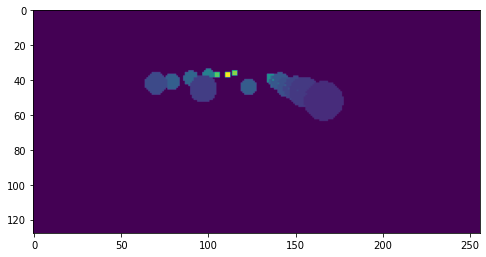

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(143.4163, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(143.7500, device='cuda:0')


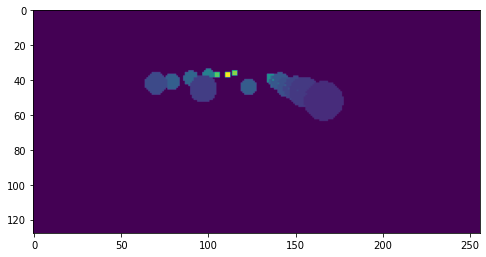

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


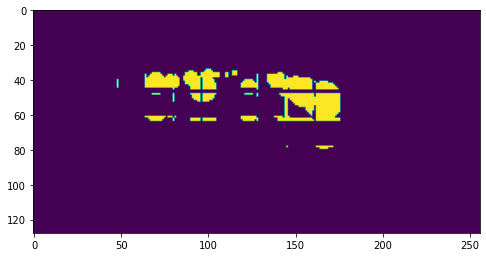

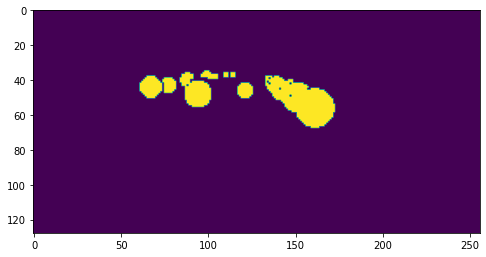

  0%|                                                                                           | 0/24 [00:00<?, ?it/s]

theta_x: -0.0892
theta_y: -0.0712
theta_z: 0.0596
phi: 0.0007
gamma: -0.0134
rho: -0.0045
Train Epoch: (4, 6) 	LR: 0.001000	Loss: 1.801630


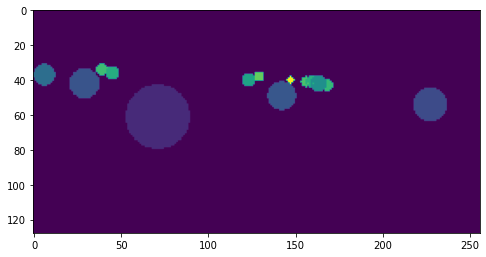

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(93.1924, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(93.3125, device='cuda:0')


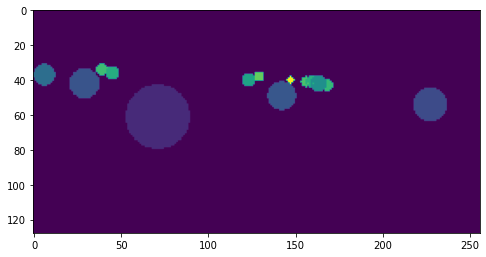

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


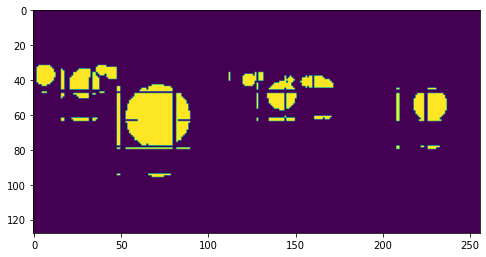

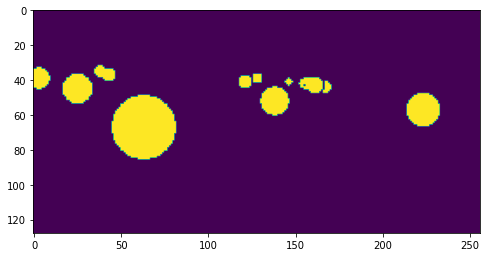

  4%|███▍                                                                               | 1/24 [00:01<00:27,  1.21s/it]

theta_x: -0.0892
theta_y: -0.0715
theta_z: 0.0600
phi: 0.0009
gamma: -0.0133
rho: -0.0046


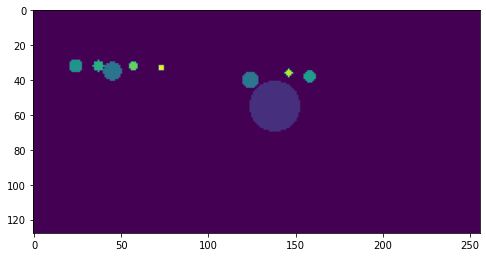

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(105.6248, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(105.9375, device='cuda:0')


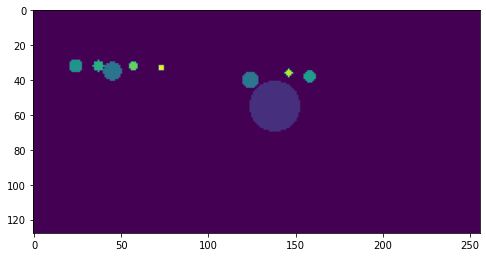

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


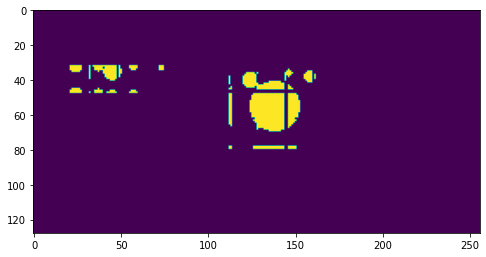

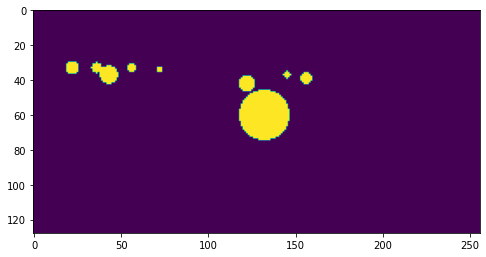

  8%|██████▉                                                                            | 2/24 [00:02<00:26,  1.20s/it]

theta_x: -0.0892
theta_y: -0.0702
theta_z: 0.0602
phi: 0.0006
gamma: -0.0135
rho: -0.0046


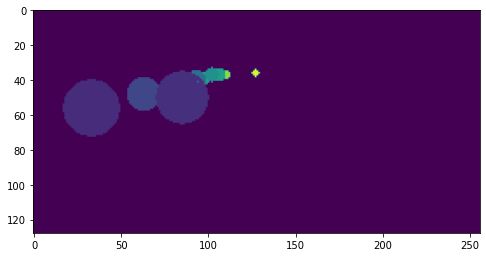

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(100.7104, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(100.8750, device='cuda:0')


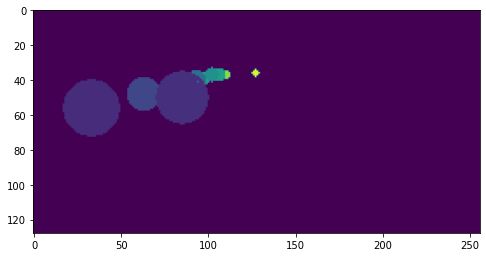

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


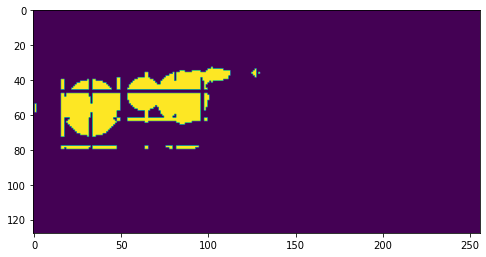

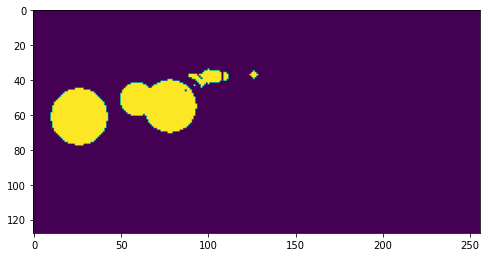

 12%|██████████▍                                                                        | 3/24 [00:03<00:24,  1.18s/it]

theta_x: -0.0885
theta_y: -0.0703
theta_z: 0.0605
phi: 0.0007
gamma: -0.0134
rho: -0.0043


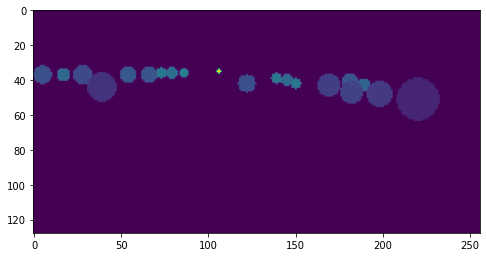

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(167.3569, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(167.7500, device='cuda:0')


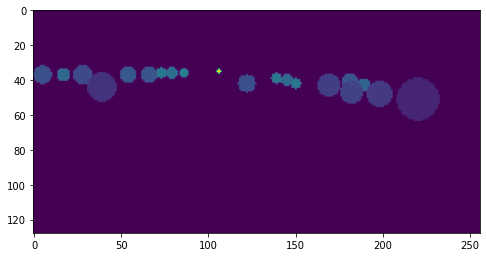

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


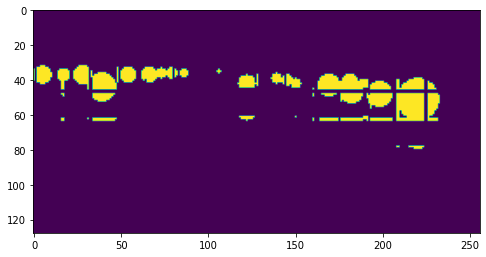

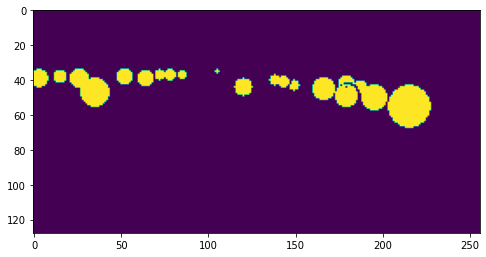

 17%|█████████████▊                                                                     | 4/24 [00:04<00:23,  1.18s/it]

theta_x: -0.0883
theta_y: -0.0717
theta_z: 0.0613
phi: 0.0003
gamma: -0.0133
rho: -0.0042


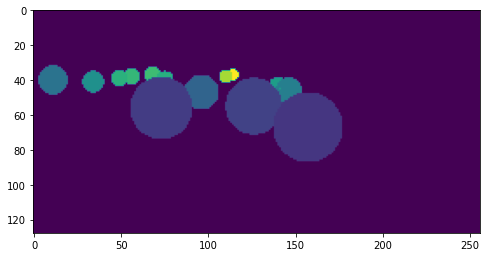

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(65.5895, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(65.6875, device='cuda:0')


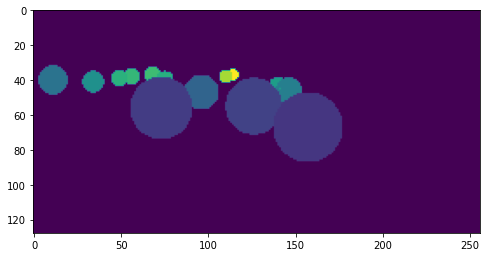

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


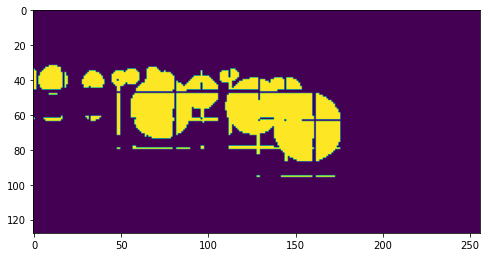

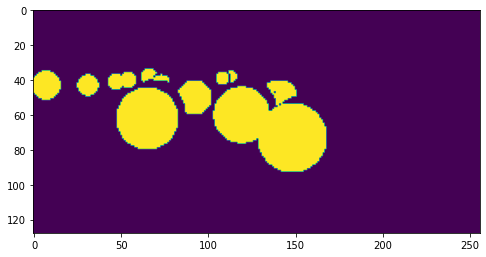

 21%|█████████████████▎                                                                 | 5/24 [00:05<00:22,  1.17s/it]

theta_x: -0.0863
theta_y: -0.0736
theta_z: 0.0618
phi: -0.0003
gamma: -0.0131
rho: -0.0039


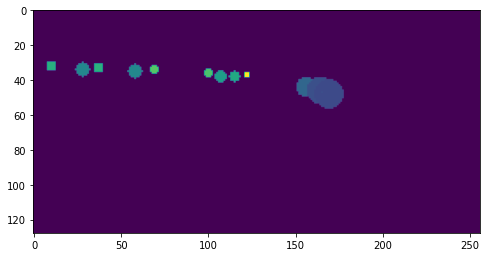

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(110.9904, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(111.1875, device='cuda:0')


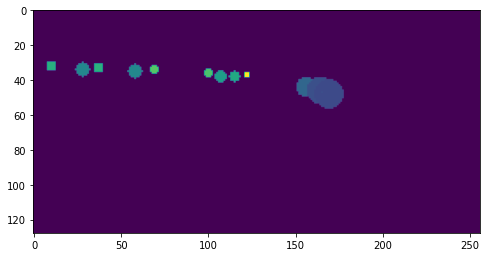

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


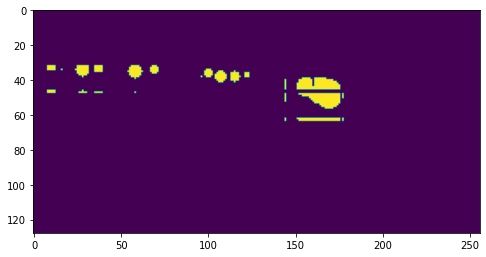

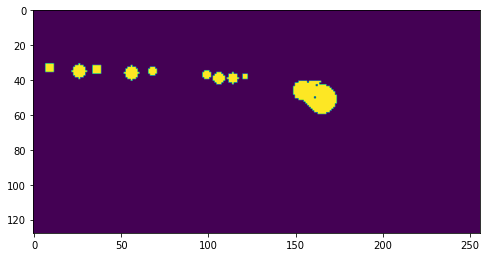

 25%|████████████████████▊                                                              | 6/24 [00:06<00:20,  1.16s/it]

theta_x: -0.0884
theta_y: -0.0747
theta_z: 0.0616
phi: 0.0001
gamma: -0.0128
rho: -0.0042


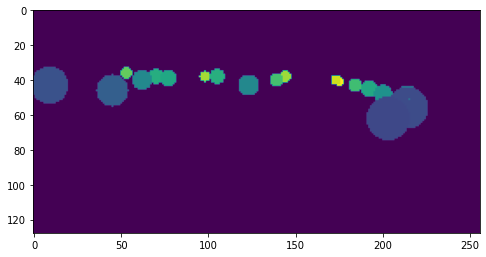

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(76.2237, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(76.2500, device='cuda:0')


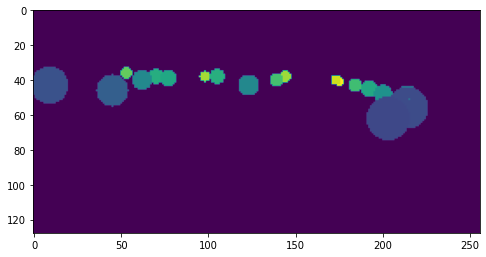

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


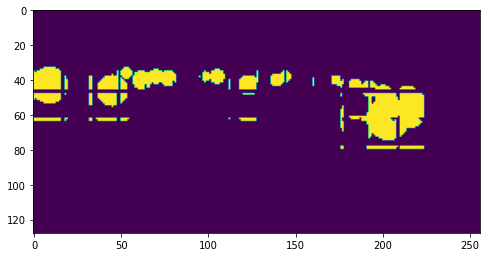

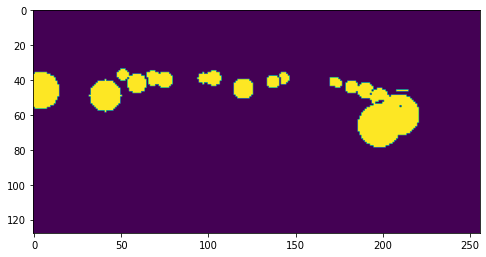

 29%|████████████████████████▏                                                          | 7/24 [00:08<00:19,  1.14s/it]

theta_x: -0.0898
theta_y: -0.0739
theta_z: 0.0618
phi: 0.0010
gamma: -0.0130
rho: -0.0047


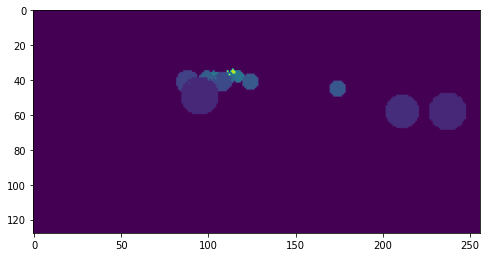

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(165.0019, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(165.3750, device='cuda:0')


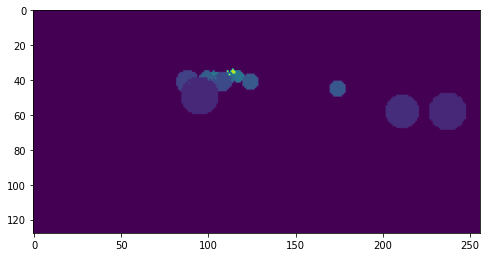

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


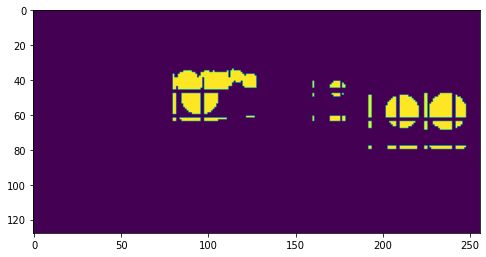

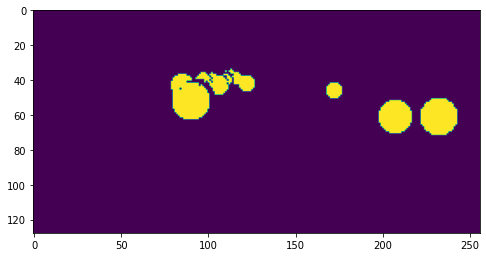

 33%|███████████████████████████▋                                                       | 8/24 [00:09<00:18,  1.16s/it]

theta_x: -0.0881
theta_y: -0.0741
theta_z: 0.0622
phi: 0.0001
gamma: -0.0131
rho: -0.0043


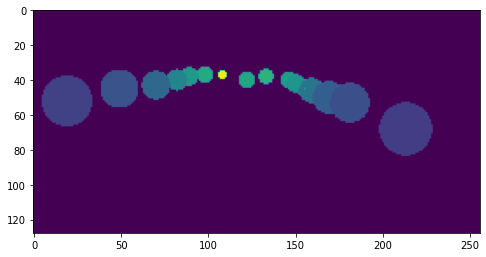

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(74.7954, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(74.9375, device='cuda:0')


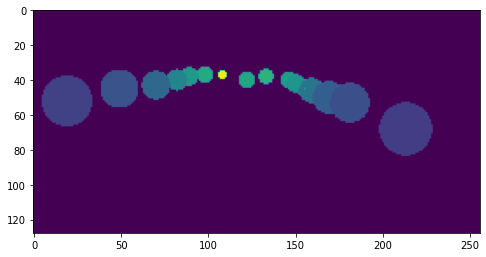

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


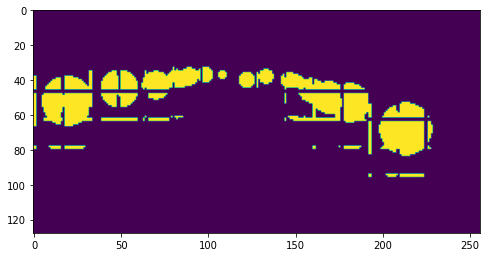

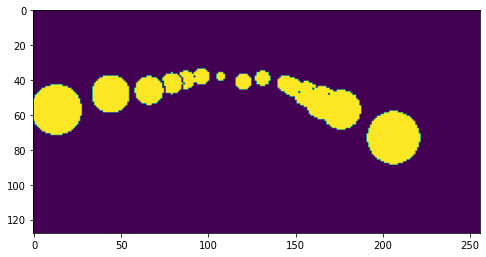

 38%|███████████████████████████████▏                                                   | 9/24 [00:10<00:17,  1.18s/it]

theta_x: -0.0874
theta_y: -0.0723
theta_z: 0.0622
phi: 0.0005
gamma: -0.0134
rho: -0.0043


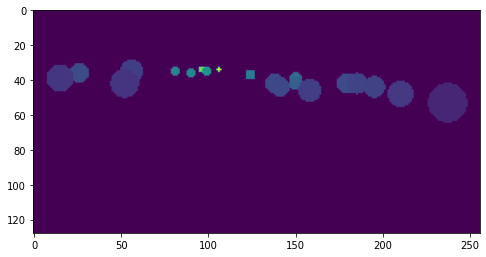

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(169.2373, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(169.6250, device='cuda:0')


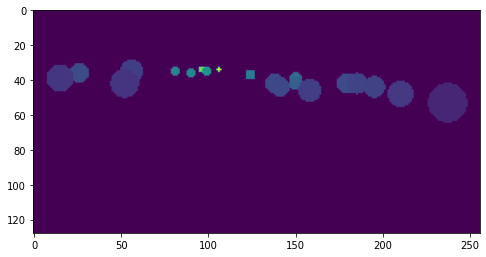

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


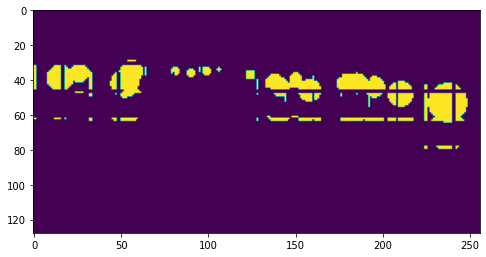

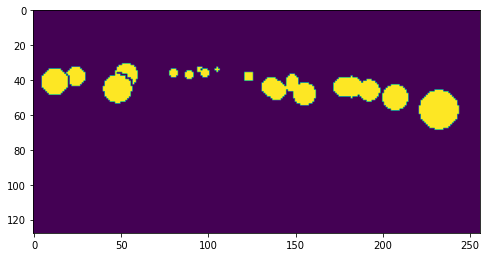

 42%|██████████████████████████████████▏                                               | 10/24 [00:11<00:16,  1.19s/it]

theta_x: -0.0872
theta_y: -0.0731
theta_z: 0.0627
phi: 0.0004
gamma: -0.0132
rho: -0.0043


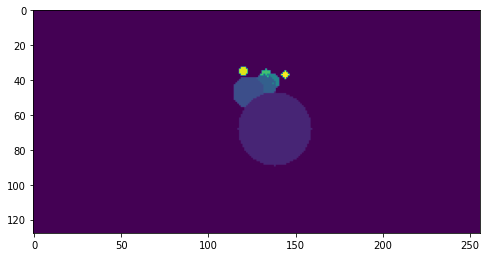

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(96.6900, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(96.8125, device='cuda:0')


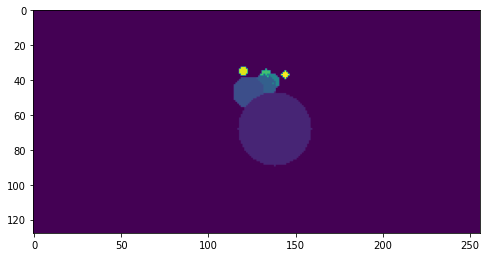

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


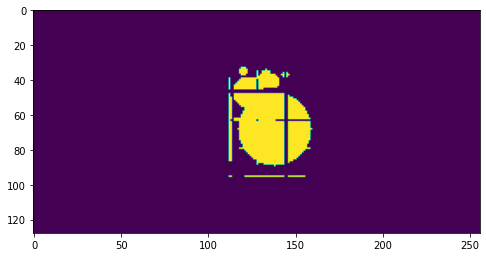

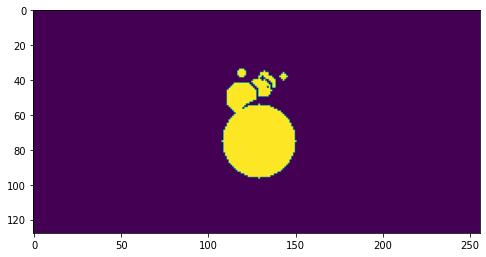

 46%|█████████████████████████████████████▌                                            | 11/24 [00:12<00:15,  1.21s/it]

theta_x: -0.0896
theta_y: -0.0713
theta_z: 0.0624
phi: 0.0004
gamma: -0.0138
rho: -0.0046


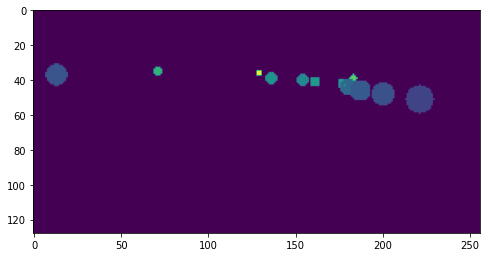

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(125.5132, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(125.7500, device='cuda:0')


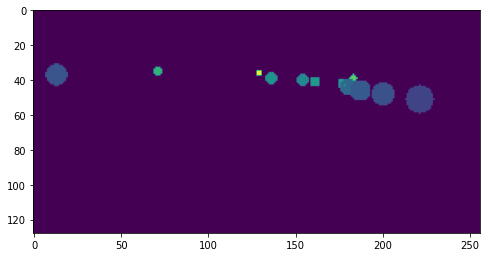

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


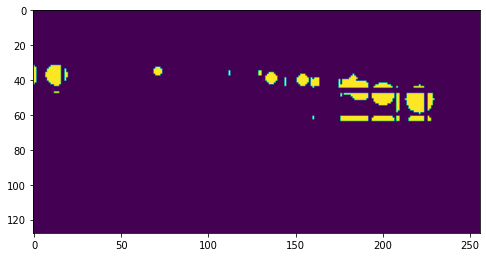

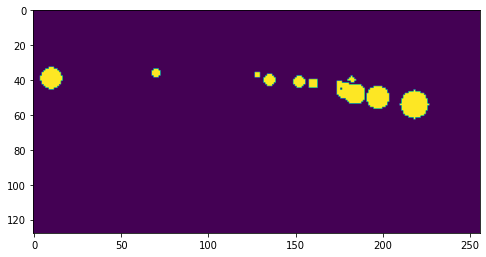

 50%|█████████████████████████████████████████                                         | 12/24 [00:14<00:14,  1.25s/it]

theta_x: -0.0948
theta_y: -0.0664
theta_z: 0.0617
phi: 0.0013
gamma: -0.0144
rho: -0.0052


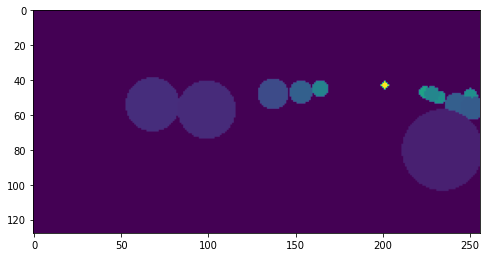

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(103.4840, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(103.5000, device='cuda:0')


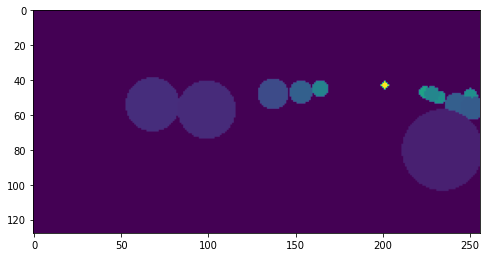

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


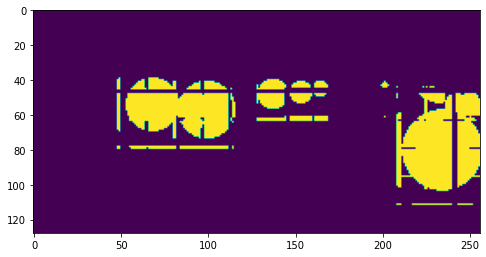

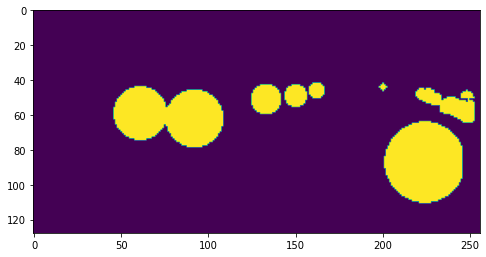

 54%|████████████████████████████████████████████▍                                     | 13/24 [00:15<00:13,  1.22s/it]

theta_x: -0.0923
theta_y: -0.0670
theta_z: 0.0622
phi: 0.0011
gamma: -0.0140
rho: -0.0048


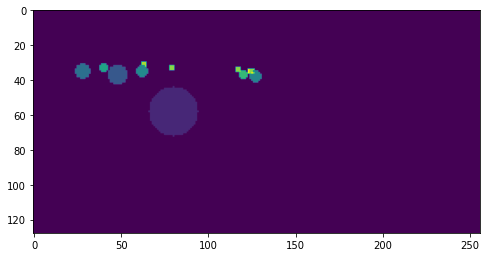

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(130.8736, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(131.1250, device='cuda:0')


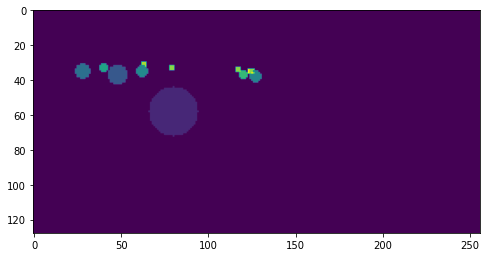

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


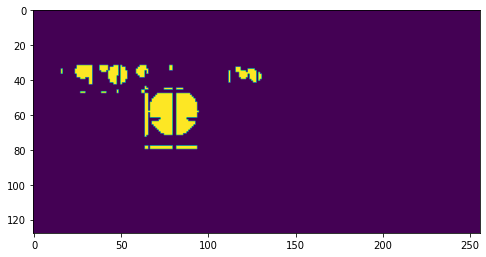

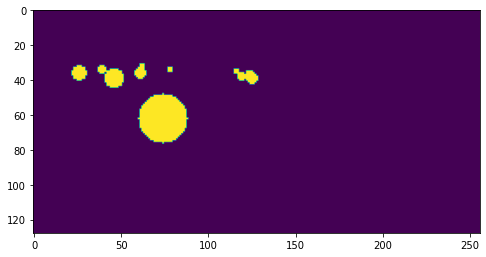

 58%|███████████████████████████████████████████████▊                                  | 14/24 [00:16<00:11,  1.20s/it]

theta_x: -0.0924
theta_y: -0.0683
theta_z: 0.0627
phi: 0.0014
gamma: -0.0137
rho: -0.0048


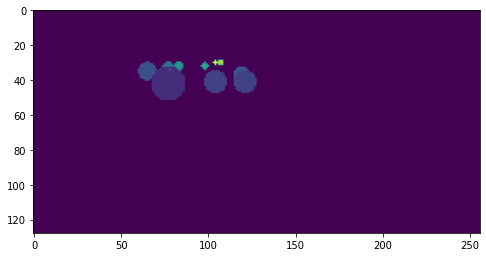

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(160.6424, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(161., device='cuda:0')


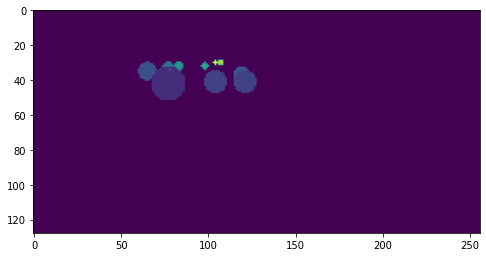

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


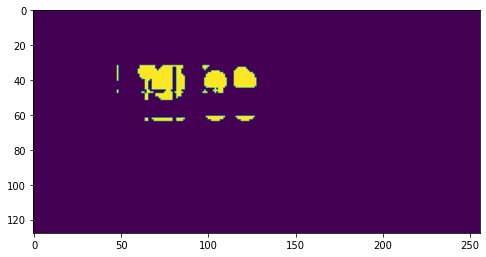

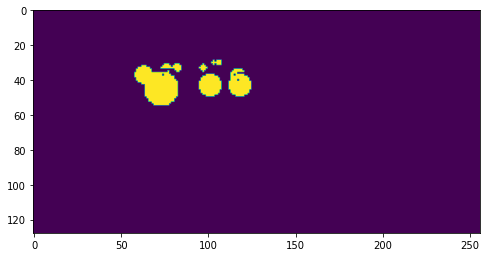

 62%|███████████████████████████████████████████████████▎                              | 15/24 [00:17<00:10,  1.17s/it]

theta_x: -0.0929
theta_y: -0.0686
theta_z: 0.0630
phi: 0.0013
gamma: -0.0137
rho: -0.0049


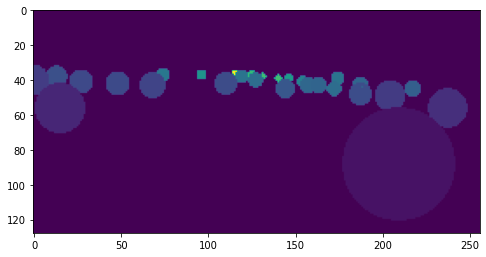

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(136.5803, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(136.8750, device='cuda:0')


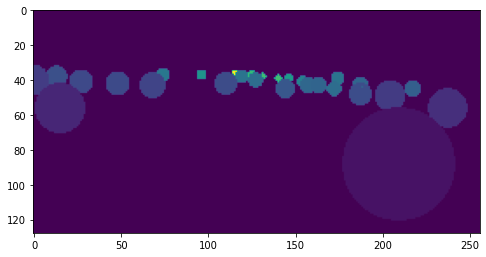

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


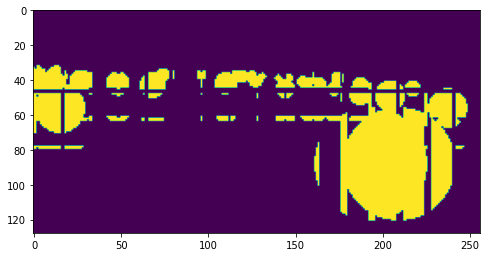

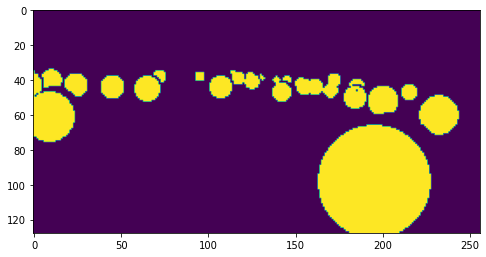

 67%|██████████████████████████████████████████████████████▋                           | 16/24 [00:18<00:09,  1.18s/it]

theta_x: -0.0912
theta_y: -0.0690
theta_z: 0.0638
phi: 0.0012
gamma: -0.0136
rho: -0.0046


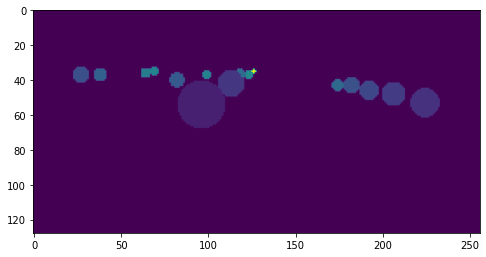

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(172.1681, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(172.5000, device='cuda:0')


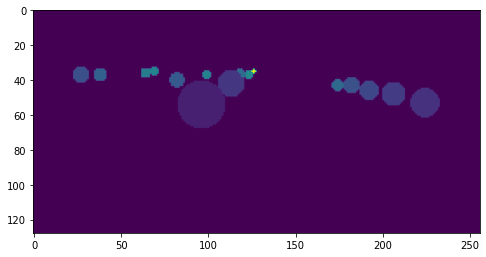

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


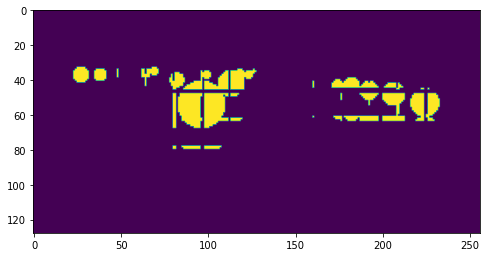

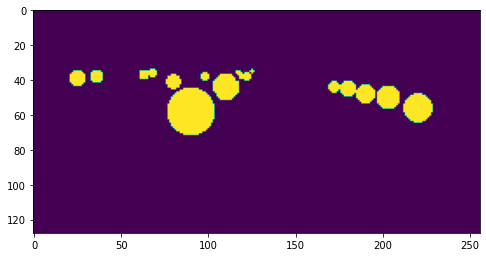

 71%|██████████████████████████████████████████████████████████                        | 17/24 [00:20<00:08,  1.19s/it]

theta_x: -0.0890
theta_y: -0.0698
theta_z: 0.0639
phi: 0.0008
gamma: -0.0137
rho: -0.0042


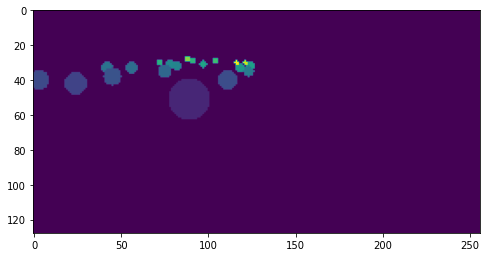

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(162.1993, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(162.5000, device='cuda:0')


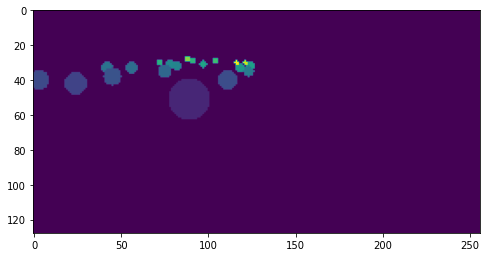

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


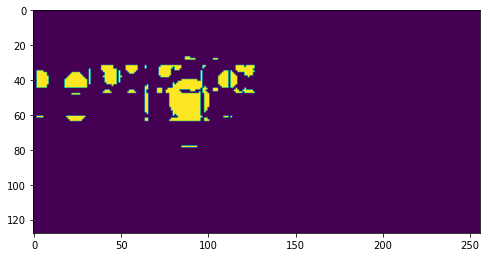

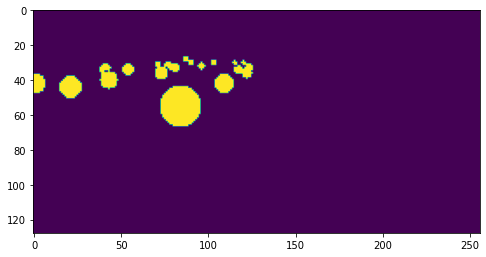

 75%|█████████████████████████████████████████████████████████████▌                    | 18/24 [00:21<00:07,  1.18s/it]

theta_x: -0.0902
theta_y: -0.0693
theta_z: 0.0639
phi: 0.0011
gamma: -0.0138
rho: -0.0044


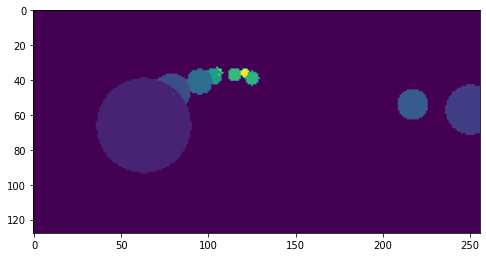

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(79.8759, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(80., device='cuda:0')


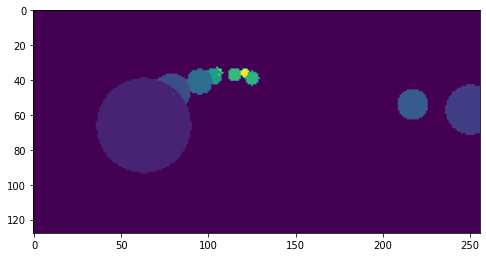

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


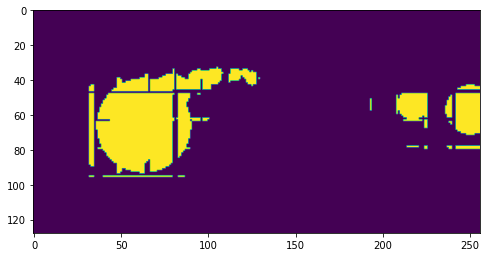

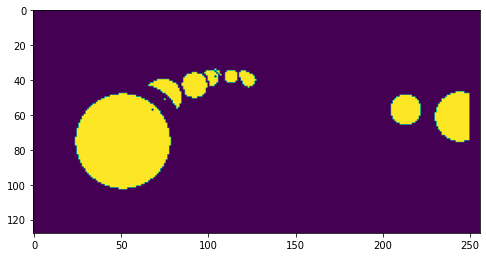

 79%|████████████████████████████████████████████████████████████████▉                 | 19/24 [00:22<00:05,  1.18s/it]

theta_x: -0.0900
theta_y: -0.0709
theta_z: 0.0640
phi: 0.0010
gamma: -0.0134
rho: -0.0043


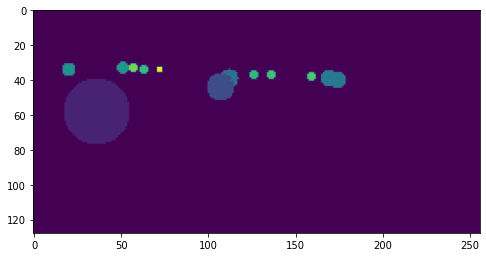

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(110.8760, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(111.1875, device='cuda:0')


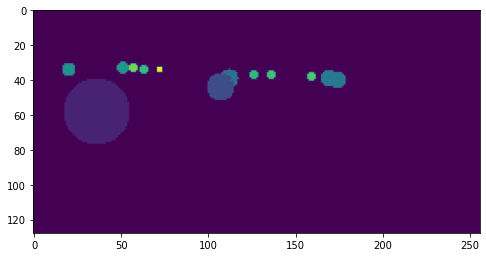

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


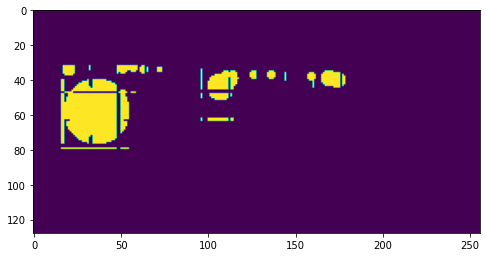

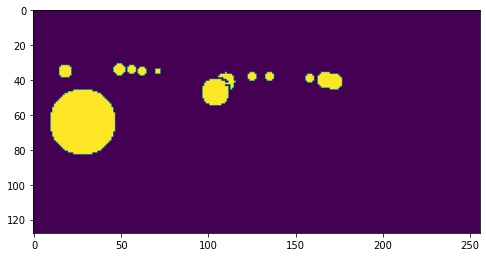

 83%|████████████████████████████████████████████████████████████████████▎             | 20/24 [00:23<00:04,  1.18s/it]

theta_x: -0.0891
theta_y: -0.0726
theta_z: 0.0647
phi: 0.0009
gamma: -0.0132
rho: -0.0041


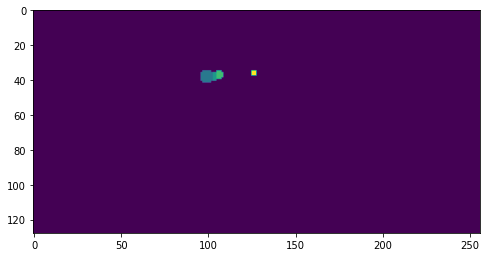

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(129.1334, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(129.3750, device='cuda:0')


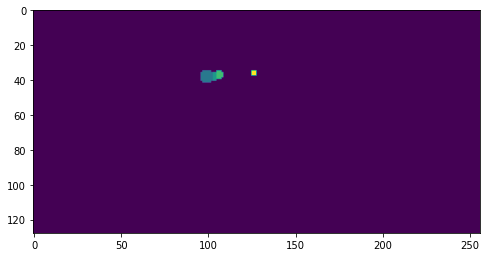

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


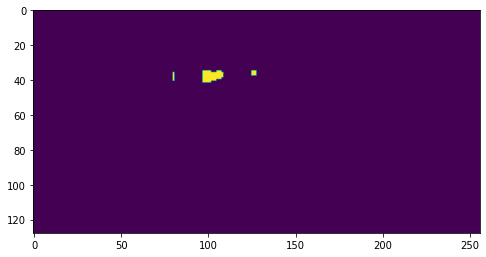

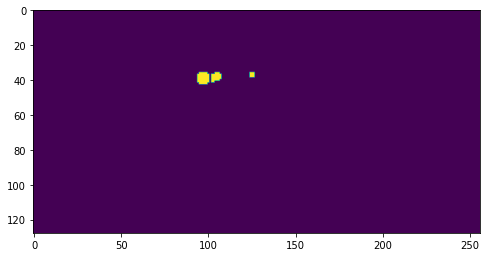

 88%|███████████████████████████████████████████████████████████████████████▊          | 21/24 [00:25<00:04,  1.36s/it]

theta_x: -0.0919
theta_y: -0.0699
theta_z: 0.0646
phi: 0.0012
gamma: -0.0139
rho: -0.0043


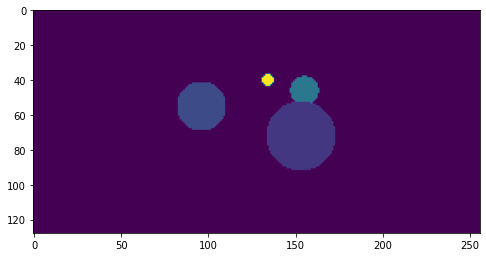

x_t
tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(64.4209, device='cuda:0', grad_fn=<MaxBackward1>)
input_2Dr_batch
torch.Size([16, 3, 128, 256])
tensor(0., device='cuda:0')
tensor(64.5000, device='cuda:0')


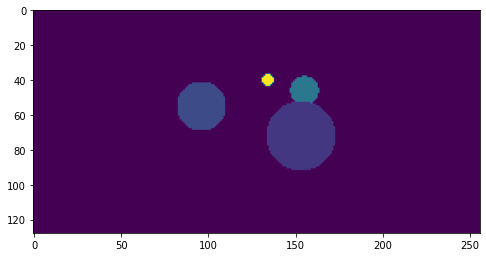

tensor(0., device='cuda:0', grad_fn=<MinBackward1>)
tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


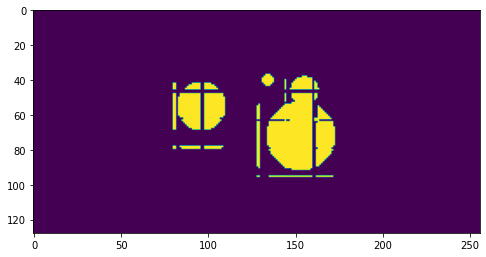

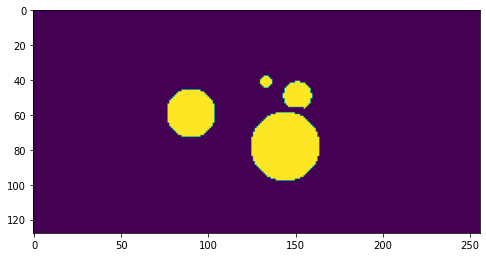

 92%|███████████████████████████████████████████████████████████████████████████▏      | 22/24 [00:26<00:02,  1.34s/it]

theta_x: -0.0932
theta_y: -0.0710
theta_z: 0.0651
phi: 0.0014
gamma: -0.0136
rho: -0.0045


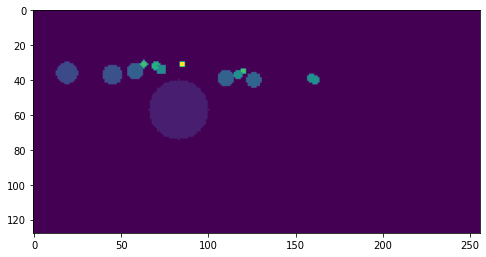

In [ ]:
import time
%time


n_epochs_list = [16]
lr_list = [1e-3]
batch_size = 16
n = 4
optimizer = None
model = None


train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=train_sampler)
dev_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=valid_sampler)

fileName = None
dev_history = pd.DataFrame(index=pd.MultiIndex.from_tuples((), names=['epoch', 'lr']), columns=['theta_x', 'theta_y', 'theta_z', 'dev_loss'])

torch.cuda.empty_cache()
gc.collect()

for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        n_epochs = n_epochs_list[i_epoch]
        lr = lr_list[i_lr]
        train_history = pd.DataFrame(index=pd.MultiIndex.from_tuples((), names=['zoom', 'epoch', 'batch_id']), columns=['theta_x', 'theta_y', 'theta_z', 'loss'])

        model = create_model(CAMERA, n)
        if fileName is not None:
            state_dict = torch.load(fileName, map_location='cpu')
            model.load_state_dict(state_dict, strict=False)
            del state_dict
            print("Loaded!!")
        model = model.to(device)

        torch.cuda.empty_cache()

        gc.collect()
        optimizer = optim.SGD(list(model.parameters()), lr=lr)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=n_epochs, gamma=1.1)

        torch.cuda.empty_cache()
        gc.collect()

        for i in range(n+1):
            for epoch in range(n_epochs):
                zoom = n-i
                torch.cuda.empty_cache()
                gc.collect()

                loader = train_loader
                train_loop_fn(loader, zoom, epoch, train_history)
                
                scheduler.step()
                k_const+=2.5/n/n_epochs

        loader = dev_loader
        start = time.time()*1000.0
        evaluate_model(loader, (n_epochs, lr), dev_history)
        t_interval = time.time()*1000.0 - start
        print("Speed: {} ms/sample".format(t_interval/(len(dev_loader)*batch_size)))

        gc.collect()
        optimizer = None
        gc.collect()

        train_history.to_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        torch.save(model.state_dict(), "./model_{}_{}.pth".format(i_epoch, i_lr))
    
dev_history.to_csv('dev_history.csv')

# Result Visualization

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        train_history[['loss']].plot();
        train_history[['theta_x', 'theta_y', 'theta_z']].plot();

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        train_history[['loss']].plot();
        train_history[['phi', 'gamma', 'rho']].plot();

In [ ]:
dev_history

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        ax = train_history[['theta_x', 'theta_y', 'theta_z']].plot()
        fig = ax.get_figure()
        fig.savefig('./position.png')

In [ ]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        ax = train_history[['phi', 'gamma', 'rho']].plot()
        fig = ax.get_figure()
        fig.savefig('./orientation.png')